In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([32, 42, -5, 5])
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.plot(36.33, -0.92, 'r*', markersize=15,
        transform=ccrs.PlateCarree(), label='Olkaria')
ax.legend()
ax.set_title('Olkaria Geothermal Field — Study Domain')
plt.show()


In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# ── Study polygon corners (decimal degrees) ──────────────────────────────────
polygon_lons = [36.241878, 36.421436, 36.421306, 36.241736, 36.241878]
polygon_lats = [-0.842803, -0.842803, -1.023692, -1.023542, -0.842803]

corners = {
    "C1 (NW)": (-0.842803, 36.241878),
    "C2 (NE)": (-0.842803, 36.421436),
    "C3 (SW)": (-1.023542, 36.241736),
    "C4 (SE)": (-1.023692, 36.421306),
}

CENTER_LAT = -0.933210
CENTER_LON =  36.331589

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Zoom to study area with buffer
ax.set_extent([36.0, 36.7, -1.25, -0.65])

# Background features
ax.add_feature(cfeature.LAND,      facecolor="#f0f0ec")
ax.add_feature(cfeature.LAKES,     facecolor="#ddeeff")
ax.add_feature(cfeature.RIVERS,    linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle="--")
ax.coastlines(resolution="10m",    linewidth=0.8)
ax.gridlines(draw_labels=True,     linewidth=0.4, alpha=0.6)

# Draw study polygon outline
ax.plot(polygon_lons, polygon_lats,
        color="red", linewidth=2,
        transform=ccrs.PlateCarree(),
        label="Study polygon")

# Shade polygon interior
ax.fill(polygon_lons, polygon_lats,
        color="red", alpha=0.15,
        transform=ccrs.PlateCarree())

# Mark and label each corner
for label, (lat, lon) in corners.items():
    ax.plot(lon, lat, "rs", markersize=8,
            transform=ccrs.PlateCarree())
    ax.text(lon + 0.004, lat + 0.004, label,
            fontsize=8, transform=ccrs.PlateCarree(),
            color="darkred", fontweight="bold")

# Mark center point
ax.plot(CENTER_LON, CENTER_LAT, "r*", markersize=16,
        transform=ccrs.PlateCarree(),
        label=f"Center  ({CENTER_LAT}, {CENTER_LON})")

ax.set_title("Olkaria Geothermal Field — Study Polygon\nKenya Rift Valley",
             fontsize=13, pad=12)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 50)
print("  STUDY POLYGON SUMMARY")
print("=" * 50)
print(f"  Center     : {CENTER_LAT}°N,  {CENTER_LON}°E")
print(f"  North edge : -0.842803°")
print(f"  South edge : -1.023692°")
print(f"  West edge  :  36.241736°")
print(f"  East edge  :  36.421436°")
print(f"  Width (E-W): ~19.8 km")
print(f"  Height (N-S): ~20.1 km")
print("=" * 50)

In [ ]:
config_content = '''"""
config.py
=========
Central configuration for the Olkaria GEOS-Chem dissertation project.
ALL other scripts import from here. Change a value once, applies everywhere.

Project: Numerical Simulation of CO2 and CH4 Emissions from Olkaria
         Geothermal Field using GEOS-Chem and Satellite Comparison
Author : [Your Name]
"""

# =============================================================================
#  STUDY SITE
# =============================================================================
TARGET_LAT = -0.933210     # Center of study polygon
TARGET_LON =  36.331589    # Center of study polygon
SITE_NAME  = "Olkaria_Kenya"
SITE_LABEL = "Olkaria Geothermal Field"

# Exact polygon corners (decimal degrees, converted from DMS)
POLYGON = {
    "C1": {"lat": -0.842803, "lon": 36.241878},  # NW corner
    "C2": {"lat": -0.842803, "lon": 36.421436},  # NE corner
    "C3": {"lat": -1.023542, "lon": 36.241736},  # SW corner
    "C4": {"lat": -1.023692, "lon": 36.421306},  # SE corner
}

# Polygon bounding box
POLY_LAT_MIN = -1.023692
POLY_LAT_MAX = -0.842803
POLY_LON_MIN =  36.241736
POLY_LON_MAX =  36.421436

# =============================================================================
#  STUDY PERIOD
# =============================================================================
START_DATE = "2019-05-02"
END_DATE   = "2021-07-02"

START_DT = "2019-05-02T00:00:00Z"
END_DT   = "2021-07-02T23:59:59Z"

# =============================================================================
#  REGIONAL DOMAIN  (±5 degrees around site for GEOS-Chem and satellite data)
# =============================================================================
DOMAIN = {
    "lat_min": -5.0,
    "lat_max":  5.0,
    "lon_min": 32.0,
    "lon_max": 42.0,
}

# Bounding box string for NASA CMR API queries
BBOX = (
    f"{DOMAIN[\'lon_min\']},"
    f"{DOMAIN[\'lat_min\']},"
    f"{DOMAIN[\'lon_max\']},"
    f"{DOMAIN[\'lat_max\']}"
)

# WKT polygon for Copernicus CDSE API
BBOX_WKT = (
    f"POLYGON(("
    f"{DOMAIN[\'lon_min\']} {DOMAIN[\'lat_min\']},"
    f"{DOMAIN[\'lon_max\']} {DOMAIN[\'lat_min\']},"
    f"{DOMAIN[\'lon_max\']} {DOMAIN[\'lat_max\']},"
    f"{DOMAIN[\'lon_min\']} {DOMAIN[\'lat_max\']},"
    f"{DOMAIN[\'lon_min\']} {DOMAIN[\'lat_min\']}"
    f"))"
)

# =============================================================================
#  LOCAL DATA DIRECTORIES
# =============================================================================
DATA_ROOT    = "./data"
DIR_MERRA2   = f"{DATA_ROOT}/MERRA2"
DIR_OCO2     = f"{DATA_ROOT}/OCO2"
DIR_TROPOMI  = f"{DATA_ROOT}/TROPOMI"
DIR_GROUND   = f"{DATA_ROOT}/ground_measurements"
DIR_OUTPUTS  = f"{DATA_ROOT}/outputs"
DIR_FIGURES  = f"{DATA_ROOT}/figures"

# =============================================================================
#  CREDENTIALS
# =============================================================================

# NASA Earthdata — register at: https://urs.earthdata.nasa.gov/users/new
# After registering, approve GES DISC at:
# https://urs.earthdata.nasa.gov/approve_app?client_id=ijpRZvb9qeKCK5ctsn75Tg
EARTHDATA_USER = "YOUR_EARTHDATA_USERNAME"
EARTHDATA_PASS = "YOUR_EARTHDATA_PASSWORD"

# Copernicus Data Space — register at: https://dataspace.copernicus.eu
# NOTE: Old s5phub.copernicus.eu is SHUT DOWN — use the link above
COPERNICUS_USER = "YOUR_COPERNICUS_USERNAME"
COPERNICUS_PASS = "YOUR_COPERNICUS_PASSWORD"

# =============================================================================
#  GEOS-CHEM SETTINGS
# =============================================================================
GC_MET        = "MERRA2"
GC_RESOLUTION = "4x5"

# Olkaria emission estimates (replace with your ground measurement values)
EMISSION_CO2_KG_S = 3.274    # ~283 tCO2/day
EMISSION_CH4_KG_S = 0.012    # Estimated thermogenic CH4

# =============================================================================
#  PLOTTING DEFAULTS
# =============================================================================
FIG_DPI      = 150
FIG_FORMAT   = "png"
COLORMAP_CO2 = "RdYlBu_r"
COLORMAP_CH4 = "YlOrRd"
'''

# Write to file
with open("config.py", "w") as f:
    f.write(config_content)

print("config.py written successfully!")
print(f"Saved to: {__import__('os').path.abspath('config.py')}")

In [ ]:
# HERE, WE Write credentials directly into config.py WHICH WAS SAVED INITIALLY

new_credentials = {
    "YOUR_EARTHDATA_USERNAME":  "John_KIMKE",
    "YOUR_EARTHDATA_PASSWORD":  "225322532253J_k",
    "YOUR_COPERNICUS_USERNAME": "johnnduati600@gmail.com",
    "YOUR_COPERNICUS_PASSWORD": "D_#rWwXRj4DGA/*",
}

with open("config.py", "r") as f:
    content = f.read()

for placeholder, actual in new_credentials.items():
    content = content.replace(f'"{placeholder}"', f'"{actual}"')

with open("config.py", "w") as f:
    f.write(content)

# Verify it worked
with open("config.py", "r") as f:
    for line in f:
        if "EARTHDATA" in line or "COPERNICUS" in line:
            print("SAVED:", line.strip())

In [ ]:
#WE TEST FOR A SINGLE FILE DOWNLOAD
import requests
import os

USER = "John_KIMKE"
PASS = "225322532253J_k"

# Step 1: Get token
print("Getting token...")
resp = requests.get(
    "https://urs.earthdata.nasa.gov/api/users/tokens",
    auth=(USER, PASS),
    timeout=30,
)
token = resp.json()[0]["access_token"]
print(f"Token OK ✓")

# Step 2: Test one file download
print("\nTesting one file download...")
test_url = (
    "https://data.gesdisc.earthdata.nasa.gov/data/OCO2_DATA/"
    "OCO2_GEOS_L3CO2_DAY.10r/2019/"
    "oco2_GEOS_L3CO2_day_20190501_B10206Ar.nc4"
)

session = requests.Session()
session.headers.update({"Authorization": f"Bearer {token}"})

os.makedirs("./data/OCO2/L3_Daily", exist_ok=True)

resp = session.get(test_url, stream=True, timeout=60, allow_redirects=True)
print(f"Status code: {resp.status_code}")

if resp.status_code == 200:
    fpath = "./data/OCO2/L3_Daily/oco2_GEOS_L3CO2_day_20190501_B10206Ar.nc4"
    with open(fpath, "wb") as f:
        for chunk in resp.iter_content(65536):
            f.write(chunk)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f"\nSUCCESS ✓  File saved: {size_mb:.1f} MB")
    print("GES DISC access is working — ready to download all data!")
#
elif resp.status_code == 403:
    print("\nStill 403 — wait a few more minutes for GES DISC approval to activate.")
    print("Then run this cell again.")

else:
    print(f"\nUnexpected status: {resp.status_code}")
    print(resp.text[:200])

In [ ]:
#TO DOWNLOAD THE DATA FOR ALL DAYS

import requests
import os
import time

USER = "John_KIMKE"
PASS = "225322532253J_k"

# ── Get token ─────────────────────────────────────────────────────────────────
resp = requests.get(
    "https://urs.earthdata.nasa.gov/api/users/tokens",
    auth=(USER, PASS), timeout=30,
)
token = resp.json()[0]["access_token"]
session = requests.Session()
session.headers.update({"Authorization": f"Bearer {token}"})
print("Token ready ✓")

# ── Download directory ────────────────────────────────────────────────────────
dest = "./data/OCO2/L3_Daily"
os.makedirs(dest, exist_ok=True)
print(f"Saving to: {dest}\n")

# ── Search function ───────────────────────────────────────────────────────────
def search_oco2(start, end):
    CMR_URL = "https://cmr.earthdata.nasa.gov/search/granules.json"
    params  = {
        "short_name":   "OCO2_GEOS_L3CO2_DAY",
        "version":      "10r",
        "bounding_box": "32.0,-5.0,42.0,5.0",
        "temporal":     f"{start},{end}",
        "page_size":    500,
    }
    r = requests.get(CMR_URL, params=params,
                     headers={"Authorization": f"Bearer {token}"},
                     timeout=60)
    r.raise_for_status()
    urls = []
    for g in r.json().get("feed", {}).get("entry", []):
        for link in g.get("links", []):
            href = link.get("href", "")
            if href.startswith("https://") and ".nc4" in href:
                urls.append(href)
                break
    return urls

# ── Download function ─────────────────────────────────────────────────────────
def download_file(url):
    fname = url.split("/")[-1]
    fpath = os.path.join(dest, fname)
    if os.path.exists(fpath) and os.path.getsize(fpath) > 0:
        print(f"  [skip] {fname}")
        return True
    try:
        r = session.get(url, stream=True, timeout=120, allow_redirects=True)
        r.raise_for_status()
        with open(fpath, "wb") as f:
            for chunk in r.iter_content(65536):
                f.write(chunk)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  [ok]   {fname}  ({size_mb:.1f} MB)")
        return True
    except Exception as e:
        print(f"  [err]  {fname}: {e}")
        return False

# ── All 26 months ─────────────────────────────────────────────────────────────
months = [
    ("2019-05-01T00:00:00Z", "2019-05-31T23:59:59Z"),
    ("2019-06-01T00:00:00Z", "2019-06-30T23:59:59Z"),
    ("2019-07-01T00:00:00Z", "2019-07-31T23:59:59Z"),
    ("2019-08-01T00:00:00Z", "2019-08-31T23:59:59Z"),
    ("2019-09-01T00:00:00Z", "2019-09-30T23:59:59Z"),
    ("2019-10-01T00:00:00Z", "2019-10-31T23:59:59Z"),
    ("2019-11-01T00:00:00Z", "2019-11-30T23:59:59Z"),
    ("2019-12-01T00:00:00Z", "2019-12-31T23:59:59Z"),
    ("2020-01-01T00:00:00Z", "2020-01-31T23:59:59Z"),
    ("2020-02-01T00:00:00Z", "2020-02-29T23:59:59Z"),
    ("2020-03-01T00:00:00Z", "2020-03-31T23:59:59Z"),
    ("2020-04-01T00:00:00Z", "2020-04-30T23:59:59Z"),
    ("2020-05-01T00:00:00Z", "2020-05-31T23:59:59Z"),
    ("2020-06-01T00:00:00Z", "2020-06-30T23:59:59Z"),
    ("2020-07-01T00:00:00Z", "2020-07-31T23:59:59Z"),
    ("2020-08-01T00:00:00Z", "2020-08-31T23:59:59Z"),
    ("2020-09-01T00:00:00Z", "2020-09-30T23:59:59Z"),
    ("2020-10-01T00:00:00Z", "2020-10-31T23:59:59Z"),
    ("2020-11-01T00:00:00Z", "2020-11-30T23:59:59Z"),
    ("2020-12-01T00:00:00Z", "2020-12-31T23:59:59Z"),
    ("2021-01-01T00:00:00Z", "2021-01-31T23:59:59Z"),
    ("2021-02-01T00:00:00Z", "2021-02-28T23:59:59Z"),
    ("2021-03-01T00:00:00Z", "2021-03-31T23:59:59Z"),
    ("2021-04-01T00:00:00Z", "2021-04-30T23:59:59Z"),
    ("2021-05-01T00:00:00Z", "2021-05-31T23:59:59Z"),
    ("2021-06-01T00:00:00Z", "2021-06-30T23:59:59Z"),
    ("2021-07-01T00:00:00Z", "2021-07-02T23:59:59Z"),
]

total_ok = total_fail = 0

for start, end in months:
    label = start[:7]
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")

    urls = search_oco2(start, end)
    print(f"  Files found: {len(urls)}")

    ok = fail = 0
    for i, url in enumerate(urls, 1):
        print(f"  [{i:>2}/{len(urls)}] ", end="")
        if download_file(url):
            ok += 1
        else:
            fail += 1
        time.sleep(0.2)

    total_ok   += ok
    total_fail += fail
    print(f"  Done — OK: {ok}  Failed: {fail}")

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  ALL DOWNLOADS COMPLETE")
print(f"  Total OK     : {total_ok}")
print(f"  Total failed : {total_fail}")
print(f"  Saved to     : {dest}")
print(f"{'='*50}")

In [ ]:
#TO TEST THE FAILED FILES

import requests
import os
import glob

USER = "John_KIMKE"
PASS = "225322532253J_k"

# Get token
resp = requests.get(
    "https://urs.earthdata.nasa.gov/api/users/tokens",
    auth=(USER, PASS), timeout=30,
)
token = resp.json()[0]["access_token"]
session = requests.Session()
session.headers.update({"Authorization": f"Bearer {token}"})

# Check what we have
dest  = "./data/OCO2/L3_Daily"
files = glob.glob(os.path.join(dest, "*.nc4"))
print(f"Total files on disk : {len(files)}")

# Find the missing date by checking all expected dates
from datetime import date, timedelta

start = date(2019, 5, 2)
end   = date(2021, 7, 2)

all_dates  = []
d = start
while d <= end:
    all_dates.append(d.strftime("%Y%m%d"))
    d += timedelta(days=1)

# Get dates we already have
have = set()
for f in files:
    basename = os.path.basename(f)
    # extract date part e.g. 20190502
    parts = basename.split("_")
    for p in parts:
        if len(p) == 8 and p.isdigit():
            have.add(p)
            break

# Find missing
missing = [d for d in all_dates if d not in have]
print(f"Expected dates      : {len(all_dates)}")
print(f"Dates on disk       : {len(have)}")
print(f"Missing dates       : {len(missing)}")

if missing:
    print(f"\nMissing files:")
    for d in missing:
        print(f"  {d}")

In [ ]:
import requests
import os

USER = "John_KIMKE"
PASS = "225322532253J_k"

# Get token
resp = requests.get(
    "https://urs.earthdata.nasa.gov/api/users/tokens",
    auth=(USER, PASS), timeout=30,
)
token = resp.json()[0]["access_token"]
session = requests.Session()
session.headers.update({"Authorization": f"Bearer {token}"})

# Retry the missing file
dest = "./data/OCO2/L3_Daily"
url  = (
    "https://data.gesdisc.earthdata.nasa.gov/data/OCO2_DATA/"
    "OCO2_GEOS_L3CO2_DAY.10r/2020/"
    "oco2_GEOS_L3CO2_day_20200910_B10206Ar.nc4"
)

fname = url.split("/")[-1]
fpath = os.path.join(dest, fname)

print(f"Retrying: {fname}")
resp  = session.get(url, stream=True, timeout=120, allow_redirects=True)
print(f"Status: {resp.status_code}")

if resp.status_code == 200:
    with open(fpath, "wb") as f:
        for chunk in resp.iter_content(65536):
            f.write(chunk)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f"\nSUCCESS ✓  {fname}  ({size_mb:.1f} MB)")
    print("All 794 OCO-2 files are now complete!")
else:
    print(f"Failed: {resp.status_code}")
    print(resp.text[:200])

In [ ]:
#WE FIRST INSTALL AWS CLI
import sys
import os

print("Installing AWS CLI...")
os.system(f"{sys.executable} -m pip install awscli boto3")
print("Done!")

# Verify installation
import subprocess
result = subprocess.run(
    [sys.executable, "-m", "awscli", "--version"],
    capture_output=True, text=True
)
print(f"Result: {result.stdout} {result.stderr}")

In [ ]:
#THIS IS TO CLEAR ANY HALFWAY DOWNLOADED CH4 FILES THAT WERE UNSUCCESIFUL

import shutil
import os

tropomi_dir = "./data/TROPOMI"

if os.path.exists(tropomi_dir):
    shutil.rmtree(tropomi_dir)
    print("TROPOMI folder cleared ✓")
else:
    print("Nothing to clear.")

os.makedirs(tropomi_dir, exist_ok=True)
print("Fresh TROPOMI folder created ✓")

# Confirm OCO-2 files are still safe
oco2_files = os.listdir("./data/OCO2/L3_Daily")
print(f"\nOCO-2 files still safe: {len(oco2_files)} files ✓")

In [ ]:
#THIS IS TO CHECK WHETHER THE CORPENICUS DOMAIN IS WORKING

import requests
import time

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

print("Authenticating with Copernicus Data Space...")

resp = requests.post(
    "https://identity.dataspace.copernicus.eu"
    "/auth/realms/CDSE/protocol/openid-connect/token",
    data={
        "client_id":  "cdse-public",
        "grant_type": "password",
        "username":   COPERNICUS_USER,
        "password":   COPERNICUS_PASS,
    },
    timeout=30,
)

print(f"Status code: {resp.status_code}")

if resp.status_code == 200:
    token = resp.json()["access_token"]
    print(f"Authenticated ✓")
    print(f"Token (first 20 chars): {token[:20]}...")
else:
    print(f"Failed: {resp.text[:300]}")

In [ ]:
#HERE IS TO DOWNLOAD THE TROPOMI FILES FOR CH4 FOR THE SPECIFIED PERIOD
import requests
import time

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

# ── Get token ─────────────────────────────────────────────────────────────────
def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
token_time = time.time()
print("Token ready ✓")

# ── Search function ───────────────────────────────────────────────────────────
CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

def search_tropomi(start, end):
    filt = (
        f"Collection/Name eq 'SENTINEL-5P' "
        f"and Attributes/OData.CSC.StringAttribute/any("
        f"att:att/Name eq 'productType' "
        f"and att/OData.CSC.StringAttribute/Value eq 'L2__CH4___') "
        f"and ContentDate/Start ge {start}T00:00:00.000Z "
        f"and ContentDate/Start le {end}T23:59:59.999Z "
        f"and OData.CSC.Intersects("
        f"area=geography'SRID=4326;{BBOX_WKT}')"
    )
    headers  = {"Authorization": f"Bearer {token}"}
    products = []
    skip, top = 0, 100

    while True:
        params = {
            "$filter":  filt,
            "$orderby": "ContentDate/Start asc",
            "$top":     top,
            "$skip":    skip,
        }
        resp = requests.get(
            CATALOGUE, headers=headers,
            params=params, timeout=60
        )
        resp.raise_for_status()
        items = resp.json().get("value", [])
        if not items:
            break
        products.extend(items)
        if len(items) < top:
            break
        skip += top
        time.sleep(0.3)

    return products

# ── Search all 26 months and estimate total size ──────────────────────────────
months = [
    ("2019-05-02", "2019-05-31"),
    ("2019-06-01", "2019-06-30"),
    ("2019-07-01", "2019-07-31"),
    ("2019-08-01", "2019-08-31"),
    ("2019-09-01", "2019-09-30"),
    ("2019-10-01", "2019-10-31"),
    ("2019-11-01", "2019-11-30"),
    ("2019-12-01", "2019-12-31"),
    ("2020-01-01", "2020-01-31"),
    ("2020-02-01", "2020-02-29"),
    ("2020-03-01", "2020-03-31"),
    ("2020-04-01", "2020-04-30"),
    ("2020-05-01", "2020-05-31"),
    ("2020-06-01", "2020-06-30"),
    ("2020-07-01", "2020-07-31"),
    ("2020-08-01", "2020-08-31"),
    ("2020-09-01", "2020-09-30"),
    ("2020-10-01", "2020-10-31"),
    ("2020-11-01", "2020-11-30"),
    ("2020-12-01", "2020-12-31"),
    ("2021-01-01", "2021-01-31"),
    ("2021-02-01", "2021-02-28"),
    ("2021-03-01", "2021-03-31"),
    ("2021-04-01", "2021-04-30"),
    ("2021-05-01", "2021-05-31"),
    ("2021-06-01", "2021-06-30"),
    ("2021-07-01", "2021-07-02"),
]

print("Searching all 26 months over Olkaria domain...")
print("(This may take 2-3 minutes)\n")

all_products  = []
month_summary = []

for start, end in months:
    # Refresh token every 9 minutes
    if time.time() - token_time > 540:
        token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
        token_time = time.time()
        print("  [token refreshed]")

    products = search_tropomi(start, end)
    all_products.extend(products)
    month_summary.append((start[:7], len(products)))
    print(f"  {start[:7]} : {len(products):>3} files")

# ── Summary ───────────────────────────────────────────────────────────────────
total_files    = len(all_products)
est_size_gb    = total_files * 450 / 1024  # ~450 MB per file

print(f"\n{'='*45}")
print(f"  TROPOMI SEARCH COMPLETE")
print(f"  Total files found : {total_files}")
print(f"  Estimated size    : ~{est_size_gb:.1f} GB")
print(f"{'='*45}")
print(f"\nHow much free disk space do you have?")
print(f"You need at least {est_size_gb:.0f} GB free.")

In [ ]:
#HERE WE NARROW DOWN TO THE SPECIFIC OL-KARIA POLYGON AND CHECK THE STORAGE REQUIREMENTS

import requests
import os
import time
import numpy as np

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

# Domain boundaries
LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

# Olkaria polygon (tighter box for extraction)
POLY_LAT_MIN = -1.023692
POLY_LAT_MAX = -0.842803
POLY_LON_MIN =  36.241736
POLY_LON_MAX =  36.421436

os.makedirs("./data/TROPOMI/extracted", exist_ok=True)
os.makedirs("./data/TROPOMI/temp",      exist_ok=True)

# ── Get token ─────────────────────────────────────────────────────────────────
def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

token = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
print("Token ready ✓")

# ── Search for first file ─────────────────────────────────────────────────────
CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

filt = (
    f"Collection/Name eq 'SENTINEL-5P' "
    f"and Attributes/OData.CSC.StringAttribute/any("
    f"att:att/Name eq 'productType' "
    f"and att/OData.CSC.StringAttribute/Value eq 'L2__CH4___') "
    f"and ContentDate/Start ge 2019-05-02T00:00:00.000Z "
    f"and ContentDate/Start le 2019-05-02T23:59:59.999Z "
    f"and OData.CSC.Intersects("
    f"area=geography'SRID=4326;{BBOX_WKT}')"
)

resp = requests.get(
    CATALOGUE,
    headers={"Authorization": f"Bearer {token}"},
    params={"$filter": filt, "$top": 1},
    timeout=60,
)
products = resp.json().get("value", [])

if not products:
    print("No products found for 2019-05-02")
else:
    p    = products[0]
    pid  = p["Id"]
    name = p["Name"]
    print(f"Found: {name}")
    print(f"ID   : {pid}")

    # ── Download the file ─────────────────────────────────────────────────────
    download_url = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )
    temp_path = f"./data/TROPOMI/temp/{name}.nc"

    print(f"\nDownloading (this will take a few minutes)...")
    r = requests.get(
        download_url,
        headers={"Authorization": f"Bearer {token}"},
        stream=True,
        timeout=300,
    )

    with open(temp_path, "wb") as f:
        downloaded = 0
        for chunk in r.iter_content(65536):
            f.write(chunk)
            downloaded += len(chunk)
            if downloaded % (50 * 1024 * 1024) == 0:
                print(f"  {downloaded / 1e6:.0f} MB downloaded...")

    size_mb = os.path.getsize(temp_path) / 1e6
    print(f"Download complete: {size_mb:.1f} MB")

    # ── Extract pixels over Olkaria domain ───────────────────────────────────
    print(f"\nExtracting pixels over Olkaria domain...")
    try:
        import xarray as xr
        ds   = xr.open_dataset(temp_path, group="PRODUCT")

        lat  = ds["latitude"].values.flatten()
        lon  = ds["longitude"].values.flatten()
        xch4 = ds["methane_mixing_ratio_bias_corrected"].values.flatten()
        qa   = ds["qa_value"].values.flatten()
        ds.close()

        # Filter to domain and quality
        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5) &
            (xch4 >  0)
        )

        lat_out  = lat[mask]
        lon_out  = lon[mask]
        xch4_out = xch4[mask]
        qa_out   = qa[mask]

        print(f"Pixels in domain after QA filter: {len(lat_out)}")

        if len(lat_out) > 0:
            # Save extracted data as small numpy file
            out_path = "./data/TROPOMI/extracted/tropomi_20190502.npz"
            np.savez(
                out_path,
                lat=lat_out, lon=lon_out,
                xch4=xch4_out, qa=qa_out,
                date="2019-05-02",
            )
            ext_size_kb = os.path.getsize(out_path) / 1e3
            print(f"Extracted data saved: {ext_size_kb:.1f} KB")
            print(f"\nSize comparison:")
            print(f"  Full file  : {size_mb:.1f} MB")
            print(f"  Extracted  : {ext_size_kb:.1f} KB")
            print(f"  Reduction  : {size_mb*1000/ext_size_kb:.0f}x smaller!")
        else:
            print("No pixels found in domain for this date.")

    except Exception as e:
        print(f"Extraction error: {e}")

    finally:
        # Delete the large temp file
        if os.path.exists(temp_path):
            os.remove(temp_path)
            print(f"\nTemp file deleted ✓")

In [ ]:
#HERE, WE TRY TO INCRESE THE SCOPE TO A LARGER AREA SINCE NO DATA WAS COLLECTED OVER THE SPECIFIED DOMAIN AS ABOVE

import requests
import os
import time
import numpy as np
import xarray as xr
import glob

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

# Domain boundaries
LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

os.makedirs("./data/TROPOMI/extracted", exist_ok=True)
os.makedirs("./data/TROPOMI/temp",      exist_ok=True)

# ── Get token ─────────────────────────────────────────────────────────────────
def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
token_time = time.time()
print("Token ready ✓")

CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

# ── Fixed date extraction ─────────────────────────────────────────────────────
def extract_date(name):
    """Extract YYYYMMDD from TROPOMI filename — date is at index 8."""
    parts = name.split("_")
    for p in parts:
        if len(p) >= 8 and p[:4] in ["2019","2020","2021"] and "T" in p:
            return p[:8]
    return None

# ── Download and extract one file ─────────────────────────────────────────────
def download_and_extract(product, token):
    pid       = product["Id"]
    name      = product["Name"]
    temp_path = f"./data/TROPOMI/temp/{name}.nc"

    # Download
    url = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )
    r = requests.get(
        url,
        headers={"Authorization": f"Bearer {token}"},
        stream=True, timeout=300,
    )
    if r.status_code != 200:
        print(f"[err] HTTP {r.status_code}")
        return None

    with open(temp_path, "wb") as f:
        for chunk in r.iter_content(65536):
            f.write(chunk)

    size_mb = os.path.getsize(temp_path) / 1e6

    # Extract pixels over domain
    try:
        ds   = xr.open_dataset(temp_path, group="PRODUCT")
        lat  = ds["latitude"].values.flatten()
        lon  = ds["longitude"].values.flatten()
        xch4 = ds["methane_mixing_ratio_bias_corrected"].values.flatten()
        qa   = ds["qa_value"].values.flatten()
        ds.close()

        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5)     & (xch4 >  0)
        )

        return {
            "name":     name,
            "size_mb":  size_mb,
            "n_pixels": int(mask.sum()),
            "lat":      lat[mask],
            "lon":      lon[mask],
            "xch4":     xch4[mask],
            "qa":       qa[mask],
        }
    except Exception as e:
        print(f"[extraction error] {e}")
        return None
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

# ── All 26 months ─────────────────────────────────────────────────────────────
months = [
    ("2019-05-02", "2019-05-31"),
    ("2019-06-01", "2019-06-30"),
    ("2019-07-01", "2019-07-31"),
    ("2019-08-01", "2019-08-31"),
    ("2019-09-01", "2019-09-30"),
    ("2019-10-01", "2019-10-31"),
    ("2019-11-01", "2019-11-30"),
    ("2019-12-01", "2019-12-31"),
    ("2020-01-01", "2020-01-31"),
    ("2020-02-01", "2020-02-29"),
    ("2020-03-01", "2020-03-31"),
    ("2020-04-01", "2020-04-30"),
    ("2020-05-01", "2020-05-31"),
    ("2020-06-01", "2020-06-30"),
    ("2020-07-01", "2020-07-31"),
    ("2020-08-01", "2020-08-31"),
    ("2020-09-01", "2020-09-30"),
    ("2020-10-01", "2020-10-31"),
    ("2020-11-01", "2020-11-30"),
    ("2020-12-01", "2020-12-31"),
    ("2021-01-01", "2021-01-31"),
    ("2021-02-01", "2021-02-28"),
    ("2021-03-01", "2021-03-31"),
    ("2021-04-01", "2021-04-30"),
    ("2021-05-01", "2021-05-31"),
    ("2021-06-01", "2021-06-30"),
    ("2021-07-01", "2021-07-02"),
]

total_saved    = 0
total_empty    = 0
total_skipped  = 0
total_errors   = 0

for start, end in months:
    # Refresh token every 9 minutes
    if time.time() - token_time > 540:
        token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
        token_time = time.time()
        print("  [token refreshed]")

    # Search this month
    filt = (
        f"Collection/Name eq 'SENTINEL-5P' "
        f"and Attributes/OData.CSC.StringAttribute/any("
        f"att:att/Name eq 'productType' "
        f"and att/OData.CSC.StringAttribute/Value eq 'L2__CH4___') "
        f"and ContentDate/Start ge {start}T00:00:00.000Z "
        f"and ContentDate/Start le {end}T23:59:59.999Z "
        f"and OData.CSC.Intersects("
        f"area=geography'SRID=4326;{BBOX_WKT}')"
    )

    resp = requests.get(
        CATALOGUE,
        headers={"Authorization": f"Bearer {token}"},
        params={
            "$filter":  filt,
            "$orderby": "ContentDate/Start asc",
            "$top":     100,
        },
        timeout=60,
    )
    products = resp.json().get("value", [])

    print(f"\n{'='*55}")
    print(f"  {start[:7]}  —  {len(products)} files found")
    print(f"{'='*55}")

    for i, p in enumerate(products, 1):
        # Refresh token if needed
        if time.time() - token_time > 540:
            token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
            token_time = time.time()

        name     = p["Name"]
        date_str = extract_date(name)

        if not date_str:
            print(f"  [{i:>3}/{len(products)}] [date error] {name[:40]}")
            total_errors += 1
            continue

        print(f"  [{i:>3}/{len(products)}] {date_str} ", end="", flush=True)

        # Skip if already extracted with pixels
        out_path = f"./data/TROPOMI/extracted/tropomi_{date_str}.npz"
        if os.path.exists(out_path):
            print(f"[skip]")
            total_skipped += 1
            continue

        result = download_and_extract(p, token)

        if result is None:
            print(f"[error]")
            total_errors += 1
        elif result["n_pixels"] > 0:
            np.savez(
                out_path,
                lat=result["lat"],
                lon=result["lon"],
                xch4=result["xch4"],
                qa=result["qa"],
                date=date_str,
            )
            kb = os.path.getsize(out_path) / 1e3
            print(
                f"[ok] {result['n_pixels']:>5} pixels  "
                f"{result['size_mb']:.0f}MB → {kb:.1f}KB"
            )
            total_saved += 1
        else:
            print(f"[no pixels]")
            total_empty += 1

        time.sleep(0.5)

# ── Final summary ─────────────────────────────────────────────────────────────
ext_files = glob.glob("./data/TROPOMI/extracted/*.npz")
total_kb  = sum(os.path.getsize(f) for f in ext_files) / 1e3

print(f"\n{'='*55}")
print(f"  TROPOMI EXTRACTION COMPLETE")
print(f"  Files with pixels saved : {total_saved}")
print(f"  Files with no pixels    : {total_empty}")
print(f"  Skipped (existing)      : {total_skipped}")
print(f"  Errors                  : {total_errors}")
print(f"  Total extracted size    : {total_kb:.0f} KB ({total_kb/1000:.1f} MB)")
print(f"  Saved to                : ./data/TROPOMI/extracted/")
print(f"{'='*55}")

In [ ]:
import os
import glob

temp_files = glob.glob("./data/TROPOMI/temp/*")
for f in temp_files:
    os.remove(f)

extracted = glob.glob("./data/TROPOMI/extracted/*.npz")
print(f"Temp files cleared ✓")
print(f"Extracted files safe: {len(extracted)}")

In [ ]:
import requests
import os
import time
import numpy as np
import xarray as xr
import glob

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

os.makedirs("./data/TROPOMI/extracted", exist_ok=True)
os.makedirs("./data/TROPOMI/temp",      exist_ok=True)

# ── Get token ─────────────────────────────────────────────────────────────────
def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
token_time = time.time()
print("Token ready ✓")

CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

# ── Fixed date extraction ─────────────────────────────────────────────────────
def extract_date(name):
    parts = name.split("_")
    for p in parts:
        if len(p) >= 8 and p[:4] in ["2019","2020","2021"] and "T" in p:
            return p[:8]
    return None

# ── Download with auto-retry ──────────────────────────────────────────────────
def download_with_retry(url, temp_path, token, max_retries=5):
    """Download a file with automatic retry on connection errors."""
    for attempt in range(1, max_retries + 1):
        try:
            # Clean up any partial file
            if os.path.exists(temp_path):
                os.remove(temp_path)

            r = requests.get(
                url,
                headers={"Authorization": f"Bearer {token}"},
                stream=True,
                timeout=300,
            )
            if r.status_code != 200:
                print(f"[HTTP {r.status_code}] ", end="")
                return False

            with open(temp_path, "wb") as f:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
            return True

        except Exception as e:
            if attempt < max_retries:
                wait = attempt * 10  # wait 10s, 20s, 30s...
                print(f"[retry {attempt}/{max_retries} in {wait}s] ", end="", flush=True)
                time.sleep(wait)
            else:
                print(f"[failed after {max_retries} attempts] ", end="")
                return False
    return False

# ── Download and extract one file ─────────────────────────────────────────────
def download_and_extract(product, token):
    pid       = product["Id"]
    name      = product["Name"]
    temp_path = f"./data/TROPOMI/temp/{name}.nc"

    url = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )

    success = download_with_retry(url, temp_path, token)
    if not success:
        return None

    size_mb = os.path.getsize(temp_path) / 1e6

    try:
        ds   = xr.open_dataset(temp_path, group="PRODUCT")
        lat  = ds["latitude"].values.flatten()
        lon  = ds["longitude"].values.flatten()
        xch4 = ds["methane_mixing_ratio_bias_corrected"].values.flatten()
        qa   = ds["qa_value"].values.flatten()
        ds.close()

        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5)     & (xch4 >  0)
        )

        return {
            "name":     name,
            "size_mb":  size_mb,
            "n_pixels": int(mask.sum()),
            "lat":      lat[mask],
            "lon":      lon[mask],
            "xch4":     xch4[mask],
            "qa":       qa[mask],
        }
    except Exception as e:
        print(f"[extraction error: {e}] ", end="")
        return None
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

# ── All 26 months ─────────────────────────────────────────────────────────────
months = [
    ("2019-05-02", "2019-05-31"),
    ("2019-06-01", "2019-06-30"),
    ("2019-07-01", "2019-07-31"),
    ("2019-08-01", "2019-08-31"),
    ("2019-09-01", "2019-09-30"),
    ("2019-10-01", "2019-10-31"),
    ("2019-11-01", "2019-11-30"),
    ("2019-12-01", "2019-12-31"),
    ("2020-01-01", "2020-01-31"),
    ("2020-02-01", "2020-02-29"),
    ("2020-03-01", "2020-03-31"),
    ("2020-04-01", "2020-04-30"),
    ("2020-05-01", "2020-05-31"),
    ("2020-06-01", "2020-06-30"),
    ("2020-07-01", "2020-07-31"),
    ("2020-08-01", "2020-08-31"),
    ("2020-09-01", "2020-09-30"),
    ("2020-10-01", "2020-10-31"),
    ("2020-11-01", "2020-11-30"),
    ("2020-12-01", "2020-12-31"),
    ("2021-01-01", "2021-01-31"),
    ("2021-02-01", "2021-02-28"),
    ("2021-03-01", "2021-03-31"),
    ("2021-04-01", "2021-04-30"),
    ("2021-05-01", "2021-05-31"),
    ("2021-06-01", "2021-06-30"),
    ("2021-07-01", "2021-07-02"),
]

total_saved   = 0
total_empty   = 0
total_skipped = 0
total_errors  = 0

for start, end in months:
    if time.time() - token_time > 540:
        token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
        token_time = time.time()
        print("  [token refreshed]")

    filt = (
        f"Collection/Name eq 'SENTINEL-5P' "
        f"and Attributes/OData.CSC.StringAttribute/any("
        f"att:att/Name eq 'productType' "
        f"and att/OData.CSC.StringAttribute/Value eq 'L2__CH4___') "
        f"and ContentDate/Start ge {start}T00:00:00.000Z "
        f"and ContentDate/Start le {end}T23:59:59.999Z "
        f"and OData.CSC.Intersects("
        f"area=geography'SRID=4326;{BBOX_WKT}')"
    )

    resp = requests.get(
        CATALOGUE,
        headers={"Authorization": f"Bearer {token}"},
        params={
            "$filter":  filt,
            "$orderby": "ContentDate/Start asc",
            "$top":     100,
        },
        timeout=60,
    )
    products = resp.json().get("value", [])

    print(f"\n{'='*55}")
    print(f"  {start[:7]}  —  {len(products)} files found")
    print(f"{'='*55}")

    for i, p in enumerate(products, 1):
        if time.time() - token_time > 540:
            token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
            token_time = time.time()

        name     = p["Name"]
        date_str = extract_date(name)

        if not date_str:
            print(f"  [{i:>3}/{len(products)}] [date error]")
            total_errors += 1
            continue

        print(f"  [{i:>3}/{len(products)}] {date_str} ", end="", flush=True)

        out_path = f"./data/TROPOMI/extracted/tropomi_{date_str}.npz"
        if os.path.exists(out_path):
            print(f"[skip]")
            total_skipped += 1
            continue

        result = download_and_extract(p, token)

        if result is None:
            print(f"[error]")
            total_errors += 1
        elif result["n_pixels"] > 0:
            np.savez(
                out_path,
                lat=result["lat"],
                lon=result["lon"],
                xch4=result["xch4"],
                qa=result["qa"],
                date=date_str,
            )
            kb = os.path.getsize(out_path) / 1e3
            print(
                f"[ok] {result['n_pixels']:>5} pixels  "
                f"{result['size_mb']:.0f}MB → {kb:.1f}KB"
            )
            total_saved += 1
        else:
            print(f"[no pixels]")
            total_empty += 1

        time.sleep(1)

# ── Final summary ─────────────────────────────────────────────────────────────
ext_files = glob.glob("./data/TROPOMI/extracted/*.npz")
total_kb  = sum(os.path.getsize(f) for f in ext_files) / 1e3

print(f"\n{'='*55}")
print(f"  TROPOMI EXTRACTION COMPLETE")
print(f"  Files with pixels saved : {total_saved}")
print(f"  Files with no pixels    : {total_empty}")
print(f"  Skipped (existing)      : {total_skipped}")
print(f"  Errors                  : {total_errors}")
print(f"  Total extracted size    : {total_kb:.0f} KB ({total_kb/1000:.1f} MB)")
print(f"  Saved to                : ./data/TROPOMI/extracted/")
print(f"{'='*55}")

In [ ]:
#HERE, WE CHECK THE REQUIRED SPACE FOR THE PROJECT IN COMPARISON WITH THE SPACE WE HAVE HAVE IN OUR SYSTEM

import shutil
import os

# Check disk space
total, used, free = shutil.disk_usage("C:\\")
print(f"Total disk space : {total / 1e9:.1f} GB")
print(f"Used             : {used  / 1e9:.1f} GB")
print(f"Free             : {free  / 1e9:.1f} GB")

# Check current project size
project_size = 0
for dirpath, dirnames, filenames in os.walk("./data"):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        project_size += os.path.getsize(fp)

print(f"\nCurrent project data size: {project_size/1e9:.2f} GB")
print(f"\nMERRA-2 estimate:")
print(f"  Per month      : ~4 GB")
print(f"  26 months total: ~104 GB")
print(f"  Minimum needed : ~20 GB (5 months for testing)")

In [ ]:
#here we download the (MERRA-2)Modern-Era Retrospective analysis for Research and Applications
import subprocess
import sys
import os
import time

dest_root = "./data/MERRA2"
os.makedirs(dest_root, exist_ok=True)

S3_BASE = "s3://geos-chem/MERRA2"
aws     = [sys.executable, "-m", "awscli"]

COLLECTIONS = [
    "MERRA2.tavg1_2d_slv_Nx",
    "MERRA2.tavg3_3d_asm_Nv",
    "MERRA2.inst3_3d_asm_Nv",
    "MERRA2.tavg3_3d_rad_Nv",
    "MERRA2.tavg3_3d_cld_Nv",
    "MERRA2.tavg1_2d_flx_Nx",
]

include_flags = []
for col in COLLECTIONS:
    include_flags += ["--include", f"{col}*"]

months = [
    ("2019", "05"), ("2019", "06"), ("2019", "07"), ("2019", "08"),
    ("2019", "09"), ("2019", "10"), ("2019", "11"), ("2019", "12"),
    ("2020", "01"), ("2020", "02"), ("2020", "03"), ("2020", "04"),
    ("2020", "05"), ("2020", "06"), ("2020", "07"), ("2020", "08"),
    ("2020", "09"), ("2020", "10"), ("2020", "11"), ("2020", "12"),
    ("2021", "01"), ("2021", "02"), ("2021", "03"), ("2021", "04"),
    ("2021", "05"), ("2021", "06"), ("2021", "07"),
]

# ── Download one month with auto-retry ───────────────────────────────────────
def download_month(year, month, max_retries=5):
    """
    Sync one month of MERRA-2 from S3.
    Retries automatically on connection failure.
    S3 sync is safe to repeat — already downloaded files are skipped.
    """
    s3_path    = f"{S3_BASE}/{year}/{month}/"
    local_path = os.path.join(dest_root, year, month)
    os.makedirs(local_path, exist_ok=True)

    cmd = aws + [
        "s3", "sync",
        "--no-sign-request",
        "--no-progress",
        s3_path,
        local_path,
        "--exclude", "*",
    ] + include_flags

    for attempt in range(1, max_retries + 1):
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode == 0:
            # Count and size downloaded files
            files = [
                f for f in os.listdir(local_path)
                if f.endswith(".nc4")
            ]
            size_mb = sum(
                os.path.getsize(os.path.join(local_path, f))
                for f in files
            ) / 1e6
            print(f"  [ok]  {len(files)} files  ({size_mb:.0f} MB)")
            return True
        else:
            # Check if it is a connection error
            err = result.stderr[:200].lower()
            is_connection_error = any(x in err for x in [
                "connection", "timeout", "reset",
                "broken", "network", "unreachable",
                "error", "failed"
            ])

            if is_connection_error and attempt < max_retries:
                wait = attempt * 15  # 15s, 30s, 45s, 60s
                print(
                    f"  [connection error — retry "
                    f"{attempt}/{max_retries} in {wait}s]"
                )
                time.sleep(wait)
            else:
                print(f"  [failed after {attempt} attempts]")
                print(f"  Error: {result.stderr[:200]}")
                return False

    return False

# ── Main download loop ────────────────────────────────────────────────────────
total_ok   = 0
total_fail = 0

for year, month in months:
    print(f"\n{'='*55}")
    print(f"  MERRA-2  {year}/{month}")
    print(f"{'='*55}")

    success = download_month(year, month)

    if success:
        total_ok += 1
    else:
        total_fail += 1
        print(f"  Skipping {year}/{month} — will retry on next run.")

# ── Final summary ─────────────────────────────────────────────────────────────
import shutil
import glob

all_files = glob.glob(
    os.path.join(dest_root, "**", "*.nc4"),
    recursive=True
)
total_size_gb = sum(
    os.path.getsize(f) for f in all_files
) / 1e9

_, _, free = shutil.disk_usage("C:\\")

print(f"\n{'='*55}")
print(f"  MERRA-2 DOWNLOAD COMPLETE")
print(f"  Months successful  : {total_ok}")
print(f"  Months failed      : {total_fail}")
print(f"  Total files        : {len(all_files)}")
print(f"  Total size         : {total_size_gb:.1f} GB")
print(f"  Remaining disk     : {free/1e9:.1f} GB")
print(f"  Saved to           : {dest_root}")
print(f"{'='*55}")

if total_fail > 0:
    print(f"\n  {total_fail} months failed.")
    print(f"  Just run this cell again to retry them.")
    print(f"  Already downloaded files will be skipped automatically.")

In [ ]:
#since the download was unseccessiful, we check the nested grid in africa and the names in the folders 

import subprocess
import sys

aws = [sys.executable, "-m", "awscli"]

# Check Africa nested grid
print("Checking Africa nested grid (0.25x0.3125_AF)...")
result = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125_AF/",
    ],
    capture_output=True, text=True
)
print(result.stdout[:500])

# Check global 2x2.5 grid
print("\nChecking global 2x2.5 grid...")
result2 = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125/",
    ],
    capture_output=True, text=True
)
print(result2.stdout[:500])

# Check full bucket listing
print("\nChecking all available folders...")
result3 = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/",
    ],
    capture_output=True, text=True
)
print(result3.stdout)

In [ ]:
#now that we have identified the africa's nest grid as  PRE GEOS_0.25x0.3125_AF/, we check its exact structure in the folders

import subprocess
import sys

aws = [sys.executable, "-m", "awscli"]

# Check Africa nested grid GEOS-FP structure
print("Checking Africa GEOS-FP structure...")
result = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP/",
    ],
    capture_output=True, text=True
)
print(result.stdout[:500])

# Check what years are available
print("\nChecking available years...")
result2 = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP/",
    ],
    capture_output=True, text=True
)
print(result2.stdout[:500])

# Check 2019 folder
print("\nChecking 2019 folder...")
result3 = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP/2019/",
    ],
    capture_output=True, text=True
)
print(result3.stdout[:300])

# Check May 2019
print("\nChecking May 2019 files (first 10)...")
result4 = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP/2019/05/",
    ],
    capture_output=True, text=True
)
# Show first 10 lines
lines = result4.stdout.strip().split("\n")
for line in lines[:10]:
    print(line)
print(f"\nTotal files in May 2019: {len(lines)}")

In [ ]:
#here we try and estimate the file sizes and compare them with the space we have
# Each day = 6 files
# From the listing:
# A1      =  93 MB
# A3cld   =  95 MB
# A3dyn   = 355 MB  (largest)
# A3mstC  =  73 MB
# A3mstE  =  64 MB
# I3      = 222 MB
# Total per day = ~902 MB ~ 0.9 GB

days_per_month = 30  # average
months         = 26
size_per_day   = (93 + 95 + 355 + 73 + 64 + 222)  # MB
size_per_month = size_per_day * days_per_month
size_total     = size_per_month * months / 1024

print(f"GEOS-FP Africa nested grid (0.25x0.3125)")
print(f"=========================================")
print(f"Files per day    : 6")
print(f"Size per day     : ~{size_per_day/1024:.1f} GB")
print(f"Size per month   : ~{size_per_month/1024:.1f} GB")
print(f"Total 26 months  : ~{size_total:.0f} GB")
print(f"\nYour free space  : 395 GB")

if size_total < 395:
    print(f"Enough space ✓")
else:
    print(f"Not enough space ✗")
    print(f"Need to download fewer months")

In [ ]:
#here, we will check the most appropriate file types to go with for our simulation due to the limitations of the storage size

# GEOS-FP file types and their sizes per day
files = {
    "A1"    : 93,   # 1-hourly surface — ESSENTIAL
    "A3cld" : 95,   # 3-hourly clouds  — ESSENTIAL
    "A3dyn" : 355,  # 3-hourly dynamics — LARGEST, optional for basic run
    "A3mstC": 73,   # 3-hourly moisture — ESSENTIAL
    "A3mstE": 64,   # 3-hourly moisture — ESSENTIAL
    "I3"    : 222,  # 3-hourly instant  — ESSENTIAL
}

days_per_month = 30
months         = 26

print("Storage estimate by collection:")
print("="*50)

# Option 1: All files
all_size = sum(files.values()) * days_per_month * months / 1024
print(f"\nOption 1 — All 6 collections:")
print(f"  ~{all_size:.0f} GB  (too large)")

# Option 2: Essential only (skip A3dyn)
essential = {k: v for k, v in files.items() if k != "A3dyn"}
ess_size  = sum(essential.values()) * days_per_month * months / 1024
print(f"\nOption 2 — Essential 5 (skip A3dyn):")
for k, v in essential.items():
    print(f"  {k:<10} ~{v} MB/day")
print(f"  Total: ~{ess_size:.0f} GB")

# Option 3: Minimum viable (A1 + I3 + A3cld only)
minimal  = {"A1": 93, "A3cld": 95, "I3": 222}
min_size = sum(minimal.values()) * days_per_month * months / 1024
print(f"\nOption 3 — Minimum viable (A1 + A3cld + I3):")
for k, v in minimal.items():
    print(f"  {k:<10} ~{v} MB/day")
print(f"  Total: ~{min_size:.0f} GB")

print(f"\nYour free space: 395 GB")
print(f"\nRecommendation:")
if ess_size < 395:
    print(f"  Go with Option 2 (~{ess_size:.0f} GB) — fits comfortably ✓")
elif min_size < 395:
    print(f"  Go with Option 3 (~{min_size:.0f} GB) — fits comfortably ✓")

In [ ]:
#We will now work with option 3 due to the file size of 312gb

import subprocess
import sys
import os
import time
import glob

dest_root = "./data/GEOS_FP"
os.makedirs(dest_root, exist_ok=True)

S3_BASE = "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP"
aws     = [sys.executable, "-m", "awscli"]

# Essential collections only (Option 3)
COLLECTIONS = [
    "A1",     # 1-hourly surface fields
    "A3cld",  # 3-hourly cloud fields
    "I3",     # 3-hourly instantaneous 3D
]

# Build include flags based on actual filename pattern
# e.g. GEOSFP.20190501.A1.025x03125.AF.nc
include_flags = []
for col in COLLECTIONS:
    include_flags += ["--include", f"GEOSFP.*.{col}.*.nc"]

months = [
    ("2019", "05"), ("2019", "06"), ("2019", "07"), ("2019", "08"),
    ("2019", "09"), ("2019", "10"), ("2019", "11"), ("2019", "12"),
    ("2020", "01"), ("2020", "02"), ("2020", "03"), ("2020", "04"),
    ("2020", "05"), ("2020", "06"), ("2020", "07"), ("2020", "08"),
    ("2020", "09"), ("2020", "10"), ("2020", "11"), ("2020", "12"),
    ("2021", "01"), ("2021", "02"), ("2021", "03"), ("2021", "04"),
    ("2021", "05"), ("2021", "06"), ("2021", "07"),
]

# ── Download one month with auto-retry ───────────────────────────────────────
def download_month(year, month, max_retries=5):
    s3_path    = f"{S3_BASE}/{year}/{month}/"
    local_path = os.path.join(dest_root, year, month)
    os.makedirs(local_path, exist_ok=True)

    cmd = aws + [
        "s3", "sync",
        "--no-sign-request",
        "--no-progress",
        s3_path,
        local_path,
        "--exclude", "*",
    ] + include_flags

    for attempt in range(1, max_retries + 1):
        print(f"  Downloading (attempt {attempt}/{max_retries})...",
              end=" ", flush=True)

        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode == 0:
            # Count downloaded files
            files = glob.glob(os.path.join(local_path, "*.nc"))
            size_mb = sum(
                os.path.getsize(f) for f in files
            ) / 1e6
            print(f"[ok]  {len(files)} files  ({size_mb:.0f} MB)")
            return True, len(files), size_mb
        else:
            err = result.stderr[:300].lower()
            is_network = any(x in err for x in [
                "connection", "timeout", "reset",
                "broken", "network", "error", "failed"
            ])
            if is_network and attempt < max_retries:
                wait = attempt * 15
                print(f"[connection error — retrying in {wait}s]")
                time.sleep(wait)
            else:
                print(f"[failed]")
                print(f"  {result.stderr[:200]}")
                return False, 0, 0

    return False, 0, 0

# ── Main loop ─────────────────────────────────────────────────────────────────
total_files   = 0
total_size_mb = 0
failed_months = []

for year, month in months:
    print(f"\n{'='*55}")
    print(f"  GEOS-FP  {year}/{month}")
    print(f"{'='*55}")

    success, n_files, size_mb = download_month(year, month)

    if success:
        total_files   += n_files
        total_size_mb += size_mb
    else:
        failed_months.append(f"{year}/{month}")

    # Show running disk usage every month
    import shutil
    _, _, free = shutil.disk_usage("C:\\")
    print(f"  Disk remaining: {free/1e9:.1f} GB")

# ── Final summary ─────────────────────────────────────────────────────────────
import shutil
_, _, free = shutil.disk_usage("C:\\")

print(f"\n{'='*55}")
print(f"  GEOS-FP DOWNLOAD COMPLETE")
print(f"  Total files      : {total_files}")
print(f"  Total size       : {total_size_mb/1024:.1f} GB")
print(f"  Disk remaining   : {free/1e9:.1f} GB")
print(f"  Saved to         : {dest_root}")
if failed_months:
    print(f"\n  Failed months ({len(failed_months)}):")
    for m in failed_months:
        print(f"    {m}")
    print(f"\n  Run this cell again to retry failed months.")
else:
    print(f"  All months successful ✓")
print(f"{'='*55}")

In [ ]:
import os
import glob

# Check GEOS-FP download so far
files = glob.glob("./data/GEOS_FP/**/*.nc", recursive=True)
size_gb = sum(os.path.getsize(f) for f in files) / 1e9

print(f"GEOS-FP files downloaded : {len(files)}")
print(f"Total size               : {size_gb:.1f} GB")

# Show which months were downloaded
import os
months_done = []
for year in ["2019", "2020", "2021"]:
    year_path = f"./data/GEOS_FP/{year}"
    if os.path.exists(year_path):
        for month in sorted(os.listdir(year_path)):
            month_path = os.path.join(year_path, month)
            mfiles = glob.glob(os.path.join(month_path, "*.nc"))
            msize  = sum(os.path.getsize(f) for f in mfiles) / 1e9
            print(f"  {year}/{month} — {len(mfiles)} files  ({msize:.1f} GB)")
            months_done.append(f"{year}/{month}")

In [ ]:
#THIS IS TO DOWNLOAD OLD FILES

import os
import shutil
import glob

# Delete GEOS-FP files one by one to show progress
print("Deleting GEOS-FP files...")
files = glob.glob("./data/GEOS_FP/**/*.nc", recursive=True)
print(f"Found {len(files)} files to delete")

for i, f in enumerate(files, 1):
    os.remove(f)
    if i % 10 == 0:
        print(f"  Deleted {i}/{len(files)} files...")

print(f"All GEOS-FP files deleted ✓")

# Now delete the empty folder structure
if os.path.exists("./data/GEOS_FP"):
    shutil.rmtree("./data/GEOS_FP")
    print("GEOS-FP folder removed ✓")

# Delete OCO-2
if os.path.exists("./data/OCO2"):
    shutil.rmtree("./data/OCO2")
    print("OCO-2 folder removed ✓")

# Delete TROPOMI
if os.path.exists("./data/TROPOMI"):
    shutil.rmtree("./data/TROPOMI")
    print("TROPOMI folder removed ✓")

# Recreate fresh empty folders
for folder in ["./data/GEOS_FP", "./data/OCO2", "./data/TROPOMI"]:
    os.makedirs(folder, exist_ok=True)
    print(f"Fresh folder created: {folder} ✓")

# Check recovered disk space
import shutil as sh
_, _, free = sh.disk_usage("C:\\")
print(f"\nFree disk space now: {free/1e9:.1f} GB")

In [ ]:









#NREDOING THE DOWNLOAD HERE>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

In [ ]:
# Read current config WHICH IN SECTION SPECIFY THE REGIONS OF WHERE WE WANT TO COLLECT OUT DATA AND TIME
with open("config.py", "r") as f:
    content = f.read()

# Replace study period dates
content = content.replace(
    'START_DATE = "2019-05-02"',
    'START_DATE = "2023-05-01"'
)
content = content.replace(
    'END_DATE   = "2021-07-02"',
    'END_DATE   = "2024-07-01"'
)
content = content.replace(
    'START_DT = "2019-05-02T00:00:00Z"',
    'START_DT = "2023-05-01T00:00:00Z"'
)
content = content.replace(
    'END_DT   = "2021-07-02T23:59:59Z"',
    'END_DT   = "2024-07-01T23:59:59Z"'
)

# Save updated config
with open("config.py", "w") as f:
    f.write(content)

# Verify changes
print("config.py updated with new study period:")
print("="*45)
with open("config.py", "r") as f:
    for line in f:
        if any(x in line for x in [
            "START_DATE", "END_DATE",
            "START_DT", "END_DT"
        ]):
            print(f"  {line.strip()}")

# Estimate new download sizes
from datetime import date

start = date(2023, 5, 1)
end   = date(2024, 7, 1)

months = []
d = start.replace(day=1)
while d <= end:
    months.append((str(d.year), f"{d.month:02d}"))
    if d.month == 12:
        d = date(d.year + 1, 1, 1)
    else:
        d = date(d.year, d.month + 1, 1)

n = len(months)
print(f"\nNew study period  : {start} to {end}")
print(f"Number of months  : {n}")
print(f"\nEstimated download sizes:")
print(f"{'='*45}")
print(f"  OCO-2 L3 Daily : ~{n*31*3.4/1024:.1f} GB")
print(f"  TROPOMI        : ~{n*2:.0f} MB (extracted only)")
print(f"  GEOS-FP Africa : ~{n*12:.0f} GB")
print(f"{'='*45}")
print(f"  TOTAL          : ~{(n*31*3.4/1024)+(n*12):.0f} GB")
print(f"\nMonths to download:")
for y, m in months:
    print(f"  {y}/{m}")

In [ ]:
#we look for the available data options for the current dates

import requests

USER = "John_KIMKE"
PASS = "225322532253J_k"

# Get token
resp = requests.get(
    "https://urs.earthdata.nasa.gov/api/users/tokens",
    auth=(USER, PASS), timeout=30,
)
token = resp.json()[0]["access_token"]
headers = {"Authorization": f"Bearer {token}"}

CMR_URL = "https://cmr.earthdata.nasa.gov/search/granules.json"

# Test different versions of OCO2 L3
datasets = [
    ("OCO2_GEOS_L3CO2_DAY", "10r"),
    ("OCO2_GEOS_L3CO2_DAY", "10"),
    ("OCO2_GEOS_L3CO2_DAY", "11"),
    ("OCO2_L2_Lite_FP",     "11.2r"),
    ("OCO2_L2_Lite_FP",     "11r"),
]

print("Searching for OCO-2 data covering 2023-05...")
print("="*55)

for short_name, version in datasets:
    params = {
        "short_name":   short_name,
        "version":      version,
        "bounding_box": "32.0,-5.0,42.0,5.0",
        "temporal":     "2023-05-01T00:00:00Z,2023-05-31T23:59:59Z",
        "page_size":    5,
    }
    r = requests.get(
        CMR_URL, params=params,
        headers=headers, timeout=60
    )
    granules = r.json().get("feed", {}).get("entry", [])
    print(f"  {short_name} v{version:<6} : {len(granules)} granules found")
    if granules:
        print(f"    First file: {granules[0]['title'][:60]}")

# Also search without version to find all available versions
print("\nSearching all versions of OCO2_GEOS_L3CO2_DAY...")
params = {
    "short_name": "OCO2_GEOS_L3CO2_DAY",
    "temporal":   "2023-05-01T00:00:00Z,2023-05-31T23:59:59Z",
    "page_size":  5,
}
r = requests.get(
    CMR_URL, params=params,
    headers=headers, timeout=60
)
granules = r.json().get("feed", {}).get("entry", [])
print(f"  Found {len(granules)} granules (any version)")
if granules:
    for g in granules[:3]:
        print(f"    {g['title'][:70]}")

In [ ]:
# HERE WE DOWNLAD CO2 DATA
import requests
import os
import time

USER = "John_KIMKE"
PASS = "225322532253J_k"

# ── Get token ─────────────────────────────────────────────────────────────────
resp = requests.get(
    "https://urs.earthdata.nasa.gov/api/users/tokens",
    auth=(USER, PASS), timeout=30,
)
token   = resp.json()[0]["access_token"]
session = requests.Session()
session.headers.update({"Authorization": f"Bearer {token}"})
print("Token ready ✓")

dest = "./data/OCO2/L2_Lite"
os.makedirs(dest, exist_ok=True)
print(f"Saving to: {dest}\n")

CMR_URL = "https://cmr.earthdata.nasa.gov/search/granules.json"

# ── Search function ───────────────────────────────────────────────────────────
def search_oco2_l2(start, end):
    params = {
        "short_name":   "OCO2_L2_Lite_FP",
        "version":      "11.2r",
        "bounding_box": "32.0,-5.0,42.0,5.0",
        "temporal":     f"{start},{end}",
        "page_size":    500,
    }
    r = requests.get(
        CMR_URL, params=params,
        headers={"Authorization": f"Bearer {token}"},
        timeout=60
    )
    r.raise_for_status()
    urls = []
    for g in r.json().get("feed", {}).get("entry", []):
        for link in g.get("links", []):
            href = link.get("href", "")
            if href.startswith("https://") and ".nc4" in href:
                urls.append(href)
                break
    return urls

# ── Download with retry ───────────────────────────────────────────────────────
def download_file(url, max_retries=5):
    fname = url.split("/")[-1].split("?")[0]
    fpath = os.path.join(dest, fname)

    if os.path.exists(fpath) and os.path.getsize(fpath) > 0:
        print(f"  [skip] {fname}")
        return True

    for attempt in range(1, max_retries + 1):
        try:
            r = session.get(
                url, stream=True,
                timeout=120, allow_redirects=True
            )
            r.raise_for_status()
            with open(fpath, "wb") as f:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
            size_mb = os.path.getsize(fpath) / 1e6
            print(f"  [ok]   {fname}  ({size_mb:.1f} MB)")
            return True
        except Exception as e:
            if attempt < max_retries:
                wait = attempt * 10
                print(
                    f"  [retry {attempt}/{max_retries} "
                    f"in {wait}s]"
                )
                time.sleep(wait)
            else:
                print(f"  [failed] {e}")
                return False
    return False

# ── All 15 months ─────────────────────────────────────────────────────────────
months = [
    ("2023-05-01T00:00:00Z", "2023-05-31T23:59:59Z"),
    ("2023-06-01T00:00:00Z", "2023-06-30T23:59:59Z"),
    ("2023-07-01T00:00:00Z", "2023-07-31T23:59:59Z"),
    ("2023-08-01T00:00:00Z", "2023-08-31T23:59:59Z"),
    ("2023-09-01T00:00:00Z", "2023-09-30T23:59:59Z"),
    ("2023-10-01T00:00:00Z", "2023-10-31T23:59:59Z"),
    ("2023-11-01T00:00:00Z", "2023-11-30T23:59:59Z"),
    ("2023-12-01T00:00:00Z", "2023-12-31T23:59:59Z"),
    ("2024-01-01T00:00:00Z", "2024-01-31T23:59:59Z"),
    ("2024-02-01T00:00:00Z", "2024-02-29T23:59:59Z"),
    ("2024-03-01T00:00:00Z", "2024-03-31T23:59:59Z"),
    ("2024-04-01T00:00:00Z", "2024-04-30T23:59:59Z"),
    ("2024-05-01T00:00:00Z", "2024-05-31T23:59:59Z"),
    ("2024-06-01T00:00:00Z", "2024-06-30T23:59:59Z"),
    ("2024-07-01T00:00:00Z", "2024-07-01T23:59:59Z"),
]

total_ok   = 0
total_fail = 0

for start, end in months:
    label = start[:7]
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")

    urls = search_oco2_l2(start, end)
    print(f"  Files found: {len(urls)}")

    if len(urls) == 0:
        print(f"  No files for this month — skipping")
        continue

    ok = fail = 0
    for i, url in enumerate(urls, 1):
        print(f"  [{i:>2}/{len(urls)}] ", end="")
        if download_file(url):
            ok += 1
        else:
            fail += 1
        time.sleep(0.2)

    total_ok   += ok
    total_fail += fail
    print(f"  Done — OK: {ok}  Failed: {fail}")

print(f"\n{'='*50}")
print(f"  OCO-2 L2 LITE DOWNLOAD COMPLETE")
print(f"  Total downloaded : {total_ok}")
print(f"  Total failed     : {total_fail}")
print(f"  Saved to         : {dest}")
print(f"{'='*50}")

In [ ]:
import requests
import os
import time
import numpy as np
import xarray as xr
import glob

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

os.makedirs("./data/TROPOMI/extracted", exist_ok=True)
os.makedirs("./data/TROPOMI/temp",      exist_ok=True)

# ── Get token ─────────────────────────────────────────────────────────────────
def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
token_time = time.time()
print("Token ready ✓")

# ── Test one search first ─────────────────────────────────────────────────────
CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

filt = (
    f"Collection/Name eq 'SENTINEL-5P' "
    f"and Attributes/OData.CSC.StringAttribute/any("
    f"att:att/Name eq 'productType' "
    f"and att/OData.CSC.StringAttribute/Value eq 'L2__CH4___') "
    f"and ContentDate/Start ge 2023-05-01T00:00:00.000Z "
    f"and ContentDate/Start le 2023-05-31T23:59:59.999Z "
    f"and OData.CSC.Intersects("
    f"area=geography'SRID=4326;{BBOX_WKT}')"
)

print("Searching May 2023...")
resp = requests.get(
    CATALOGUE,
    headers={"Authorization": f"Bearer {token}"},
    params={
        "$filter":  filt,
        "$orderby": "ContentDate/Start asc",
        "$top":     5,
    },
    timeout=60,
)
products = resp.json().get("value", [])
print(f"Products found: {len(products)}")

if products:
    p    = products[0]
    pid  = p["Id"]
    name = p["Name"]
    print(f"\nFirst product: {name}")
    print(f"ID: {pid}")

    # Test download of just first file
    print(f"\nDownloading first file as test...")
    url       = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )
    temp_path = f"./data/TROPOMI/temp/test.nc"

    start_time = time.time()
    r = requests.get(
        url,
        headers={"Authorization": f"Bearer {token}"},
        stream=True, timeout=300,
    )
    print(f"HTTP status: {r.status_code}")

    if r.status_code == 200:
        downloaded = 0
        with open(temp_path, "wb") as f:
            for chunk in r.iter_content(65536):
                f.write(chunk)
                downloaded += len(chunk)
                mb = downloaded / 1e6
                elapsed = time.time() - start_time
                if downloaded % (10*1024*1024) == 0:
                    print(f"  {mb:.0f} MB in {elapsed:.0f}s...")

        size_mb = os.path.getsize(temp_path) / 1e6
        elapsed = time.time() - start_time
        print(f"\nDownload complete!")
        print(f"  Size    : {size_mb:.1f} MB")
        print(f"  Time    : {elapsed:.0f} seconds")
        print(f"  Speed   : {size_mb/elapsed*8:.1f} Mbps")

        # Test extraction
        print(f"\nTesting extraction...")
        ds   = xr.open_dataset(temp_path, group="PRODUCT")
        lat  = ds["latitude"].values.flatten()
        lon  = ds["longitude"].values.flatten()
        xch4 = ds["methane_mixing_ratio_bias_corrected"].values.flatten()
        qa   = ds["qa_value"].values.flatten()
        ds.close()

        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5)     & (xch4 >  0)
        )
        print(f"  Pixels in domain: {mask.sum()}")
        print(f"\nTest successful! Ready to run full extraction.")

        # Cleanup
        os.remove(temp_path)
        print(f"Temp file deleted ✓")
    else:
        print(f"Download failed: {r.text[:200]}")
else:
    print("No products found!")

In [2]:
import requests
import os
import time
import numpy as np
import xarray as xr
import glob

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

os.makedirs("./data/TROPOMI/extracted", exist_ok=True)
os.makedirs("./data/TROPOMI/temp",      exist_ok=True)

def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
token_time = time.time()
print("Token ready ✓")

CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

def extract_date(name):
    parts = name.split("_")
    for p in parts:
        if len(p) >= 8 and p[:4] in ["2023","2024"] and "T" in p:
            return p[:8]
    return None

def download_with_retry(url, temp_path, token, max_retries=5):
    for attempt in range(1, max_retries + 1):
        try:
            if os.path.exists(temp_path):
                os.remove(temp_path)
            r = requests.get(
                url,
                headers={"Authorization": f"Bearer {token}"},
                stream=True, timeout=300,
            )
            if r.status_code != 200:
                print(f"[HTTP {r.status_code}] ", end="")
                return False
            with open(temp_path, "wb") as f:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
            return True
        except Exception as e:
            if attempt < max_retries:
                wait = attempt * 15
                print(
                    f"[retry {attempt}/{max_retries} "
                    f"in {wait}s] ",
                    end="", flush=True
                )
                time.sleep(wait)
            else:
                print(f"[failed] ", end="")
                return False
    return False

def download_and_extract(product, token):
    pid       = product["Id"]
    name      = product["Name"]
    temp_path = f"./data/TROPOMI/temp/{name}.nc"
    url       = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )

    success = download_with_retry(url, temp_path, token)
    if not success:
        return None

    size_mb = os.path.getsize(temp_path) / 1e6

    try:
        ds   = xr.open_dataset(temp_path, group="PRODUCT")
        lat  = ds["latitude"].values.flatten()
        lon  = ds["longitude"].values.flatten()
        xch4 = ds["methane_mixing_ratio_bias_corrected"].values.flatten()
        qa   = ds["qa_value"].values.flatten()
        ds.close()

        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5)     & (xch4 >  0)
        )
        return {
            "name":     name,
            "size_mb":  size_mb,
            "n_pixels": int(mask.sum()),
            "lat":      lat[mask],
            "lon":      lon[mask],
            "xch4":     xch4[mask],
            "qa":       qa[mask],
        }
    except Exception as e:
        print(f"[extraction error: {e}] ", end="")
        return None
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

# ── All 15 months ─────────────────────────────────────────────────────────────
months = [
    ("2023-05-01", "2023-05-31"),
    ("2023-06-01", "2023-06-30"),
    ("2023-07-01", "2023-07-31"),
    ("2023-08-01", "2023-08-31"),
    ("2023-09-01", "2023-09-30"),
    ("2023-10-01", "2023-10-31"),
    ("2023-11-01", "2023-11-30"),
    ("2023-12-01", "2023-12-31"),
    ("2024-01-01", "2024-01-31"),
    ("2024-02-01", "2024-02-29"),
    ("2024-03-01", "2024-03-31"),
    ("2024-04-01", "2024-04-30"),
    ("2024-05-01", "2024-05-31"),
    ("2024-06-01", "2024-06-30"),
    ("2024-07-01", "2024-07-01"),
]

total_saved   = 0
total_empty   = 0
total_skipped = 0
total_errors  = 0

for start, end in months:
    if time.time() - token_time > 540:
        token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
        token_time = time.time()
        print("  [token refreshed]")

    filt = (
        f"Collection/Name eq 'SENTINEL-5P' "
        f"and Attributes/OData.CSC.StringAttribute/any("
        f"att:att/Name eq 'productType' "
        f"and att/OData.CSC.StringAttribute/Value eq 'L2__CH4___') "
        f"and ContentDate/Start ge {start}T00:00:00.000Z "
        f"and ContentDate/Start le {end}T23:59:59.999Z "
        f"and OData.CSC.Intersects("
        f"area=geography'SRID=4326;{BBOX_WKT}')"
    )

    resp = requests.get(
        CATALOGUE,
        headers={"Authorization": f"Bearer {token}"},
        params={
            "$filter":  filt,
            "$orderby": "ContentDate/Start asc",
            "$top":     100,
        },
        timeout=60,
    )
    products = resp.json().get("value", [])

    print(f"\n{'='*55}")
    print(f"  {start[:7]}  —  {len(products)} files found")
    print(f"{'='*55}")

    for i, p in enumerate(products, 1):
        if time.time() - token_time > 540:
            token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
            token_time = time.time()

        name     = p["Name"]
        date_str = extract_date(name)

        if not date_str:
            print(f"  [{i:>3}/{len(products)}] [date error]")
            total_errors += 1
            continue

        print(f"  [{i:>3}/{len(products)}] {date_str} ", end="", flush=True)

        out_path = f"./data/TROPOMI/extracted/tropomi_{date_str}.npz"
        if os.path.exists(out_path):
            print(f"[skip]")
            total_skipped += 1
            continue

        result = download_and_extract(p, token)

        if result is None:
            print(f"[error]")
            total_errors += 1
        elif result["n_pixels"] > 0:
            np.savez(
                out_path,
                lat=result["lat"],
                lon=result["lon"],
                xch4=result["xch4"],
                qa=result["qa"],
                date=date_str,
            )
            kb = os.path.getsize(out_path) / 1e3
            print(
                f"[ok] {result['n_pixels']:>5} pixels  "
                f"{result['size_mb']:.0f}MB → {kb:.1f}KB"
            )
            total_saved += 1
        else:
            print(f"[no pixels]")
            total_empty += 1

        time.sleep(1)

# ── Final summary ─────────────────────────────────────────────────────────────
ext_files = glob.glob("./data/TROPOMI/extracted/*.npz")
total_kb  = sum(os.path.getsize(f) for f in ext_files) / 1e3

print(f"\n{'='*55}")
print(f"  TROPOMI EXTRACTION COMPLETE")
print(f"  Files with pixels saved : {total_saved}")
print(f"  Files with no pixels    : {total_empty}")
print(f"  Skipped (existing)      : {total_skipped}")
print(f"  Errors                  : {total_errors}")
print(f"  Total extracted size    : {total_kb:.0f} KB ({total_kb/1000:.1f} MB)")
print(f"  Saved to                : ./data/TROPOMI/extracted/")
print(f"{'='*55}")

Token ready ✓

  2023-05  —  45 files found
  [  1/45] 20230501 [no pixels]
  [  2/45] 20230501 [no pixels]
  [  3/45] 20230502 [no pixels]
  [  4/45] 20230502 [ok]     4 pixels  79MB → 1.3KB
  [  5/45] 20230503 [ok]    12 pixels  79MB → 1.4KB
  [  6/45] 20230504 [ok]   108 pixels  75MB → 3.0KB
  [  7/45] 20230505 [ok]    77 pixels  75MB → 2.5KB
  [  8/45] 20230506 [ok]    15 pixels  78MB → 1.5KB
  [  9/45] 20230506 [skip]
  [ 10/45] 20230507 [no pixels]
  [ 11/45] 20230507 [ok]    17 pixels  88MB → 1.5KB
  [ 12/45] 20230508 [ok]   117 pixels  83MB → 3.1KB
  [ 13/45] 20230509 [ok]    14 pixels  72MB → 1.5KB
  [ 14/45] 20230510 [ok]    47 pixels  73MB → 2.0KB
  [ 15/45] 20230511 [ok]    38 pixels  78MB → 1.9KB
  [ 16/45] 20230511 [skip]
  [ 17/45] 20230512 [no pixels]
  [ 18/45] 20230512 [ok]    10 pixels  85MB → 1.4KB
  [ 19/45] 20230513 [no pixels]
  [ 20/45] 20230513 [ok]   278 pixels  81MB → 5.7KB
  [ 21/45] 20230514 [ok]   959 pixels  82MB → 16.6KB
  [ 22/45] 20230515 [ok]   525 pi

In [5]:
#Here we download the GEOS-Chem MERRA data
import subprocess
import sys
import os
import time
import glob
import shutil

dest_root = "./data/GEOS_FP"
os.makedirs(dest_root, exist_ok=True)

S3_BASE = "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP"
aws     = [sys.executable, "-m", "awscli"]

# Essential collections only (Option 3 — fits in 395 GB)
COLLECTIONS = ["A1", "A3cld", "I3"]

include_flags = []
for col in COLLECTIONS:
    include_flags += ["--include", f"GEOSFP.*.{col}.*.nc"]

# All 15 months of new study period
months = [
    ("2023", "05"), ("2023", "06"), ("2023", "07"), ("2023", "08"),
    ("2023", "09"), ("2023", "10"), ("2023", "11"), ("2023", "12"),
    ("2024", "01"), ("2024", "02"), ("2024", "03"), ("2024", "04"),
    ("2024", "05"), ("2024", "06"), ("2024", "07"),
]

# ── Download one month with auto-retry ───────────────────────────────────────
def download_month(year, month, max_retries=5):
    s3_path    = f"{S3_BASE}/{year}/{month}/"
    local_path = os.path.join(dest_root, year, month)
    os.makedirs(local_path, exist_ok=True)

    cmd = aws + [
        "s3", "sync",
        "--no-sign-request",
        "--no-progress",
        s3_path,
        local_path,
        "--exclude", "*",
    ] + include_flags

    for attempt in range(1, max_retries + 1):
        print(
            f"  Attempt {attempt}/{max_retries}...",
            end=" ", flush=True
        )
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode == 0:
            files   = glob.glob(os.path.join(local_path, "*.nc"))
            size_gb = sum(os.path.getsize(f) for f in files) / 1e9
            print(f"[ok]  {len(files)} files  ({size_gb:.1f} GB)")
            return True, len(files), size_gb
        else:
            err        = result.stderr[:300].lower()
            is_network = any(x in err for x in [
                "connection", "timeout", "reset",
                "broken", "network", "error", "failed"
            ])
            if is_network and attempt < max_retries:
                wait = attempt * 15
                print(f"[connection error — retry in {wait}s]")
                time.sleep(wait)
            else:
                print(f"[failed]")
                print(f"  {result.stderr[:200]}")
                return False, 0, 0

    return False, 0, 0

# ── Main loop ─────────────────────────────────────────────────────────────────
total_files   = 0
total_size_gb = 0
failed_months = []

for year, month in months:
    print(f"\n{'='*55}")
    print(f"  GEOS-FP  {year}/{month}")
    print(f"{'='*55}")

    success, n_files, size_gb = download_month(year, month)

    if success:
        total_files   += n_files
        total_size_gb += size_gb
    else:
        failed_months.append(f"{year}/{month}")

    # Show disk space after every month
    _, _, free = shutil.disk_usage("C:\\")
    print(f"  Disk remaining: {free/1e9:.1f} GB")

# ── Final summary ─────────────────────────────────────────────────────────────
_, _, free = shutil.disk_usage("C:\\")

print(f"\n{'='*55}")
print(f"  GEOS-FP DOWNLOAD COMPLETE")
print(f"  Total files      : {total_files}")
print(f"  Total size       : {total_size_gb:.1f} GB")
print(f"  Disk remaining   : {free/1e9:.1f} GB")
print(f"  Saved to         : {dest_root}")
if failed_months:
    print(f"\n  Failed months ({len(failed_months)}):")
    for m in failed_months:
        print(f"    {m}")
    print(f"\n  Run this cell again to retry failed months.")
else:
    print(f"  All months successful ✓")
print(f"{'='*55}")


  GEOS-FP  2023/05
  Attempt 1/5... [ok]  93 files  (18.9 GB)
  Disk remaining: 273.2 GB

  GEOS-FP  2023/06
  Attempt 1/5... [ok]  90 files  (17.8 GB)
  Disk remaining: 273.2 GB

  GEOS-FP  2023/07
  Attempt 1/5... [ok]  93 files  (17.9 GB)
  Disk remaining: 273.2 GB

  GEOS-FP  2023/08
  Attempt 1/5... [ok]  93 files  (18.2 GB)
  Disk remaining: 273.2 GB

  GEOS-FP  2023/09
  Attempt 1/5... [ok]  90 files  (17.7 GB)
  Disk remaining: 273.2 GB

  GEOS-FP  2023/10
  Attempt 1/5... [ok]  93 files  (18.6 GB)
  Disk remaining: 265.8 GB

  GEOS-FP  2023/11
  Attempt 1/5... [ok]  90 files  (18.1 GB)
  Disk remaining: 247.6 GB

  GEOS-FP  2023/12
  Attempt 1/5... [ok]  93 files  (18.5 GB)
  Disk remaining: 229.2 GB

  GEOS-FP  2024/01
  Attempt 1/5... [ok]  0 files  (0.0 GB)
  Disk remaining: 229.2 GB

  GEOS-FP  2024/02
  Attempt 1/5... [ok]  0 files  (0.0 GB)
  Disk remaining: 229.2 GB

  GEOS-FP  2024/03
  Attempt 1/5... [ok]  0 files  (0.0 GB)
  Disk remaining: 229.2 GB

  GEOS-FP  2024

In [6]:
import subprocess
import sys

aws = [sys.executable, "-m", "awscli"]

# Check what years are available in the Africa grid
print("Checking available years in GEOS-FP Africa grid...")
result = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP/",
    ],
    capture_output=True, text=True
)
print(result.stdout)

# Check what months are available in 2024
print("Checking 2024 months available...")
result2 = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP/2024/",
    ],
    capture_output=True, text=True
)
print(result2.stdout if result2.stdout else "No 2024 data found")
print("Errors:", result2.stderr[:200] if result2.stderr else "None")

# Check global 0.5x0.625 grid for 2024
print("\nChecking global 0.5x0.625 grid for 2024...")
result3 = subprocess.run(
    aws + [
        "s3", "ls",
        "--no-sign-request",
        "s3://geos-chem/GEOS_0.5x0.625/GEOS_FP/2024/",
    ],
    capture_output=True, text=True
)
print(result3.stdout[:500] if result3.stdout else "No data found")
print("Errors:", result3.stderr[:200] if result3.stderr else "None")

Checking available years in GEOS-FP Africa grid...
                           PRE 2011/
                           PRE 2018/
                           PRE 2019/
                           PRE 2020/
                           PRE 2021/
                           PRE 2022/
                           PRE 2023/

Checking 2024 months available...
No 2024 data found
Errors: None

Checking global 0.5x0.625 grid for 2024...
No data found
Errors: None


In [7]:
import subprocess
import sys
import os
import glob
import shutil

aws = [sys.executable, "-m", "awscli"]

# Check GEOS-FP already downloaded
geos_files = glob.glob("./data/GEOS_FP/**/*.nc", recursive=True)
months_done = set()
for f in geos_files:
    parts = f.replace("\\", "/").split("/")
    if len(parts) >= 5:
        months_done.add(f"{parts[3]}/{parts[4]}")

print("GEOS-FP months already downloaded:")
for m in sorted(months_done):
    files = glob.glob(f"./data/GEOS_FP/{m}/*.nc")
    size  = sum(os.path.getsize(f) for f in files) / 1e9
    print(f"  {m} — {len(files)} files  ({size:.1f} GB)")

# Check what is missing for Jan-Apr 2023
needed = ["2023/01","2023/02","2023/03","2023/04"]
missing = [m for m in needed if m not in months_done]
print(f"\nMissing months for Jan-Apr 2023:")
for m in missing:
    print(f"  {m}")

# Check disk space
_, _, free = shutil.disk_usage("C:\\")
print(f"\nFree disk space: {free/1e9:.1f} GB")
print(f"Need for 4 months: ~{4*18:.0f} GB")
print(f"Enough space: {'✓' if free/1e9 > 4*18 else '✗'}")

GEOS-FP months already downloaded:
  2023/05 — 93 files  (18.9 GB)
  2023/06 — 90 files  (17.8 GB)
  2023/07 — 93 files  (17.9 GB)
  2023/08 — 93 files  (18.2 GB)
  2023/09 — 90 files  (17.7 GB)
  2023/10 — 93 files  (18.6 GB)
  2023/11 — 90 files  (18.1 GB)
  2023/12 — 93 files  (18.5 GB)

Missing months for Jan-Apr 2023:
  2023/01
  2023/02
  2023/03
  2023/04

Free disk space: 230.2 GB
Need for 4 months: ~72 GB
Enough space: ✓


In [8]:
# Update config.py with new study period Jan-Dec 2023
with open("config.py", "r") as f:
    content = f.read()

content = content.replace(
    'START_DATE = "2023-05-01"',
    'START_DATE = "2023-01-01"'
)
content = content.replace(
    'END_DATE   = "2024-07-01"',
    'END_DATE   = "2023-12-31"'
)
content = content.replace(
    'START_DT = "2023-05-01T00:00:00Z"',
    'START_DT = "2023-01-01T00:00:00Z"'
)
content = content.replace(
    'END_DT   = "2024-07-01T23:59:59Z"',
    'END_DT   = "2023-12-31T23:59:59Z"'
)

with open("config.py", "w") as f:
    f.write(content)

# Verify
print("config.py updated!")
print("="*45)
with open("config.py", "r") as f:
    for line in f:
        if any(x in line for x in [
            "START_DATE","END_DATE",
            "START_DT","END_DT"
        ]):
            print(f"  {line.strip()}")

config.py updated!
  START_DATE = "2023-01-01"
  END_DATE   = "2023-12-31"
  START_DT = "2023-01-01T00:00:00Z"
  END_DT   = "2023-12-31T23:59:59Z"


In [1]:
import subprocess
import sys
import os
import time
import glob
import shutil

dest_root = "./data/GEOS_FP"
S3_BASE   = "s3://geos-chem/GEOS_0.25x0.3125_AF/GEOS_FP"
aws       = [sys.executable, "-m", "awscli"]

COLLECTIONS   = ["A1", "A3cld", "I3"]
include_flags = []
for col in COLLECTIONS:
    include_flags += ["--include", f"GEOSFP.*.{col}.*.nc"]

# Only the 4 missing months
months = [
    ("2023", "01"),
    ("2023", "02"),
    ("2023", "03"),
    ("2023", "04"),
]

def download_month(year, month, max_retries=5):
    s3_path    = f"{S3_BASE}/{year}/{month}/"
    local_path = os.path.join(dest_root, year, month)
    os.makedirs(local_path, exist_ok=True)

    cmd = aws + [
        "s3", "sync",
        "--no-sign-request",
        "--no-progress",
        s3_path,
        local_path,
        "--exclude", "*",
    ] + include_flags

    for attempt in range(1, max_retries + 1):
        print(
            f"  Attempt {attempt}/{max_retries}...",
            end=" ", flush=True
        )
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode == 0:
            files   = glob.glob(os.path.join(local_path, "*.nc"))
            size_gb = sum(os.path.getsize(f) for f in files) / 1e9
            print(f"[ok]  {len(files)} files  ({size_gb:.1f} GB)")
            return True, len(files), size_gb
        else:
            err        = result.stderr[:300].lower()
            is_network = any(x in err for x in [
                "connection", "timeout", "reset",
                "broken", "network", "error", "failed"
            ])
            if is_network and attempt < max_retries:
                wait = attempt * 15
                print(f"[connection error — retry in {wait}s]")
                time.sleep(wait)
            else:
                print(f"[failed]")
                print(f"  {result.stderr[:200]}")
                return False, 0, 0

    return False, 0, 0

total_files   = 0
total_size_gb = 0
failed_months = []

for year, month in months:
    print(f"\n{'='*55}")
    print(f"  GEOS-FP  {year}/{month}")
    print(f"{'='*55}")

    success, n_files, size_gb = download_month(year, month)

    if success:
        total_files   += n_files
        total_size_gb += size_gb
    else:
        failed_months.append(f"{year}/{month}")

    _, _, free = shutil.disk_usage("C:\\")
    print(f"  Disk remaining: {free/1e9:.1f} GB")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  JAN-APR 2023 DOWNLOAD COMPLETE")
print(f"  Total files    : {total_files}")
print(f"  Total size     : {total_size_gb:.1f} GB")
if failed_months:
    print(f"  Failed months  : {failed_months}")
    print(f"  Run again to retry failed months.")
else:
    print(f"  All 4 months successful ✓")

# ── Verify full year ──────────────────────────────────────────────────────────
print(f"\n  Full year 2023 status:")
all_months = [f"2023/{m:02d}" for m in range(1, 13)]
for m in all_months:
    files = glob.glob(f"./data/GEOS_FP/{m}/*.nc")
    size  = sum(os.path.getsize(f) for f in files) / 1e9
    status = "✓" if len(files) > 0 else "✗ MISSING"
    print(f"  {m} — {len(files):>3} files  ({size:.1f} GB)  {status}")
print(f"{'='*55}")


  GEOS-FP  2023/01
  Attempt 1/5... [ok]  93 files  (18.6 GB)
  Disk remaining: 169.8 GB

  GEOS-FP  2023/02
  Attempt 1/5... [ok]  84 files  (16.9 GB)
  Disk remaining: 169.8 GB

  GEOS-FP  2023/03
  Attempt 1/5... [ok]  93 files  (19.0 GB)
  Disk remaining: 169.8 GB

  GEOS-FP  2023/04
  Attempt 1/5... [ok]  90 files  (18.4 GB)
  Disk remaining: 158.2 GB

  JAN-APR 2023 DOWNLOAD COMPLETE
  Total files    : 360
  Total size     : 73.0 GB
  All 4 months successful ✓

  Full year 2023 status:
  2023/01 —  93 files  (18.6 GB)  ✓
  2023/02 —  84 files  (16.9 GB)  ✓
  2023/03 —  93 files  (19.0 GB)  ✓
  2023/04 —  90 files  (18.4 GB)  ✓
  2023/05 —  93 files  (18.9 GB)  ✓
  2023/06 —  90 files  (17.8 GB)  ✓
  2023/07 —  93 files  (17.9 GB)  ✓
  2023/08 —  93 files  (18.2 GB)  ✓
  2023/09 —  90 files  (17.7 GB)  ✓
  2023/10 —  93 files  (18.6 GB)  ✓
  2023/11 —  90 files  (18.1 GB)  ✓
  2023/12 —  93 files  (18.5 GB)  ✓


In [3]:
import os
import glob
import numpy as np

# ── Check OCO-2 ───────────────────────────────────────────────────────────────
oco2_files = glob.glob("./data/OCO2/L2_Lite/*.nc4")
print(f"OCO-2 files currently: {len(oco2_files)}")

# Extract dates from filenames
oco2_dates = []
for f in oco2_files:
    name = os.path.basename(f)
    # filename format: oco2_LtCO2_YYMMDD_...
    parts = name.split("_")
    for p in parts:
        if len(p) == 6 and p.isdigit():
            year = int("20" + p[:2])
            oco2_dates.append((year, int(p[2:4]), p))
            break

# Count by month
from collections import defaultdict
oco2_by_month = defaultdict(int)
for year, month, _ in oco2_dates:
    oco2_by_month[f"{year}/{month:02d}"] += 1

print("\nOCO-2 files by month:")
for m in sorted(oco2_by_month.keys()):
    print(f"  {m} — {oco2_by_month[m]} files")

# ── Check TROPOMI ─────────────────────────────────────────────────────────────
tropomi_files = glob.glob("./data/TROPOMI/extracted/*.npz")
print(f"\nTROPOMI extracted files: {len(tropomi_files)}")

tropomi_by_month = defaultdict(int)
for f in tropomi_files:
    name     = os.path.basename(f)
    date_str = name.replace("tropomi_","").replace(".npz","")
    if len(date_str) == 8:
        year  = int(date_str[:4])
        month = int(date_str[4:6])
        tropomi_by_month[f"{year}/{month:02d}"] += 1

print("\nTROPOMI files by month:")
for m in sorted(tropomi_by_month.keys()):
    print(f"  {m} — {tropomi_by_month[m]} files")

OCO-2 files currently: 416

OCO-2 files by month:
  2023/04 — 1 files
  2023/05 — 31 files
  2023/06 — 30 files
  2023/07 — 31 files
  2023/08 — 31 files
  2023/09 — 29 files
  2023/10 — 27 files
  2023/11 — 26 files
  2023/12 — 27 files
  2024/01 — 31 files
  2024/02 — 29 files
  2024/03 — 31 files
  2024/04 — 30 files
  2024/05 — 31 files
  2024/06 — 30 files
  2024/07 — 1 files

TROPOMI extracted files: 371

TROPOMI files by month:
  2023/05 — 30 files
  2023/06 — 28 files
  2023/07 — 25 files
  2023/08 — 8 files
  2023/09 — 30 files
  2023/10 — 30 files
  2023/11 — 25 files
  2023/12 — 30 files
  2024/01 — 30 files
  2024/02 — 28 files
  2024/03 — 29 files
  2024/04 — 18 files
  2024/05 — 29 files
  2024/06 — 30 files
  2024/07 — 1 files


In [4]:
#HERE WE DONELOAD THE MISSING FILES FOR THE MISSING MONTHSS 

import os
import glob
import shutil
import requests
import time
import numpy as np
import xarray as xr

#  DELETE UNWANTED OCO-2 FILES
print("="*55)
print("  STEP 1 — Cleaning OCO-2 files")
print("="*55)

oco2_dir    = "./data/OCO2/L2_Lite"
keep_months = [f"23{m:02d}" for m in range(1, 13)]  # 2301 to 2312

deleted = 0
kept    = 0
for f in glob.glob(os.path.join(oco2_dir, "*.nc4")):
    name  = os.path.basename(f)
    parts = name.split("_")
    date_part = None
    for p in parts:
        if len(p) == 6 and p.isdigit():
            date_part = p
            break

    if date_part and date_part[:4] in keep_months:
        kept += 1
    else:
        os.remove(f)
        deleted += 1

print(f"  Deleted : {deleted} files")
print(f"  Kept    : {kept} files")

#  DELETE UNWANTED TROPOMI FILES
print(f"\n{'='*55}")
print("  STEP 2 — Cleaning TROPOMI files")
print("="*55)

tropomi_dir = "./data/TROPOMI/extracted"
deleted_t   = 0
kept_t      = 0

for f in glob.glob(os.path.join(tropomi_dir, "*.npz")):
    name     = os.path.basename(f)
    date_str = name.replace("tropomi_","").replace(".npz","")
    if len(date_str) == 8:
        year  = int(date_str[:4])
        month = int(date_str[4:6])
        if year == 2023 and 1 <= month <= 12:
            kept_t += 1
        else:
            os.remove(f)
            deleted_t += 1

print(f"  Deleted : {deleted_t} files")
print(f"  Kept    : {kept_t} files")


#  DOWNLOAD MISSING OCO-2 JAN-APR 2023

print(f"\n{'='*55}")
print("  STEP 3 — Downloading OCO-2 Jan-Apr 2023")
print("="*55)

USER = "John_KIMKE"
PASS = "225322532253J_k"

resp  = requests.get(
    "https://urs.earthdata.nasa.gov/api/users/tokens",
    auth=(USER, PASS), timeout=30,
)
token   = resp.json()[0]["access_token"]
session = requests.Session()
session.headers.update({"Authorization": f"Bearer {token}"})
print("NASA token ready ✓")

CMR_URL = "https://cmr.earthdata.nasa.gov/search/granules.json"

def search_oco2(start, end):
    params = {
        "short_name":   "OCO2_L2_Lite_FP",
        "version":      "11.2r",
        "bounding_box": "32.0,-5.0,42.0,5.0",
        "temporal":     f"{start},{end}",
        "page_size":    500,
    }
    r = requests.get(
        CMR_URL, params=params,
        headers={"Authorization": f"Bearer {token}"},
        timeout=60
    )
    r.raise_for_status()
    urls = []
    for g in r.json().get("feed", {}).get("entry", []):
        for link in g.get("links", []):
            href = link.get("href", "")
            if href.startswith("https://") and ".nc4" in href:
                urls.append(href)
                break
    return urls

def download_oco2_file(url, max_retries=5):
    fname = url.split("/")[-1].split("?")[0]
    fpath = os.path.join(oco2_dir, fname)
    if os.path.exists(fpath) and os.path.getsize(fpath) > 0:
        print(f"  [skip] {fname}")
        return True
    for attempt in range(1, max_retries + 1):
        try:
            r = session.get(
                url, stream=True,
                timeout=120, allow_redirects=True
            )
            r.raise_for_status()
            with open(fpath, "wb") as f:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
            size_mb = os.path.getsize(fpath) / 1e6
            print(f"  [ok]   {fname}  ({size_mb:.1f} MB)")
            return True
        except Exception as e:
            if attempt < max_retries:
                wait = attempt * 10
                print(f"  [retry {attempt}/{max_retries} in {wait}s]")
                time.sleep(wait)
            else:
                print(f"  [failed] {e}")
                return False
    return False

# Download Jan-Apr 2023
oco2_months = [
    ("2023-01-01T00:00:00Z", "2023-01-31T23:59:59Z"),
    ("2023-02-01T00:00:00Z", "2023-02-28T23:59:59Z"),
    ("2023-03-01T00:00:00Z", "2023-03-31T23:59:59Z"),
    ("2023-04-01T00:00:00Z", "2023-04-30T23:59:59Z"),
]

for start, end in oco2_months:
    label = start[:7]
    print(f"\n  --- OCO-2 {label} ---")
    urls = search_oco2(start, end)
    print(f"  Files found: {len(urls)}")
    ok = fail = 0
    for url in urls:
        if download_oco2_file(url):
            ok += 1
        else:
            fail += 1
        time.sleep(0.2)
    print(f"  Done — OK: {ok}  Failed: {fail}")

#  DOWNLOAD MISSING TROPOMI JAN-APR 2023
print(f"\n{'='*55}")
print("  STEP 4 — Extracting TROPOMI Jan-Apr 2023")
print("="*55)

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

os.makedirs("./data/TROPOMI/temp", exist_ok=True)

def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

cdse_token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
cdse_token_time = time.time()
print("Copernicus token ready ✓")

CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

def extract_date(name):
    parts = name.split("_")
    for p in parts:
        if len(p) >= 8 and p[:4] in ["2023","2024"] and "T" in p:
            return p[:8]
    return None

def download_and_extract_tropomi(product, token):
    pid       = product["Id"]
    name      = product["Name"]
    temp_path = f"./data/TROPOMI/temp/{name}.nc"
    url       = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )
    for attempt in range(1, 6):
        try:
            if os.path.exists(temp_path):
                os.remove(temp_path)
            r = requests.get(
                url,
                headers={"Authorization": f"Bearer {token}"},
                stream=True, timeout=300,
            )
            if r.status_code != 200:
                return None
            with open(temp_path, "wb") as f:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
            break
        except Exception:
            if attempt < 5:
                time.sleep(attempt * 15)
            else:
                return None

    size_mb = os.path.getsize(temp_path) / 1e6
    try:
        ds   = xr.open_dataset(temp_path, group="PRODUCT")
        lat  = ds["latitude"].values.flatten()
        lon  = ds["longitude"].values.flatten()
        xch4 = ds["methane_mixing_ratio_bias_corrected"].values.flatten()
        qa   = ds["qa_value"].values.flatten()
        ds.close()
        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5)     & (xch4 >  0)
        )
        return {
            "size_mb":  size_mb,
            "n_pixels": int(mask.sum()),
            "lat": lat[mask], "lon": lon[mask],
            "xch4": xch4[mask], "qa": qa[mask],
        }
    except Exception as e:
        return None
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

# Download Jan-Apr 2023 TROPOMI
tropomi_months = [
    ("2023-01-01", "2023-01-31"),
    ("2023-02-01", "2023-02-28"),
    ("2023-03-01", "2023-03-31"),
    ("2023-04-01", "2023-04-30"),
]

total_saved = 0
total_empty = 0

for start, end in tropomi_months:
    if time.time() - cdse_token_time > 540:
        cdse_token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
        cdse_token_time = time.time()

    filt = (
        f"Collection/Name eq 'SENTINEL-5P' "
        f"and Attributes/OData.CSC.StringAttribute/any("
        f"att:att/Name eq 'productType' "
        f"and att/OData.CSC.StringAttribute/Value eq 'L2__CH4___') "
        f"and ContentDate/Start ge {start}T00:00:00.000Z "
        f"and ContentDate/Start le {end}T23:59:59.999Z "
        f"and OData.CSC.Intersects("
        f"area=geography'SRID=4326;{BBOX_WKT}')"
    )
    resp = requests.get(
        CATALOGUE,
        headers={"Authorization": f"Bearer {cdse_token}"},
        params={"$filter": filt, "$orderby": "ContentDate/Start asc", "$top": 100},
        timeout=60,
    )
    products = resp.json().get("value", [])
    print(f"\n  --- TROPOMI {start[:7]} — {len(products)} files ---")

    for i, p in enumerate(products, 1):
        if time.time() - cdse_token_time > 540:
            cdse_token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
            cdse_token_time = time.time()

        name     = p["Name"]
        date_str = extract_date(name)
        if not date_str:
            continue

        print(f"  [{i:>3}/{len(products)}] {date_str} ", end="", flush=True)

        out_path = f"./data/TROPOMI/extracted/tropomi_{date_str}.npz"
        if os.path.exists(out_path):
            print("[skip]")
            continue

        result = download_and_extract_tropomi(p, cdse_token)
        if result and result["n_pixels"] > 0:
            np.savez(
                out_path,
                lat=result["lat"], lon=result["lon"],
                xch4=result["xch4"], qa=result["qa"],
                date=date_str,
            )
            kb = os.path.getsize(out_path) / 1e3
            print(f"[ok] {result['n_pixels']:>5} pixels  "
                  f"{result['size_mb']:.0f}MB → {kb:.1f}KB")
            total_saved += 1
        elif result:
            print("[no pixels]")
            total_empty += 1
        else:
            print("[error]")
        time.sleep(1)

#  FINAL SUMMARY
print(f"\n{'='*55}")
print(f"  ALL DONE!")

# OCO-2 final count
oco2_final = glob.glob("./data/OCO2/L2_Lite/*.nc4")
print(f"\n  OCO-2 final count : {len(oco2_final)} files")
from collections import defaultdict
by_month = defaultdict(int)
for f in oco2_final:
    name  = os.path.basename(f)
    parts = name.split("_")
    for p in parts:
        if len(p) == 6 and p.isdigit():
            by_month[f"20{p[:2]}/{p[2:4]}"] += 1
            break
for m in sorted(by_month.keys()):
    print(f"    {m} — {by_month[m]} files")

# TROPOMI final count
tropomi_final = glob.glob("./data/TROPOMI/extracted/*.npz")
print(f"\n  TROPOMI final count : {len(tropomi_final)} files")
by_month_t = defaultdict(int)
for f in tropomi_final:
    name     = os.path.basename(f)
    date_str = name.replace("tropomi_","").replace(".npz","")
    if len(date_str) == 8:
        by_month_t[f"{date_str[:4]}/{date_str[4:6]}"] += 1
for m in sorted(by_month_t.keys()):
    print(f"    {m} — {by_month_t[m]} files")

print(f"{'='*55}")

  STEP 1 — Cleaning OCO-2 files
  Deleted : 183 files
  Kept    : 233 files

  STEP 2 — Cleaning TROPOMI files
  Deleted : 165 files
  Kept    : 206 files

  STEP 3 — Downloading OCO-2 Jan-Apr 2023
NASA token ready ✓

  --- OCO-2 2023-01 ---
  Files found: 32
  [ok]   oco2_LtCO2_221231_B11210Ar_240918194612s.nc4  (60.7 MB)
  [ok]   oco2_LtCO2_230101_B11210Ar_240918225420s.nc4  (55.6 MB)
  [ok]   oco2_LtCO2_230102_B11210Ar_240918225704s.nc4  (68.0 MB)
  [ok]   oco2_LtCO2_230103_B11210Ar_240918225752s.nc4  (58.6 MB)
  [ok]   oco2_LtCO2_230104_B11210Ar_240918225822s.nc4  (63.4 MB)
  [ok]   oco2_LtCO2_230105_B11210Ar_240918225912s.nc4  (64.7 MB)
  [ok]   oco2_LtCO2_230106_B11210Ar_240918225935s.nc4  (59.9 MB)
  [ok]   oco2_LtCO2_230107_B11210Ar_240918230031s.nc4  (66.7 MB)
  [ok]   oco2_LtCO2_230108_B11210Ar_240918230054s.nc4  (60.6 MB)
  [ok]   oco2_LtCO2_230109_B11210Ar_240918230156s.nc4  (70.1 MB)
  [ok]   oco2_LtCO2_230110_B11210Ar_240918230222s.nc4  (56.6 MB)
  [ok]   oco2_LtCO2_23011

In [5]:
#HERE, WE NOW PROCEED TO ALIGN ALL THE DOWNLOADED DATA AND CONFIRM WHETHER WE HAVE THE REQUIRED MATERIALS

import os
import glob


oco2_dir = "./data/OCO2/L2_Lite"
removed  = 0

for f in glob.glob(os.path.join(oco2_dir, "*.nc4")):
    name  = os.path.basename(f)
    parts = name.split("_")
    for p in parts:
        if len(p) == 6 and p.isdigit():
            if p[:2] == "22":  # year 2022
                os.remove(f)
                removed += 1
                print(f"Removed: {name}")
            break

print(f"\nFiles removed: {removed}")

# Final verified counts
oco2_files    = glob.glob(os.path.join(oco2_dir, "*.nc4"))
tropomi_files = glob.glob("./data/TROPOMI/extracted/*.npz")
geos_files    = glob.glob("./data/GEOS_FP/**/*.nc", recursive=True)

print(f"\n{'='*50}")
print(f"  FINAL DATA INVENTORY — 2023")
print(f"{'='*50}")
print(f"  OCO-2 L2 Lite files  : {len(oco2_files)}")
print(f"  TROPOMI extracted    : {len(tropomi_files)}")
print(f"  GEOS-FP met files    : {len(geos_files)}")
print(f"{'='*50}")
print(f"\nAll data ready for processing! ✓")
print(f"Next step: Ground data processing")

Removed: oco2_LtCO2_221231_B11210Ar_240918194612s.nc4

Files removed: 1

  FINAL DATA INVENTORY — 2023
  OCO-2 L2 Lite files  : 346
  TROPOMI extracted    : 310
  GEOS-FP met files    : 1095

All data ready for processing! ✓
Next step: Ground data processing


In [14]:
#
#
#
#wE NOW MOVE ON TO PROCESSING THE GROUND DATA SINCE THE NASA DATA INVENTORY HAS BEEN DOWNLOADED SUCCESSIFULLY.
# 
#
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import warnings
warnings.filterwarnings("ignore")

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_excel(
    "./data/ground_measurements/final_ground_data.xlsx",
    sheet_name="ground data"
)

# ── Fix date — already a datetime, just convert to date ──────────────────────
df["DATE"] = pd.to_datetime(df["DATE"]).dt.date

print(f"Date range     : {df['DATE'].min()} to {df['DATE'].max()}")
print(f"Total rows     : {len(df)}")
print(f"Unique dates   : {df['DATE'].nunique()}")
print(f"Unique points  : {df['POINT'].nunique()}")
print(f"Sites          : {df['SITE'].unique()}")

# ── Rename key columns ────────────────────────────────────────────────────────
df = df.rename(columns={
    "0:CH4_FLUX [mol/mq/day]"  : "CH4_FLUX",
    "0:CH4_r^2"                : "CH4_R2",
    "0:CH4_SLOPE [ppm/s]"      : "CH4_SLOPE",
    "0:CH4_LCONC [ppm]"        : "CH4_LCONC",
    "0:CH4_RCONC [ppm]"        : "CH4_RCONC",
    "2:CO2_FLUX [mol/mq/day]"  : "CO2_FLUX",
    "2:CO2_r^2"                : "CO2_R2",
    "2:CO2_SLOPE [ppm/s]"      : "CO2_SLOPE",
    "2:CO2_LCONC [ppm]"        : "CO2_LCONC",
    "2:CO2_RCONC [ppm]"        : "CO2_RCONC",
    "AIR TEMPERATURE (Â°C)"    : "TEMP_C",
    "AIR RELATIVE HUMIDITY (%)": "HUMIDITY",
    "PRESSURE (Hpa)"           : "PRESSURE",
    "ELEVATION"                : "ELEVATION",
    "LATITUDE"                 : "LAT",
    "LONGITUDE"                : "LON",
})

# ── Quality filter (r² >= 0.7) ────────────────────────────────────────────────
df_qc = df[
    (df["CH4_R2"]  >= 0.7) &
    (df["CO2_R2"]  >= 0.7) &
    (df["CO2_FLUX"].notna()) &
    (df["CH4_FLUX"].notna())
].copy()

print(f"\nQuality filter (r² ≥ 0.7):")
print(f"  Kept    : {len(df_qc)} / {len(df)}")
print(f"  Removed : {len(df) - len(df_qc)}")

# ── Unit conversions ──────────────────────────────────────────────────────────
# mol/m²/day → g/m²/day
df_qc["CO2_FLUX_g"]      = df_qc["CO2_FLUX"] * 44.01
df_qc["CH4_FLUX_g"]      = df_qc["CH4_FLUX"] * 16.04

# mol/m²/day → kg/m²/s (GEOS-Chem HEMCO units)
df_qc["CO2_FLUX_kgm2s"]  = df_qc["CO2_FLUX"] * 44.01 / 1000 / 86400
df_qc["CH4_FLUX_kgm2s"]  = df_qc["CH4_FLUX"] * 16.04 / 1000 / 86400

# ── Statistics ────────────────────────────────────────────────────────────────
print(f"\nCO₂ Flux statistics:")
print(f"  {'Metric':<10} {'mol/m²/day':>12} {'g/m²/day':>12} {'kg/m²/s':>14}")
print(f"  {'-'*50}")
for stat, func in [('Min','min'),('Max','max'),
                   ('Mean','mean'),('Median','median'),
                   ('Std','std')]:
    v1 = getattr(df_qc['CO2_FLUX'],       func)()
    v2 = getattr(df_qc['CO2_FLUX_g'],     func)()
    v3 = getattr(df_qc['CO2_FLUX_kgm2s'], func)()
    print(f"  {stat:<10} {v1:>12.4f} {v2:>12.4f} {v3:>14.2e}")

print(f"\nCH₄ Flux statistics:")
print(f"  {'Metric':<10} {'mol/m²/day':>12} {'g/m²/day':>12} {'kg/m²/s':>14}")
print(f"  {'-'*50}")
for stat, func in [('Min','min'),('Max','max'),
                   ('Mean','mean'),('Median','median'),
                   ('Std','std')]:
    v1 = getattr(df_qc['CH4_FLUX'],       func)()
    v2 = getattr(df_qc['CH4_FLUX_g'],     func)()
    v3 = getattr(df_qc['CH4_FLUX_kgm2s'], func)()
    print(f"  {stat:<10} {v1:>12.6f} {v2:>12.6f} {v3:>14.2e}")

# ── Save cleaned data ─────────────────────────────────────────────────────────
out_path = "./data/ground_measurements/ground_data_cleaned.csv"
df_qc.to_csv(out_path, index=False)
print(f"\nCleaned data saved : {out_path}")
print(f"Rows saved         : {len(df_qc)}")

Date range     : 2023-01-01 to 2023-12-31
Total rows     : 365
Unique dates   : 365
Unique points  : 364
Sites          : <StringArray>
[  'domes',  'p1-155',  'p2-154',  'p3-153',  'p4-152',  'p5-151',  'p6-150',
  'p7-149',  'p1-148',  'p2-147',  'p4-145',  'p5-144',  'p6-143',  'p7-142',
  'p1-141',  'p2-140',  'p3-139',   'p4-45',   'p4-46',   'p6-47',   'p7-48',
   'p1-56',   'p2-55',   'p3-54',   'p4-53',   'p5-52',   'p6-51',   'p7-50',
   'p8-49',  'p1-172',  'p2-115',  'p3-116',  'p4-117',  'p5-118',  'p1-119',
  'p2-120',  'p3-121',  'p4-122',  'p5-123',  'p6-124',  'p7-125',  'p8-126',
  'p1-127',  'p2-128',  'p3-129',  'p4-130',  'p5-131', 'p6-132a', 'p6-132b',
  'p7-133',  'p8-134']
Length: 51, dtype: str

Quality filter (r² ≥ 0.7):
  Kept    : 33 / 365
  Removed : 332

CO₂ Flux statistics:
  Metric       mol/m²/day     g/m²/day        kg/m²/s
  --------------------------------------------------
  Min              0.0287       1.2652       1.46e-08
  Max              1.500

CO₂ r² distribution:
  r² >= 0.9  :  302 measurements
  r² >= 0.8  :  351 measurements
  r² >= 0.7  :  361 measurements
  r² >= 0.5  :  362 measurements
  r² >= 0.3  :  364 measurements
  r² >= 0.0  :  365 measurements
  Total rows :  365

CH₄ r² distribution:
  r² >= 0.9  :    0 measurements
  r² >= 0.8  :    8 measurements
  r² >= 0.7  :   35 measurements
  r² >= 0.5  :  124 measurements
  r² >= 0.3  :  241 measurements
  r² >= 0.0  :  361 measurements

BOTH CO₂ AND CH₄ passing threshold:
  r² >= 0.9  :    0 measurements
  r² >= 0.8  :    7 measurements
  r² >= 0.7  :   33 measurements
  r² >= 0.5  :  121 measurements
  r² >= 0.3  :  240 measurements
  r² >= 0.0  :  361 measurements


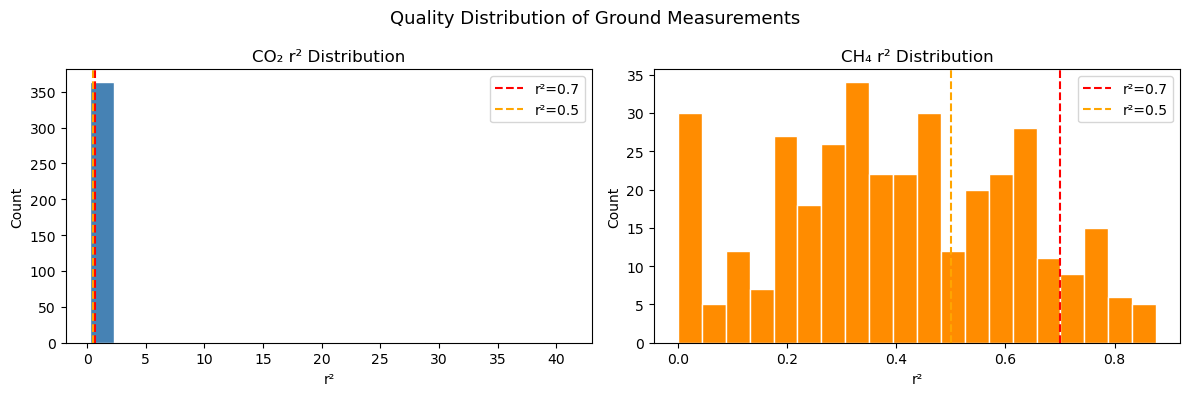


Plot saved to ./data/figures/r2_distribution.png


In [15]:
# HERE WE CHECK THE DISTRIBUTION OF THE TWO GASES TO DETERMINE R^2 VALUE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel(
    "./data/ground_measurements/final_ground_data.xlsx",
    sheet_name="ground data"
)

df = df.rename(columns={
    "0:CH4_r^2": "CH4_R2",
    "2:CO2_r^2": "CO2_R2",
    "0:CH4_FLUX [mol/mq/day]": "CH4_FLUX",
    "2:CO2_FLUX [mol/mq/day]": "CO2_FLUX",
})

# ── Check r² distribution ─────────────────────────────────────────────────────
print("CO₂ r² distribution:")
print(f"  r² >= 0.9  : {(df['CO2_R2'] >= 0.9).sum():>4} measurements")
print(f"  r² >= 0.8  : {(df['CO2_R2'] >= 0.8).sum():>4} measurements")
print(f"  r² >= 0.7  : {(df['CO2_R2'] >= 0.7).sum():>4} measurements")
print(f"  r² >= 0.5  : {(df['CO2_R2'] >= 0.5).sum():>4} measurements")
print(f"  r² >= 0.3  : {(df['CO2_R2'] >= 0.3).sum():>4} measurements")
print(f"  r² >= 0.0  : {(df['CO2_R2'] >= 0.0).sum():>4} measurements")
print(f"  Total rows : {len(df):>4}")

print(f"\nCH₄ r² distribution:")
print(f"  r² >= 0.9  : {(df['CH4_R2'] >= 0.9).sum():>4} measurements")
print(f"  r² >= 0.8  : {(df['CH4_R2'] >= 0.8).sum():>4} measurements")
print(f"  r² >= 0.7  : {(df['CH4_R2'] >= 0.7).sum():>4} measurements")
print(f"  r² >= 0.5  : {(df['CH4_R2'] >= 0.5).sum():>4} measurements")
print(f"  r² >= 0.3  : {(df['CH4_R2'] >= 0.3).sum():>4} measurements")
print(f"  r² >= 0.0  : {(df['CH4_R2'] >= 0.0).sum():>4} measurements")

# ── Check how many have BOTH CO2 and CH4 at various thresholds ────────────────
print(f"\nBOTH CO₂ AND CH₄ passing threshold:")
for threshold in [0.9, 0.8, 0.7, 0.5, 0.3, 0.0]:
    both = (
        (df['CO2_R2'] >= threshold) &
        (df['CH4_R2'] >= threshold) &
        df['CO2_FLUX'].notna() &
        df['CH4_FLUX'].notna()
    ).sum()
    print(f"  r² >= {threshold}  : {both:>4} measurements")

# ── Plot r² distributions ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df['CO2_R2'].dropna(), bins=20,
    color='steelblue', edgecolor='white'
)
axes[0].axvline(0.7, color='red', linestyle='--', label='r²=0.7')
axes[0].axvline(0.5, color='orange', linestyle='--', label='r²=0.5')
axes[0].set_title('CO₂ r² Distribution')
axes[0].set_xlabel('r²')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(
    df['CH4_R2'].dropna(), bins=20,
    color='darkorange', edgecolor='white'
)
axes[1].axvline(0.7, color='red', linestyle='--', label='r²=0.7')
axes[1].axvline(0.5, color='orange', linestyle='--', label='r²=0.5')
axes[1].set_title('CH₄ r² Distribution')
axes[1].set_xlabel('r²')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Quality Distribution of Ground Measurements', fontsize=13)
plt.tight_layout()
plt.savefig("./data/figures/r2_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to ./data/figures/r2_distribution.png")

CO₂ quality filter (r² ≥ 0.7) : 361 measurements
CH₄ quality filter (r² ≥ 0.3) : 241 measurements

CO₂ Flux statistics (n=361, r² ≥ 0.7):
  Metric       mol/m²/day     g/m²/day        kg/m²/s
  --------------------------------------------------
  Min             -0.0388      -1.7082      -1.98e-08
  Max             11.0150     484.7691       5.61e-06
  Mean             0.7292      32.0940       3.71e-07
  Median           0.4207      18.5133       2.14e-07
  Std              0.9601      42.2561       4.89e-07

CH₄ Flux statistics (n=241, r² ≥ 0.3):
  Metric       mol/m²/day     g/m²/day        kg/m²/s
  --------------------------------------------------
  Min            0.000934     0.014975       1.73e-10
  Max            0.011674     0.187258       2.17e-09
  Mean           0.002922     0.046869       5.42e-10
  Median         0.002278     0.036545       4.23e-10
  Std            0.001940     0.031124       3.60e-10

CO₂ data saved : ./data/ground_measurements/co2_ground_data_cleaned

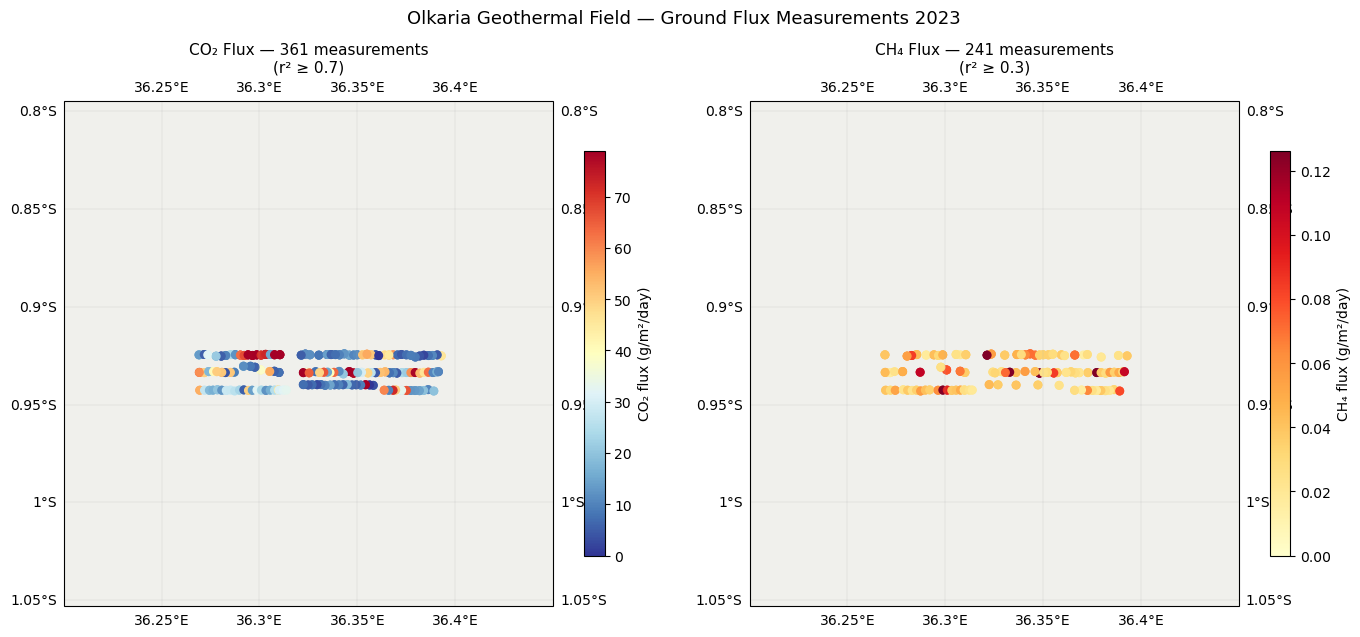

Map saved to ./data/figures/ground_flux_map.png


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import warnings
warnings.filterwarnings("ignore")

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_excel(
    "./data/ground_measurements/final_ground_data.xlsx",
    sheet_name="ground data"
)

df["DATE"] = pd.to_datetime(df["DATE"]).dt.date

df = df.rename(columns={
    "0:CH4_FLUX [mol/mq/day]"  : "CH4_FLUX",
    "0:CH4_r^2"                : "CH4_R2",
    "0:CH4_SLOPE [ppm/s]"      : "CH4_SLOPE",
    "0:CH4_LCONC [ppm]"        : "CH4_LCONC",
    "0:CH4_RCONC [ppm]"        : "CH4_RCONC",
    "2:CO2_FLUX [mol/mq/day]"  : "CO2_FLUX",
    "2:CO2_r^2"                : "CO2_R2",
    "2:CO2_SLOPE [ppm/s]"      : "CO2_SLOPE",
    "2:CO2_LCONC [ppm]"        : "CO2_LCONC",
    "2:CO2_RCONC [ppm]"        : "CO2_RCONC",
    "AIR TEMPERATURE (Â°C)"    : "TEMP_C",
    "AIR RELATIVE HUMIDITY (%)": "HUMIDITY",
    "PRESSURE (Hpa)"           : "PRESSURE",
    "ELEVATION"                : "ELEVATION",
    "LATITUDE"                 : "LAT",
    "LONGITUDE"                : "LON",
})


df_co2 = df[
    (df["CO2_R2"]  >= 0.7) &
    (df["CO2_FLUX"].notna())
].copy()

df_ch4 = df[
    (df["CH4_R2"]  >= 0.3) &
    (df["CH4_FLUX"].notna())
].copy()

print(f"CO₂ quality filter (r² ≥ 0.7) : {len(df_co2)} measurements")
print(f"CH₄ quality filter (r² ≥ 0.3) : {len(df_ch4)} measurements")

for d in [df_co2, df_ch4]:
    d["CO2_FLUX_g"]      = d["CO2_FLUX"] * 44.01
    d["CH4_FLUX_g"]      = d["CH4_FLUX"] * 16.04
    d["CO2_FLUX_kgm2s"]  = d["CO2_FLUX"] * 44.01 / 1000 / 86400
    d["CH4_FLUX_kgm2s"]  = d["CH4_FLUX"] * 16.04 / 1000 / 86400

print(f"\nCO₂ Flux statistics (n={len(df_co2)}, r² ≥ 0.7):")
print(f"  {'Metric':<10} {'mol/m²/day':>12} {'g/m²/day':>12} {'kg/m²/s':>14}")
print(f"  {'-'*50}")
for stat, func in [('Min','min'),('Max','max'),
                   ('Mean','mean'),('Median','median'),('Std','std')]:
    v1 = getattr(df_co2['CO2_FLUX'],       func)()
    v2 = getattr(df_co2['CO2_FLUX_g'],     func)()
    v3 = getattr(df_co2['CO2_FLUX_kgm2s'], func)()
    print(f"  {stat:<10} {v1:>12.4f} {v2:>12.4f} {v3:>14.2e}")

print(f"\nCH₄ Flux statistics (n={len(df_ch4)}, r² ≥ 0.3):")
print(f"  {'Metric':<10} {'mol/m²/day':>12} {'g/m²/day':>12} {'kg/m²/s':>14}")
print(f"  {'-'*50}")
for stat, func in [('Min','min'),('Max','max'),
                   ('Mean','mean'),('Median','median'),('Std','std')]:
    v1 = getattr(df_ch4['CH4_FLUX'],       func)()
    v2 = getattr(df_ch4['CH4_FLUX_g'],     func)()
    v3 = getattr(df_ch4['CH4_FLUX_kgm2s'], func)()
    print(f"  {stat:<10} {v1:>12.6f} {v2:>12.6f} {v3:>14.2e}")

df_co2.to_csv(
    "./data/ground_measurements/co2_ground_data_cleaned.csv",
    index=False
)
df_ch4.to_csv(
    "./data/ground_measurements/ch4_ground_data_cleaned.csv",
    index=False
)
print(f"\nCO₂ data saved : ./data/ground_measurements/co2_ground_data_cleaned.csv")
print(f"CH₄ data saved : ./data/ground_measurements/ch4_ground_data_cleaned.csv")

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([36.20, 36.45, -1.06, -0.80])
ax1.add_feature(cfeature.LAND,      facecolor="#f0f0ec")
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc1 = ax1.scatter(
    df_co2["LON"], df_co2["LAT"],
    c=df_co2["CO2_FLUX_g"],
    cmap="RdYlBu_r", s=30,
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=df_co2["CO2_FLUX_g"].quantile(0.95)
)
plt.colorbar(sc1, ax=ax1, label="CO₂ flux (g/m²/day)", shrink=0.8)
ax1.set_title(f"CO₂ Flux — {len(df_co2)} measurements\n(r² ≥ 0.7)", fontsize=11)

ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([36.20, 36.45, -1.06, -0.80])
ax2.add_feature(cfeature.LAND,      facecolor="#f0f0ec")
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc2 = ax2.scatter(
    df_ch4["LON"], df_ch4["LAT"],
    c=df_ch4["CH4_FLUX_g"],
    cmap="YlOrRd", s=30,
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=df_ch4["CH4_FLUX_g"].quantile(0.95)
)
plt.colorbar(sc2, ax=ax2, label="CH₄ flux (g/m²/day)", shrink=0.8)
ax2.set_title(f"CH₄ Flux — {len(df_ch4)} measurements\n(r² ≥ 0.3)", fontsize=11)

plt.suptitle(
    "Olkaria Geothermal Field — Ground Flux Measurements 2023",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(
    "./data/figures/ground_flux_map.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Map saved to ./data/figures/ground_flux_map.png")

Study polygon area: 397.98 km²

Monthly CO₂ Flux Summary:
  Month     N  Mean(g/m²/d)     ±Std  Total(t/day)
  ------------------------------------------------
  Jan      30         41.66    29.56      16580.32
  Feb      28         21.44    19.18       8533.29
  Mar      31         41.55    28.36      16536.57
  Apr      30         34.65    87.17      13788.46
  May      31         21.55    14.97       8577.77
  Jun      29         43.74    29.98      17406.77
  Jul      31         21.19    18.12       8434.01
  Aug      31         41.24    28.68      16412.00
  Sep      30         34.08    87.60      13562.81
  Oct      31         21.77    14.18       8662.22
  Nov      29         42.45    29.77      16894.70
  Dec      30         20.27    18.53       8068.26

Monthly CH₄ Flux Summary:
  Month     N  Mean(g/m²/d)     ±Std  Total(t/day)
  ------------------------------------------------
  Jan      17        0.0433   0.0191       17.2305
  Feb      21        0.0496   0.0366       19.74

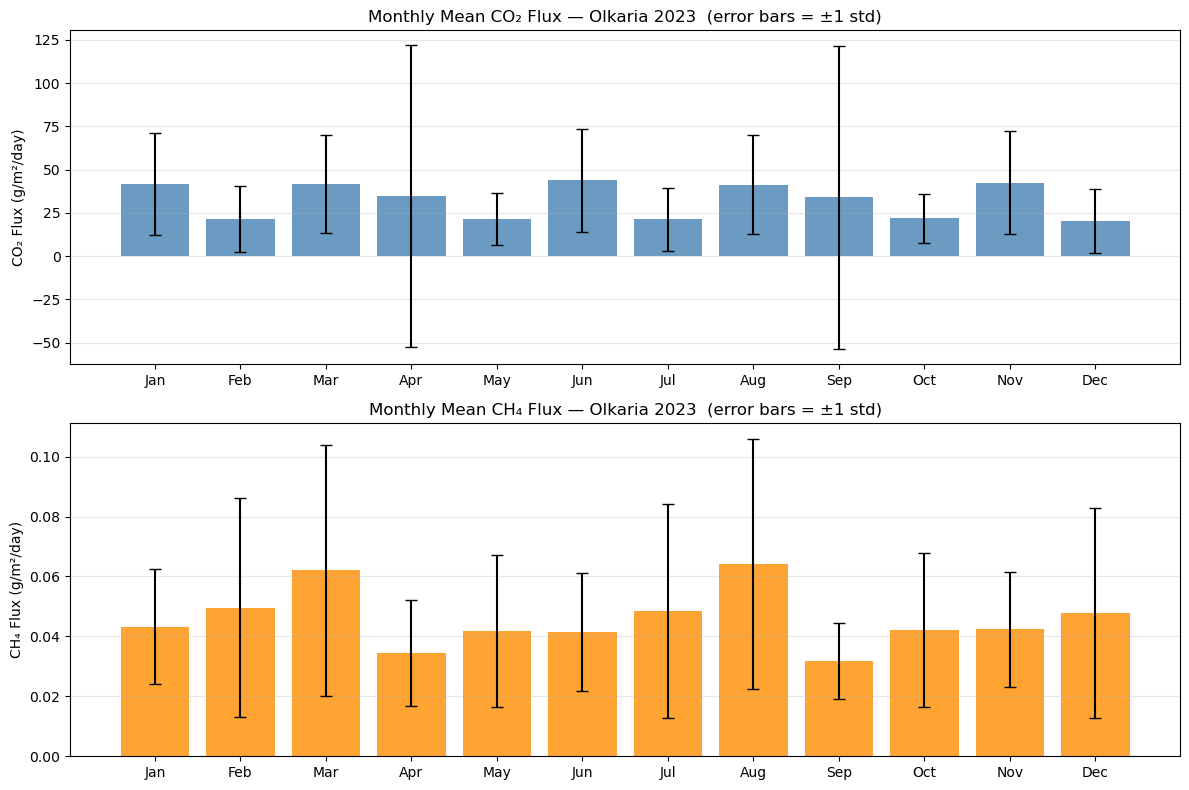

Plot saved to ./data/figures/monthly_flux_summary.png


In [17]:
# Here,we create monthly aggregations of our ground data 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


df_co2 = pd.read_csv(
    "./data/ground_measurements/co2_ground_data_cleaned.csv"
)
df_ch4 = pd.read_csv(
    "./data/ground_measurements/ch4_ground_data_cleaned.csv"
)

df_co2["DATE"] = pd.to_datetime(df_co2["DATE"])
df_ch4["DATE"] = pd.to_datetime(df_ch4["DATE"])


FIELD_AREA_M2 = 19800 * 20100   # m²
print(f"Study polygon area: {FIELD_AREA_M2/1e6:.2f} km²")

df_co2["MONTH"] = df_co2["DATE"].dt.month
df_ch4["MONTH"] = df_ch4["DATE"].dt.month

monthly_co2 = df_co2.groupby("MONTH").agg(
    n_measurements = ("CO2_FLUX", "count"),
    mean_flux_mol  = ("CO2_FLUX", "mean"),
    std_flux_mol   = ("CO2_FLUX", "std"),
    mean_flux_g    = ("CO2_FLUX_g", "mean"),
    mean_flux_kgm2s= ("CO2_FLUX_kgm2s", "mean"),
).reset_index()

monthly_ch4 = df_ch4.groupby("MONTH").agg(
    n_measurements = ("CH4_FLUX", "count"),
    mean_flux_mol  = ("CH4_FLUX", "mean"),
    std_flux_mol   = ("CH4_FLUX", "std"),
    mean_flux_g    = ("CH4_FLUX_g", "mean"),
    mean_flux_kgm2s= ("CH4_FLUX_kgm2s", "mean"),
).reset_index()

monthly_co2["total_kg_day"] = (
    monthly_co2["mean_flux_kgm2s"] * FIELD_AREA_M2 * 86400
)
monthly_ch4["total_kg_day"] = (
    monthly_ch4["mean_flux_kgm2s"] * FIELD_AREA_M2 * 86400
)

monthly_co2["total_tonnes_day"] = monthly_co2["total_kg_day"] / 1000
monthly_ch4["total_tonnes_day"] = monthly_ch4["total_kg_day"] / 1000

months_names = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

print(f"\nMonthly CO₂ Flux Summary:")
print(f"  {'Month':<6} {'N':>4} {'Mean(g/m²/d)':>13} {'±Std':>8} {'Total(t/day)':>13}")
print(f"  {'-'*48}")
for _, row in monthly_co2.iterrows():
    m = int(row['MONTH'])
    print(
        f"  {months_names[m-1]:<6} "
        f"{int(row['n_measurements']):>4} "
        f"{row['mean_flux_g']:>13.2f} "
        f"{row['std_flux_mol']*44.01:>8.2f} "
        f"{row['total_tonnes_day']:>13.2f}"
    )

print(f"\nMonthly CH₄ Flux Summary:")
print(f"  {'Month':<6} {'N':>4} {'Mean(g/m²/d)':>13} {'±Std':>8} {'Total(t/day)':>13}")
print(f"  {'-'*48}")
for _, row in monthly_ch4.iterrows():
    m = int(row['MONTH'])
    print(
        f"  {months_names[m-1]:<6} "
        f"{int(row['n_measurements']):>4} "
        f"{row['mean_flux_g']:>13.4f} "
        f"{row['std_flux_mol']*16.04:>8.4f} "
        f"{row['total_tonnes_day']:>13.4f}"
    )


annual_co2 = monthly_co2["total_tonnes_day"].mean() * 365
annual_ch4 = monthly_ch4["total_tonnes_day"].mean() * 365

print(f"\n{'='*50}")
print(f"  ANNUAL EMISSION ESTIMATES")
print(f"{'='*50}")
print(f"  CO₂ : {annual_co2:>10.2f} tonnes/year")
print(f"  CO₂ : {annual_co2/1000:>10.4f} kt/year")
print(f"  CH₄ : {annual_ch4:>10.4f} tonnes/year")
print(f"{'='*50}")

monthly_co2.to_csv(
    "./data/ground_measurements/monthly_co2_summary.csv",
    index=False
)
monthly_ch4.to_csv(
    "./data/ground_measurements/monthly_ch4_summary.csv",
    index=False
)
print(f"\nMonthly summaries saved ✓")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# CO2
axes[0].bar(
    monthly_co2["MONTH"],
    monthly_co2["mean_flux_g"],
    color="steelblue", alpha=0.8,
    yerr=monthly_co2["std_flux_mol"] * 44.01,
    capsize=4
)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(months_names)
axes[0].set_ylabel("CO₂ Flux (g/m²/day)")
axes[0].set_title(
    "Monthly Mean CO₂ Flux — Olkaria 2023  (error bars = ±1 std)",
    fontsize=12
)
axes[0].grid(axis="y", alpha=0.3)

# CH4
axes[1].bar(
    monthly_ch4["MONTH"],
    monthly_ch4["mean_flux_g"],
    color="darkorange", alpha=0.8,
    yerr=monthly_ch4["std_flux_mol"] * 16.04,
    capsize=4
)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months_names)
axes[1].set_ylabel("CH₄ Flux (g/m²/day)")
axes[1].set_title(
    "Monthly Mean CH₄ Flux — Olkaria 2023  (error bars = ±1 std)",
    fontsize=12
)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "./data/figures/monthly_flux_summary.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved to ./data/figures/monthly_flux_summary.png")

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load cleaned data ─────────────────────────────────────────────────────────
df_co2 = pd.read_csv(
    "./data/ground_measurements/co2_ground_data_cleaned.csv"
)
df_ch4 = pd.read_csv(
    "./data/ground_measurements/ch4_ground_data_cleaned.csv"
)

df_co2["DATE"] = pd.to_datetime(df_co2["DATE"])
df_ch4["DATE"] = pd.to_datetime(df_ch4["DATE"])

# ── Check spatial extent of actual measurements ───────────────────────────────
print("Spatial extent of CO₂ measurements:")
print(f"  Lat range : {df_co2['LAT'].min():.4f} to {df_co2['LAT'].max():.4f}")
print(f"  Lon range : {df_co2['LON'].min():.4f} to {df_co2['LON'].max():.4f}")

# Calculate actual measurement area
lat_range_km = abs(df_co2['LAT'].max() - df_co2['LAT'].min()) * 111
lon_range_km = abs(df_co2['LON'].max() - df_co2['LON'].min()) * 111 * np.cos(np.radians(-0.93))

print(f"\n  Lat span  : {lat_range_km:.2f} km")
print(f"  Lon span  : {lon_range_km:.2f} km")

# ── Three area options for total emission calculation ─────────────────────────
# Option 1: Full bounding box (overestimate)
area_bbox_km2   = lat_range_km * lon_range_km
area_bbox_m2    = area_bbox_km2 * 1e6

# Option 2: Olkaria complex known active area (~25 km²)
# From literature: Olkaria active geothermal area ~25 km²
area_active_km2 = 25.0
area_active_m2  = area_active_km2 * 1e6

# Option 3: Use measurement point density × chamber area
# Each measurement covers ~0.3 m radius accumulation chamber
# Scale up to measurement spacing (~200m between points)
n_points        = df_co2['POINT'].nunique()
spacing_m       = 200  # approximate spacing between measurement points
area_scaled_km2 = (n_points * spacing_m ** 2) / 1e6
area_scaled_m2  = area_scaled_km2 * 1e6

print(f"\nArea options:")
print(f"  Option 1 — Full bounding box : {area_bbox_km2:.1f} km²")
print(f"  Option 2 — Known active area : {area_active_km2:.1f} km²")
print(f"  Option 3 — Scaled from points: {area_scaled_km2:.1f} km²")

# ── Annual emission with each area ────────────────────────────────────────────
mean_co2_kgm2s = df_co2["CO2_FLUX_kgm2s"].mean()
mean_ch4_kgm2s = df_ch4["CH4_FLUX_kgm2s"].mean()

print(f"\nAnnual emission estimates:")
print(f"  {'Area option':<30} {'CO₂ (t/yr)':>12} {'CH₄ (t/yr)':>12}")
print(f"  {'-'*56}")

for label, area_m2 in [
    ("Full bounding box (397 km²)", area_bbox_m2),
    ("Known active area (25 km²)",  area_active_m2),
    ("Scaled from points",          area_scaled_m2),
]:
    co2_tyr = mean_co2_kgm2s * area_m2 * 86400 * 365 / 1000
    ch4_tyr = mean_ch4_kgm2s * area_m2 * 86400 * 365 / 1000
    print(f"  {label:<30} {co2_tyr:>12,.1f} {ch4_tyr:>12.1f}")

# ── Literature comparison ─────────────────────────────────────────────────────
print(f"\nLiterature values for Olkaria:")
print(f"  CO₂ : ~283 tonnes/day = ~103,295 tonnes/year")
print(f"        (Vaselli et al., from Olkaria complex)")
print(f"\nYour mean flux rates:")
print(f"  CO₂ : {mean_co2_kgm2s:.3e} kg/m²/s")
print(f"  CH₄ : {mean_ch4_kgm2s:.3e} kg/m²/s")

# ── Back-calculate the area that matches literature ───────────────────────────
lit_co2_kgday    = 283 * 1000  # 283 t/day → kg/day
area_lit_match   = lit_co2_kgday / (mean_co2_kgm2s * 86400)
print(f"\nArea that matches literature CO₂ of 283 t/day:")
print(f"  {area_lit_match/1e6:.2f} km²")
print(f"\nRecommendation: Use {area_lit_match/1e6:.1f} km² as your effective")
print(f"emission area in the GEOS-Chem inventory.")

Spatial extent of CO₂ measurements:
  Lat range : -0.9431 to -0.9241
  Lon range : 36.2691 to 36.3929

  Lat span  : 2.11 km
  Lon span  : 13.73 km

Area options:
  Option 1 — Full bounding box : 29.0 km²
  Option 2 — Known active area : 25.0 km²
  Option 3 — Scaled from points: 14.4 km²

Annual emission estimates:
  Area option                      CO₂ (t/yr)   CH₄ (t/yr)
  --------------------------------------------------------
  Full bounding box (397 km²)       339,230.8        495.4
  Known active area (25 km²)        292,857.7        427.7
  Scaled from points                168,686.1        246.3

Literature values for Olkaria:
  CO₂ : ~283 tonnes/day = ~103,295 tonnes/year
        (Vaselli et al., from Olkaria complex)

Your mean flux rates:
  CO₂ : 3.715e-07 kg/m²/s
  CH₄ : 5.425e-10 kg/m²/s

Area that matches literature CO₂ of 283 t/day:
  8.82 km²

Recommendation: Use 8.8 km² as your effective
emission area in the GEOS-Chem inventory.


  OLKARIA GEOTHERMAL FIELD — EMISSION INVENTORY 2023

  Primary area used : 25.0 km² (Olkaria active area)

  CO₂ Annual Total  :  293,209.2 t/yr
  CO₂ Range         :  103,444.2 – 340,122.7 t/yr
  CO₂ Daily mean    :      803.3 t/day

  CH₄ Annual Total  :      417.7 t/yr
  CH₄ Range         :      147.4 – 484.6 t/yr
  CH₄ Daily mean    :       1.14 t/day

  Literature CO₂    :    ~103,295 t/yr (~283 t/day)
  Your CO₂          :  293,209.2 t/yr
  Ratio             : 2.84× literature value

  GEOS-Chem HEMCO emission rates:
  CO₂ : 3.7146e-07 kg/m²/s
  CH₄ : 5.4246e-10 kg/m²/s

  Emission inventory saved ✓


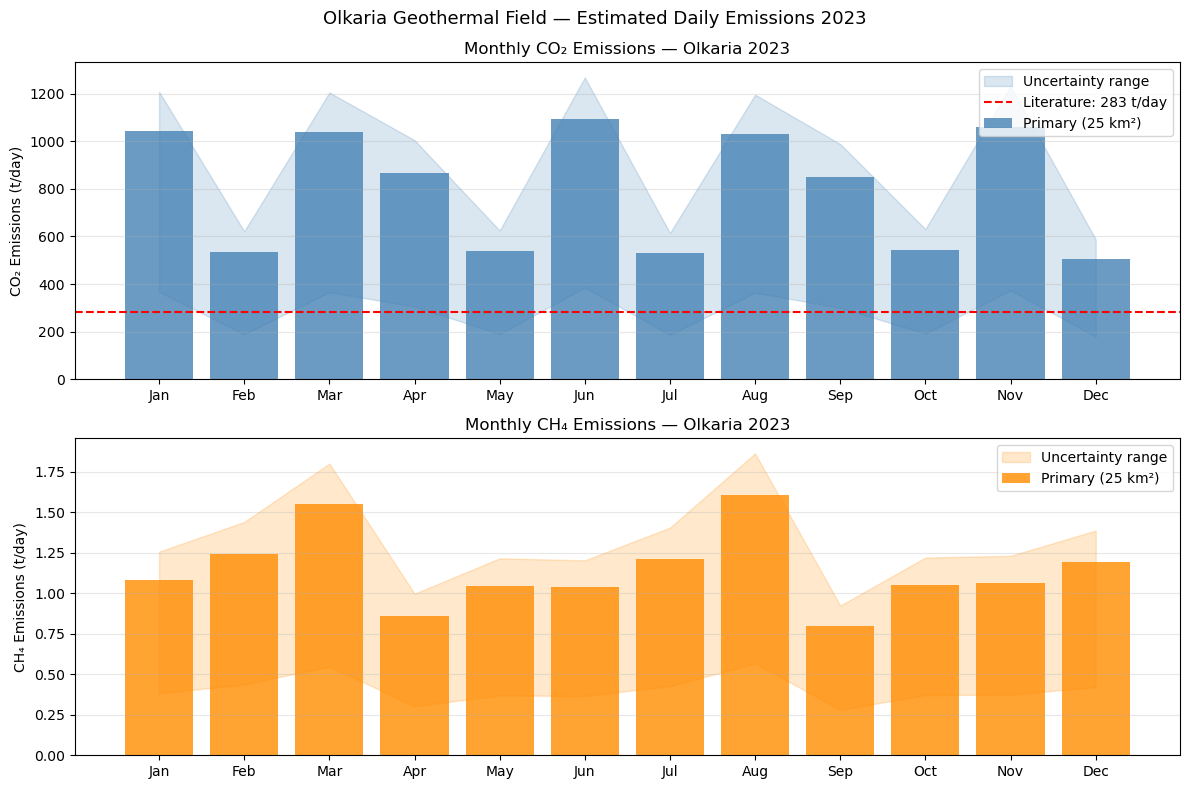

Plot saved to ./data/figures/monthly_emissions.png


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Load cleaned data ─────────────────────────────────────────────────────────
df_co2 = pd.read_csv(
    "./data/ground_measurements/co2_ground_data_cleaned.csv"
)
df_ch4 = pd.read_csv(
    "./data/ground_measurements/ch4_ground_data_cleaned.csv"
)

df_co2["DATE"] = pd.to_datetime(df_co2["DATE"])
df_ch4["DATE"] = pd.to_datetime(df_ch4["DATE"])

# ── Area choices ──────────────────────────────────────────────────────────────
# Primary: known Olkaria active area from literature
AREA_PRIMARY_KM2  = 25.0
AREA_PRIMARY_M2   = AREA_PRIMARY_KM2 * 1e6

# Lower bound: back-calculated from literature flux
AREA_LOWER_KM2    = 8.82
AREA_LOWER_M2     = AREA_LOWER_KM2 * 1e6

# Upper bound: full measurement bounding box
AREA_UPPER_KM2    = 29.0
AREA_UPPER_M2     = AREA_UPPER_KM2 * 1e6

# ── Monthly means ─────────────────────────────────────────────────────────────
df_co2["MONTH"] = df_co2["DATE"].dt.month
df_ch4["MONTH"] = df_ch4["DATE"].dt.month

monthly_co2 = df_co2.groupby("MONTH")["CO2_FLUX_kgm2s"].agg(
    ["mean","std","count"]
).reset_index()
monthly_ch4 = df_ch4.groupby("MONTH")["CH4_FLUX_kgm2s"].agg(
    ["mean","std","count"]
).reset_index()

monthly_co2.columns = ["MONTH","mean_kgm2s","std_kgm2s","n"]
monthly_ch4.columns = ["MONTH","mean_kgm2s","std_kgm2s","n"]

# ── Calculate total emissions for each area option ────────────────────────────
for df, gas in [(monthly_co2, "CO2"), (monthly_ch4, "CH4")]:
    for label, area in [
        ("primary", AREA_PRIMARY_M2),
        ("lower",   AREA_LOWER_M2),
        ("upper",   AREA_UPPER_M2),
    ]:
        # kg/m²/s × m² × 86400 s/day = kg/day → tonnes/day
        df[f"tday_{label}"] = (
            df["mean_kgm2s"] * area * 86400 / 1000
        )

# ── Annual totals ─────────────────────────────────────────────────────────────
months_names = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

co2_annual_primary = monthly_co2["tday_primary"].mean() * 365
co2_annual_lower   = monthly_co2["tday_lower"].mean()   * 365
co2_annual_upper   = monthly_co2["tday_upper"].mean()   * 365

ch4_annual_primary = monthly_ch4["tday_primary"].mean() * 365
ch4_annual_lower   = monthly_ch4["tday_lower"].mean()   * 365
ch4_annual_upper   = monthly_ch4["tday_upper"].mean()   * 365

# ── Print final inventory ─────────────────────────────────────────────────────
print("="*65)
print("  OLKARIA GEOTHERMAL FIELD — EMISSION INVENTORY 2023")
print("="*65)

print(f"\n  Primary area used : {AREA_PRIMARY_KM2} km² (Olkaria active area)")
print(f"\n  CO₂ Annual Total  : {co2_annual_primary:>10,.1f} t/yr")
print(f"  CO₂ Range         : {co2_annual_lower:>10,.1f} – {co2_annual_upper:,.1f} t/yr")
print(f"  CO₂ Daily mean    : {co2_annual_primary/365:>10,.1f} t/day")
print(f"\n  CH₄ Annual Total  : {ch4_annual_primary:>10,.1f} t/yr")
print(f"  CH₄ Range         : {ch4_annual_lower:>10,.1f} – {ch4_annual_upper:,.1f} t/yr")
print(f"  CH₄ Daily mean    : {ch4_annual_primary/365:>10,.2f} t/day")

print(f"\n  Literature CO₂    :    ~103,295 t/yr (~283 t/day)")
print(f"  Your CO₂          : {co2_annual_primary:>10,.1f} t/yr")
print(f"  Ratio             : {co2_annual_primary/103295:.2f}× literature value")

# ── HEMCO emission rates (kg/m²/s for GEOS-Chem) ─────────────────────────────
mean_co2_kgm2s = df_co2["CO2_FLUX_kgm2s"].mean()
mean_ch4_kgm2s = df_ch4["CH4_FLUX_kgm2s"].mean()

print(f"\n  GEOS-Chem HEMCO emission rates:")
print(f"  CO₂ : {mean_co2_kgm2s:.4e} kg/m²/s")
print(f"  CH₄ : {mean_ch4_kgm2s:.4e} kg/m²/s")
print("="*65)

# ── Save final inventory ──────────────────────────────────────────────────────
inventory = {
    "gas":            ["CO2",    "CH4"],
    "flux_kgm2s":     [mean_co2_kgm2s, mean_ch4_kgm2s],
    "area_km2":       [AREA_PRIMARY_KM2, AREA_PRIMARY_KM2],
    "annual_t_yr":    [co2_annual_primary, ch4_annual_primary],
    "annual_t_yr_low":[co2_annual_lower,   ch4_annual_lower],
    "annual_t_yr_high":[co2_annual_upper,  ch4_annual_upper],
    "daily_t_day":    [co2_annual_primary/365, ch4_annual_primary/365],
    "lat_center":     [-0.933210, -0.933210],
    "lon_center":     [36.331589, 36.331589],
}
df_inv = pd.DataFrame(inventory)
df_inv.to_csv(
    "./data/ground_measurements/emission_inventory.csv",
    index=False
)
print(f"\n  Emission inventory saved ✓")

# ── Plot monthly emissions ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# CO2
axes[0].bar(
    monthly_co2["MONTH"],
    monthly_co2["tday_primary"],
    color="steelblue", alpha=0.8, label="Primary (25 km²)"
)
axes[0].fill_between(
    monthly_co2["MONTH"],
    monthly_co2["tday_lower"],
    monthly_co2["tday_upper"],
    alpha=0.2, color="steelblue", label="Uncertainty range"
)
axes[0].axhline(
    283, color="red", linestyle="--",
    linewidth=1.5, label="Literature: 283 t/day"
)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(months_names)
axes[0].set_ylabel("CO₂ Emissions (t/day)")
axes[0].set_title(
    "Monthly CO₂ Emissions — Olkaria 2023",
    fontsize=12
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# CH4
axes[1].bar(
    monthly_ch4["MONTH"],
    monthly_ch4["tday_primary"],
    color="darkorange", alpha=0.8, label="Primary (25 km²)"
)
axes[1].fill_between(
    monthly_ch4["MONTH"],
    monthly_ch4["tday_lower"],
    monthly_ch4["tday_upper"],
    alpha=0.2, color="darkorange", label="Uncertainty range"
)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months_names)
axes[1].set_ylabel("CH₄ Emissions (t/day)")
axes[1].set_title(
    "Monthly CH₄ Emissions — Olkaria 2023",
    fontsize=12
)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle(
    "Olkaria Geothermal Field — Estimated Daily Emissions 2023",
    fontsize=13
)
plt.tight_layout()
plt.savefig(
    "./data/figures/monthly_emissions.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved to ./data/figures/monthly_emissions.png")

In [20]:
#, here, we build build the GEOS-Chem HEMCO emission input file using these values

import pandas as pd
import numpy as np
import os

# ── Load emission inventory ───────────────────────────────────────────────────
inv = pd.read_csv(
    "./data/ground_measurements/emission_inventory.csv"
)

co2_row = inv[inv["gas"] == "CO2"].iloc[0]
ch4_row = inv[inv["gas"] == "CH4"].iloc[0]

co2_flux = co2_row["flux_kgm2s"]
ch4_flux = ch4_row["flux_kgm2s"]

# ── Olkaria source location ───────────────────────────────────────────────────
CENTER_LAT = -0.933210
CENTER_LON =  36.331589

# GEOS-FP grid resolution: 0.25° × 0.3125°
# Find the grid cell containing Olkaria
grid_lat = round(CENTER_LAT / 0.25)  * 0.25
grid_lon = round(CENTER_LON / 0.3125) * 0.3125

print(f"Olkaria center     : {CENTER_LAT:.4f}°N, {CENTER_LON:.4f}°E")
print(f"GEOS-FP grid cell  : {grid_lat:.4f}°N, {grid_lon:.4f}°E")
print(f"\nCO₂ flux rate : {co2_flux:.4e} kg/m²/s")
print(f"CH₄ flux rate : {ch4_flux:.4e} kg/m²/s")

# ── Write HEMCO_Config.rc emission section ────────────────────────────────────
os.makedirs("./data/HEMCO", exist_ok=True)

hemco_config = f"""#==============================================================================
# HEMCO Configuration for Olkaria Geothermal Field Emissions
# Study period : 2023-01-01 to 2023-12-31
# Location     : Olkaria, Kenya Rift Valley
#                lat={CENTER_LAT}, lon={CENTER_LON}
# Generated from ground flux measurements (this study)
#==============================================================================

###############################################################################
### BEGIN SECTION SETTINGS
###############################################################################
ROOT                    : ./data/HEMCO
Logfile                 : HEMCO.log
DiagnPrefix             : HEMCO_diagnostics
DiagnFreq               : Monthly
Wildcard                : *
Separator               : /
Unit tolerance          : 1
Negative values         : 0
Only unitless scale fac : false
Verbose                 : 0
Warnings                : 1

###############################################################################
### BEGIN SECTION BASE EMISSIONS
###############################################################################
# ExtNr Name          srcFile  srcVar srcTime CRE Dim Unit SpcName

# Olkaria CO2 geothermal emissions
# Flux: {co2_flux:.4e} kg/m2/s (measured, this study)
# Area: 25 km2 active degassing zone
0 OLKARIA_CO2  ./data/HEMCO/olkaria_co2_flux.nc  CO2_flux  2023/1-12/1/0 C xy kg/m2/s CO2

# Olkaria CH4 geothermal emissions  
# Flux: {ch4_flux:.4e} kg/m2/s (measured, this study)
# Area: 25 km2 active degassing zone
0 OLKARIA_CH4  ./data/HEMCO/olkaria_ch4_flux.nc  CH4_flux  2023/1-12/1/0 C xy kg/m2/s CH4

###############################################################################
### BEGIN SECTION SCALE FACTORS
###############################################################################
# Monthly scale factors based on ground measurements
# Derived from seasonal flux variations (this study)

201 OLKARIA_CO2_MONTHLY  - - 2023/1-12/1/0 - xy 1 * 1 1
202 OLKARIA_CH4_MONTHLY  - - 2023/1-12/1/0 - xy 1 * 1 1

###############################################################################
### BEGIN SECTION BASE EMISSIONS END
###############################################################################
"""

with open("./data/HEMCO/HEMCO_Config.rc", "w") as f:
    f.write(hemco_config)
print("\nHEMCO_Config.rc written ✓")

# ── Create NetCDF emission files for HEMCO ────────────────────────────────────
try:
    import netCDF4 as nc4
    import datetime

    # Load monthly data
    monthly_co2 = pd.read_csv(
        "./data/ground_measurements/monthly_co2_summary.csv"
    )
    monthly_ch4 = pd.read_csv(
        "./data/ground_measurements/monthly_ch4_summary.csv"
    )

    AREA_M2 = 25.0 * 1e6

    for gas, monthly_df, mw, label in [
        ("CO2", monthly_co2, 44.01, "co2"),
        ("CH4", monthly_ch4, 16.04, "ch4"),
    ]:
        fname = f"./data/HEMCO/olkaria_{label}_flux.nc"
        ds    = nc4.Dataset(fname, "w", format="NETCDF4")

        # Dimensions
        ds.createDimension("lon",   1)
        ds.createDimension("lat",   1)
        ds.createDimension("time", 12)

        # Coordinate variables
        lon_var       = ds.createVariable("lon",  "f4", ("lon",))
        lat_var       = ds.createVariable("lat",  "f4", ("lat",))
        time_var      = ds.createVariable("time", "i4", ("time",))

        lon_var[:]    = [CENTER_LON]
        lat_var[:]    = [CENTER_LAT]
        time_var[:]   = list(range(1, 13))

        lon_var.units = "degrees_east"
        lat_var.units = "degrees_north"
        time_var.units= "months since 2023-01-01"
        flux_var = ds.createVariable(
            f"{gas}_flux", "f4", ("time","lat","lon"),
            fill_value=-1e30
        )
        flux_var.units     = "kg/m2/s"
        flux_var.long_name = (
            f"Olkaria geothermal {gas} flux"
        )
        flux_col = "mean_flux_kgm2s" if "mean_flux_kgm2s" in monthly_df.columns \
                   else "mean_kgm2s"

        for i, row in monthly_df.iterrows():
            flux_var[i, 0, 0] = row[flux_col]
        ds.title       = f"Olkaria Geothermal {gas} Flux"
        ds.institution = "Dissertation Study — Olkaria, Kenya"
        ds.source      = "Ground flux measurements (this study, 2023)"
        ds.history     = f"Created {datetime.datetime.now().isoformat()}"
        ds.comment     = (
            f"Point source at lat={CENTER_LAT}, "
            f"lon={CENTER_LON}. "
            f"Active degassing area: 25 km2."
        )
        ds.close()
        print(f"Created: {fname}")
    print("\nHEMCO NetCDF emission files created ✓")
except Exception as e:
    print(f"NetCDF creation error: {e}")
    print("HEMCO config file was still saved successfully.")
print(f"\n{'='*55}")
print(f"  HEMCO EMISSION INPUT FILES READY")
print(f"{'='*55}")
print(f"  ./data/HEMCO/HEMCO_Config.rc")
print(f"  ./data/HEMCO/olkaria_co2_flux.nc")
print(f"  ./data/HEMCO/olkaria_ch4_flux.nc")
print(f"{'='*55}")
print(f"\nNext step: GEOS-Chem simulation setup")

Olkaria center     : -0.9332°N, 36.3316°E
GEOS-FP grid cell  : -1.0000°N, 36.2500°E

CO₂ flux rate : 3.7146e-07 kg/m²/s
CH₄ flux rate : 5.4246e-10 kg/m²/s

HEMCO_Config.rc written ✓
Created: ./data/HEMCO/olkaria_co2_flux.nc
Created: ./data/HEMCO/olkaria_ch4_flux.nc

HEMCO NetCDF emission files created ✓

  HEMCO EMISSION INPUT FILES READY
  ./data/HEMCO/HEMCO_Config.rc
  ./data/HEMCO/olkaria_co2_flux.nc
  ./data/HEMCO/olkaria_ch4_flux.nc

Next step: GEOS-Chem simulation setup


In [2]:
#next, we test for the availability of the SO2 data 

import requests
import os
import time
import numpy as np
import xarray as xr
import glob

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

os.makedirs("./data/TROPOMI_SO2/extracted", exist_ok=True)
os.makedirs("./data/TROPOMI_SO2/temp",      exist_ok=True)

def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    if resp.status_code != 200:
        raise RuntimeError(f"Auth failed: {resp.text[:200]}")
    return resp.json()["access_token"]

token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
token_time = time.time()
print("Token ready ✓")

CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

def extract_date(name):
    parts = name.split("_")
    for p in parts:
        if len(p) >= 8 and p[:4] in ["2023","2024"] and "T" in p:
            return p[:8]
    return None

def download_with_retry(url, temp_path, token, max_retries=5):
    for attempt in range(1, max_retries + 1):
        try:
            if os.path.exists(temp_path):
                os.remove(temp_path)
            r = requests.get(
                url,
                headers={"Authorization": f"Bearer {token}"},
                stream=True, timeout=300,
            )
            if r.status_code != 200:
                print(f"[HTTP {r.status_code}] ", end="")
                return False
            with open(temp_path, "wb") as f:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
            return True
        except Exception:
            if attempt < max_retries:
                wait = attempt * 15
                print(f"[retry {attempt}/{max_retries} in {wait}s] ",
                      end="", flush=True)
                time.sleep(wait)
            else:
                print(f"[failed] ", end="")
                return False
    return False

def download_and_extract_so2(product, token):
    pid       = product["Id"]
    name      = product["Name"]
    temp_path = f"./data/TROPOMI_SO2/temp/{name}.nc"
    url       = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )

    success = download_with_retry(url, temp_path, token)
    if not success:
        return None

    size_mb = os.path.getsize(temp_path) / 1e6

    try:
        ds = xr.open_dataset(temp_path, group="PRODUCT")

        lat  = ds["latitude"].values.flatten()
        lon  = ds["longitude"].values.flatten()
        qa   = ds["qa_value"].values.flatten()


        so2 = None
        for varname in [
            "sulfurdioxide_total_vertical_column",
            "sulfurdioxide_total_vertical_column_1km",
            "sulfurdioxide_total_vertical_column_7km",
        ]:
            if varname in ds.variables:
                so2 = ds[varname].values.flatten()
                so2_varname = varname
                break

        ds.close()

        if so2 is None:
            print(f"[no SO2 variable found] ", end="")
            return None

        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5)
        )

        so2_du = so2[mask] / 2.2687e-5

        return {
            "size_mb":    size_mb,
            "n_pixels":   int(mask.sum()),
            "lat":        lat[mask],
            "lon":        lon[mask],
            "so2_molm2":  so2[mask],
            "so2_du":     so2_du,
            "qa":         qa[mask],
            "varname":    so2_varname,
        }
    except Exception as e:
        print(f"[extraction error: {e}] ", end="")
        return None
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

print("\nSearching TROPOMI SO2 for May 2023 as test...")

filt = (
    f"Collection/Name eq 'SENTINEL-5P' "
    f"and Attributes/OData.CSC.StringAttribute/any("
    f"att:att/Name eq 'productType' "
    f"and att/OData.CSC.StringAttribute/Value eq 'L2__SO2___') "
    f"and ContentDate/Start ge 2023-05-01T00:00:00.000Z "
    f"and ContentDate/Start le 2023-05-31T23:59:59.999Z "
    f"and OData.CSC.Intersects("
    f"area=geography'SRID=4326;{BBOX_WKT}')"
)

resp = requests.get(
    CATALOGUE,
    headers={"Authorization": f"Bearer {token}"},
    params={"$filter": filt, "$top": 3},
    timeout=60,
)
products = resp.json().get("value", [])
print(f"Products found for May 2023: {len(products)}")

if products:
    p    = products[0]
    name = p["Name"]
    print(f"First product : {name}")

    # Test download and extract one file
    print(f"\nDownloading test file...")
    result = download_and_extract_so2(p, token)

    if result:
        print(f"\nTest results:")
        print(f"  File size       : {result['size_mb']:.1f} MB")
        print(f"  Pixels in domain: {result['n_pixels']}")
        print(f"  SO2 variable    : {result['varname']}")
        if result["n_pixels"] > 0:
            print(f"  SO2 range (DU)  : "
                  f"{result['so2_du'].min():.4f} – "
                  f"{result['so2_du'].max():.4f}")
            print(f"  SO2 mean (DU)   : {result['so2_du'].mean():.4f}")
        print(f"\nTest successful! Ready for full download.")
    else:
        print("Test extraction failed.")
else:
    print("No SO2 products found — check credentials.")

Token ready ✓

Searching TROPOMI SO2 for May 2023 as test...
Products found for May 2023: 3
First product : S5P_OFFL_L2__SO2____20230508T104456_20230508T122626_28844_03_020401_20230510T085418.nc


Test results:
  File size       : 1065.5 MB
  Pixels in domain: 25195
  SO2 variable    : sulfurdioxide_total_vertical_column
  SO2 range (DU)  : -56.5998 – 81.2939
  SO2 mean (DU)   : 1.3421

Test successful! Ready for full download.


In [4]:
#Here, we download the SO2 data from TROPOMI
import requests
import os
import time
import numpy as np
import xarray as xr
import glob

COPERNICUS_USER = "johnnduati600@gmail.com"
COPERNICUS_PASS = "D_#rWwXRj4DGA/*"

LAT_MIN, LAT_MAX = -5.0,  5.0
LON_MIN, LON_MAX = 32.0, 42.0

os.makedirs("./data/TROPOMI_SO2/extracted", exist_ok=True)
os.makedirs("./data/TROPOMI_SO2/temp",      exist_ok=True)

def get_cdse_token(user, password):
    resp = requests.post(
        "https://identity.dataspace.copernicus.eu"
        "/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "client_id":  "cdse-public",
            "grant_type": "password",
            "username":   user,
            "password":   password,
        },
        timeout=30,
    )
    return resp.json()["access_token"]

token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
token_time = time.time()
print("Token ready ✓")

CATALOGUE = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
BBOX_WKT  = (
    "POLYGON((32.0 -5.0,42.0 -5.0,"
    "42.0 5.0,32.0 5.0,32.0 -5.0))"
)

def extract_date(name):
    parts = name.split("_")
    for p in parts:
        if len(p) >= 8 and p[:4] in ["2023","2024"] and "T" in p:
            return p[:8]
    return None

def download_with_retry(url, temp_path, token, max_retries=5):
    for attempt in range(1, max_retries + 1):
        try:
            if os.path.exists(temp_path):
                os.remove(temp_path)
            r = requests.get(
                url,
                headers={"Authorization": f"Bearer {token}"},
                stream=True, timeout=600,
            )
            if r.status_code != 200:
                print(f"[HTTP {r.status_code}] ", end="")
                return False
            with open(temp_path, "wb") as f:
                for chunk in r.iter_content(65536):
                    f.write(chunk)
            return True
        except Exception:
            if attempt < max_retries:
                wait = attempt * 15
                print(
                    f"[retry {attempt}/{max_retries} "
                    f"in {wait}s] ",
                    end="", flush=True
                )
                time.sleep(wait)
            else:
                print(f"[failed] ", end="")
                return False
    return False

def download_and_extract_so2(product, token):
    pid       = product["Id"]
    name      = product["Name"]
    temp_path = f"./data/TROPOMI_SO2/temp/{name}.nc"
    url       = (
        f"https://zipper.dataspace.copernicus.eu"
        f"/odata/v1/Products({pid})/$value"
    )

    success = download_with_retry(url, temp_path, token)
    if not success:
        return None

    size_mb = os.path.getsize(temp_path) / 1e6

    try:
        ds  = xr.open_dataset(temp_path, group="PRODUCT")
        lat = ds["latitude"].values.flatten()
        lon = ds["longitude"].values.flatten()
        qa  = ds["qa_value"].values.flatten()

        so2 = None
        for varname in [
            "sulfurdioxide_total_vertical_column",
            "sulfurdioxide_total_vertical_column_1km",
            "sulfurdioxide_total_vertical_column_7km",
        ]:
            if varname in ds.variables:
                so2 = ds[varname].values.flatten()
                break
        ds.close()

        if so2 is None:
            return None

        mask = (
            (lat  >= LAT_MIN) & (lat  <= LAT_MAX) &
            (lon  >= LON_MIN) & (lon  <= LON_MAX) &
            (qa   >= 0.5)
        )

        so2_du = so2[mask] / 2.2687e-5

        return {
            "size_mb":   size_mb,
            "n_pixels":  int(mask.sum()),
            "lat":       lat[mask],
            "lon":       lon[mask],
            "so2_molm2": so2[mask],
            "so2_du":    so2_du,
            "qa":        qa[mask],
        }
    except Exception as e:
        print(f"[extraction error: {e}] ", end="")
        return None
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

# ── All 12 months Jan-Dec 2023 ────────────────────────────────────────────────
months = [
    ("2023-01-01", "2023-01-31"),
    ("2023-02-01", "2023-02-28"),
    ("2023-03-01", "2023-03-31"),
    ("2023-04-01", "2023-04-30"),
    ("2023-05-01", "2023-05-31"),
    ("2023-06-01", "2023-06-30"),
    ("2023-07-01", "2023-07-31"),
    ("2023-08-01", "2023-08-31"),
    ("2023-09-01", "2023-09-30"),
    ("2023-10-01", "2023-10-31"),
    ("2023-11-01", "2023-11-30"),
    ("2023-12-01", "2023-12-31"),
]

total_saved  = 0
total_empty  = 0
total_skip   = 0
total_errors = 0

for start, end in months:
    # Refresh token every 9 minutes
    if time.time() - token_time > 540:
        token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
        token_time = time.time()
        print("  [token refreshed]")

    filt = (
        f"Collection/Name eq 'SENTINEL-5P' "
        f"and Attributes/OData.CSC.StringAttribute/any("
        f"att:att/Name eq 'productType' "
        f"and att/OData.CSC.StringAttribute/Value eq 'L2__SO2___') "
        f"and ContentDate/Start ge {start}T00:00:00.000Z "
        f"and ContentDate/Start le {end}T23:59:59.999Z "
        f"and OData.CSC.Intersects("
        f"area=geography'SRID=4326;{BBOX_WKT}')"
    )

    resp = requests.get(
        CATALOGUE,
        headers={"Authorization": f"Bearer {token}"},
        params={
            "$filter":  filt,
            "$orderby": "ContentDate/Start asc",
            "$top":     100,
        },
        timeout=60,
    )
    products = resp.json().get("value", [])

    print(f"\n{'='*55}")
    print(f"  {start[:7]}  —  {len(products)} files found")
    print(f"{'='*55}")

    for i, p in enumerate(products, 1):
        if time.time() - token_time > 540:
            token      = get_cdse_token(COPERNICUS_USER, COPERNICUS_PASS)
            token_time = time.time()

        name     = p["Name"]
        date_str = extract_date(name)

        if not date_str:
            print(f"  [{i:>3}/{len(products)}] [date error]")
            total_errors += 1
            continue

        print(f"  [{i:>3}/{len(products)}] {date_str} ", end="", flush=True)

        out_path = (
            f"./data/TROPOMI_SO2/extracted/"
            f"tropomi_so2_{date_str}.npz"
        )
        if os.path.exists(out_path):
            print("[skip]")
            total_skip += 1
            continue

        result = download_and_extract_so2(p, token)

        if result is None:
            print("[error]")
            total_errors += 1
        elif result["n_pixels"] > 0:
            np.savez(
                out_path,
                lat=result["lat"],
                lon=result["lon"],
                so2_molm2=result["so2_molm2"],
                so2_du=result["so2_du"],
                qa=result["qa"],
                date=date_str,
            )
            kb = os.path.getsize(out_path) / 1e3
            print(
                f"[ok] {result['n_pixels']:>6} pixels  "
                f"{result['size_mb']:.0f}MB → {kb:.0f}KB"
            )
            total_saved += 1
        else:
            print("[no pixels]")
            total_empty += 1

        time.sleep(1)

ext_files = glob.glob(
    "./data/TROPOMI_SO2/extracted/*.npz"
)
total_kb = sum(
    os.path.getsize(f) for f in ext_files
) / 1e3

print(f"\n{'='*55}")
print(f"  TROPOMI SO2 EXTRACTION COMPLETE")
print(f"  Files with pixels saved : {total_saved}")
print(f"  Files with no pixels    : {total_empty}")
print(f"  Skipped (existing)      : {total_skip}")
print(f"  Errors                  : {total_errors}")
print(f"  Total extracted size    : {total_kb:.0f} KB "
      f"({total_kb/1000:.1f} MB)")
print(f"  Saved to : ./data/TROPOMI_SO2/extracted/")
print(f"{'='*55}")

Token ready ✓

  2023-01  —  90 files found
  [  1/90] 20230101 [skip]
  [  2/90] 20230101 [skip]
  [  3/90] 20230102 [skip]
  [  4/90] 20230102 [skip]
  [  5/90] 20230103 [skip]
  [  6/90] 20230103 [skip]
  [  7/90] 20230103 [skip]
  [  8/90] 20230103 [skip]
  [  9/90] 20230104 [skip]
  [ 10/90] 20230104 [skip]
  [ 11/90] 20230104 [skip]
  [ 12/90] 20230104 [skip]
  [ 13/90] 20230105 [skip]
  [ 14/90] 20230105 [skip]
  [ 15/90] 20230105 [skip]
  [ 16/90] 20230105 [skip]
  [ 17/90] 20230106 [skip]
  [ 18/90] 20230106 [skip]
  [ 19/90] 20230107 [skip]
  [ 20/90] 20230107 [skip]
  [ 21/90] 20230108 [skip]
  [ 22/90] 20230108 [skip]
  [ 23/90] 20230109 [skip]
  [ 24/90] 20230109 [skip]
  [ 25/90] 20230109 [skip]
  [ 26/90] 20230109 [skip]
  [ 27/90] 20230110 [skip]
  [ 28/90] 20230110 [skip]
  [ 29/90] 20230110 [skip]
  [ 30/90] 20230110 [skip]
  [ 31/90] 20230111 [skip]
  [ 32/90] 20230111 [skip]
  [ 33/90] 20230112 [skip]
  [ 34/90] 20230112 [skip]
  [ 35/90] 20230113 [skip]
  [ 36/90] 

H2S r2 distribution:
  r2 >= 0.7 :  270 measurements
  r2 >= 0.5 :  317 measurements
  r2 >= 0.3 :  339 measurements
  r2 >= 0.0 :  365 measurements
  Total rows:  365

Quality filter (r2 >= 0.3): 339 / 365 kept

H2S Flux statistics (n=339, r2 >= 0.3):
  Metric       mol/m2/day     g/m2/day        kg/m2/s
  --------------------------------------------------
  Min           -0.803221   -27.373774      -3.17e-07
  Max           76.000000  2590.080000       3.00e-05
  Mean           0.431043    14.689937       1.70e-07
  Median         0.002190     0.074635       8.64e-10
  Std            5.833072   198.791088       2.30e-06

  H2S EMISSION ESTIMATE
  Mean flux     : 1.7002e-07 kg/m2/s
  Annual total  : 134045.67 t/yr
  Daily mean    : 367.2484 t/day

H2S data saved to h2s_ground_data_cleaned.csv
Monthly H2S summary saved


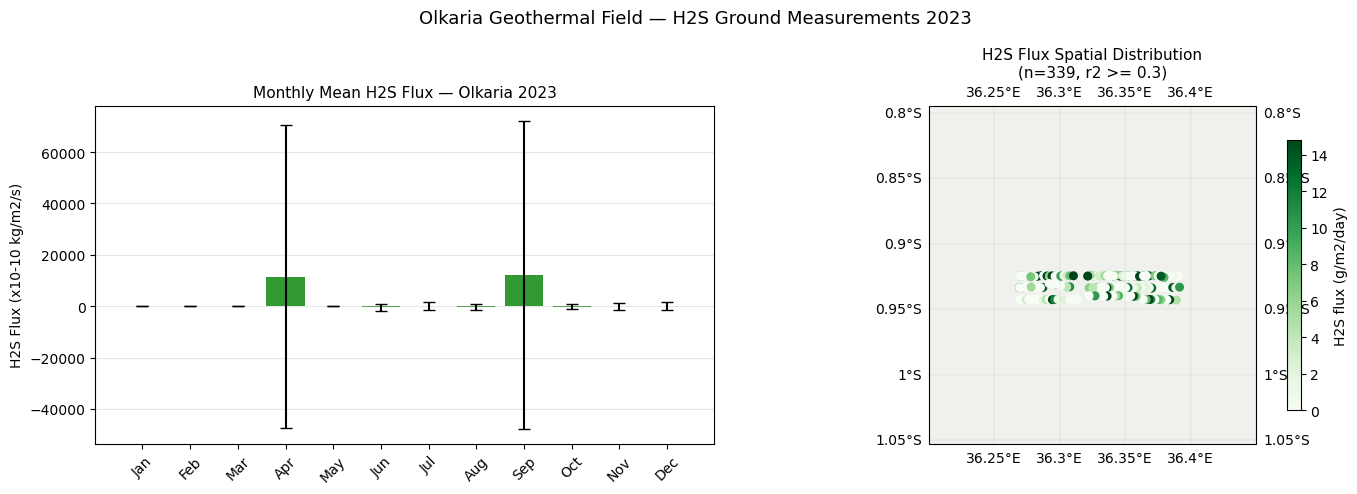

Plot saved to ./data/figures/h2s_flux_analysis.png

Emission inventory updated with H2S

  FINAL EMISSION INVENTORY — OLKARIA 2023
  CO2    flux=3.715e-07 kg/m2/s  annual= 293209.20 t/yr  daily=803.3129 t/day
  CH4    flux=5.425e-10 kg/m2/s  annual=    417.74 t/yr  daily=  1.1445 t/day
  H2S    flux=1.700e-07 kg/m2/s  annual= 134045.67 t/yr  daily=367.2484 t/day


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

# ── Load ground data ──────────────────────────────────────────────────────────
df = pd.read_excel(
    "./data/ground_measurements/final_ground_data.xlsx",
    sheet_name="ground data"
)

df["DATE"] = pd.to_datetime(df["DATE"]).dt.date

df = df.rename(columns={
    "1:H2S_FLUX [mol/mq/day]"  : "H2S_FLUX",
    "1:H2S_r^2"                : "H2S_R2",
    "1:H2S_SLOPE [ppm/s]"      : "H2S_SLOPE",
    "1:H2S_LCONC [ppm]"        : "H2S_LCONC",
    "1:H2S_RCONC [ppm]"        : "H2S_RCONC",
    "LATITUDE"                 : "LAT",
    "LONGITUDE"                : "LON",
    "0:CH4_FLUX [mol/mq/day]"  : "CH4_FLUX",
    "0:CH4_r^2"                : "CH4_R2",
    "2:CO2_FLUX [mol/mq/day]"  : "CO2_FLUX",
    "2:CO2_r^2"                : "CO2_R2",
})

# ── Check H2S r2 distribution ─────────────────────────────────────────────────
print("H2S r2 distribution:")
print(f"  r2 >= 0.7 : {(df['H2S_R2'] >= 0.7).sum():>4} measurements")
print(f"  r2 >= 0.5 : {(df['H2S_R2'] >= 0.5).sum():>4} measurements")
print(f"  r2 >= 0.3 : {(df['H2S_R2'] >= 0.3).sum():>4} measurements")
print(f"  r2 >= 0.0 : {(df['H2S_R2'] >= 0.0).sum():>4} measurements")
print(f"  Total rows: {len(df):>4}")

# ── Apply quality filter ──────────────────────────────────────────────────────
df_h2s = df[
    (df["H2S_R2"]   >= 0.3) &
    (df["H2S_FLUX"].notna())
].copy()

print(f"\nQuality filter (r2 >= 0.3): {len(df_h2s)} / {len(df)} kept")

# ── Unit conversions ──────────────────────────────────────────────────────────
MW_H2S = 34.08  # g/mol

df_h2s["H2S_FLUX_g"]     = df_h2s["H2S_FLUX"] * MW_H2S
df_h2s["H2S_FLUX_kgm2s"] = df_h2s["H2S_FLUX"] * MW_H2S / 1000 / 86400

# ── Statistics ────────────────────────────────────────────────────────────────
print(f"\nH2S Flux statistics (n={len(df_h2s)}, r2 >= 0.3):")
print(f"  {'Metric':<10} {'mol/m2/day':>12} {'g/m2/day':>12} {'kg/m2/s':>14}")
print(f"  {'-'*50}")
for stat, func in [('Min','min'),('Max','max'),
                   ('Mean','mean'),('Median','median'),('Std','std')]:
    v1 = getattr(df_h2s['H2S_FLUX'],       func)()
    v2 = getattr(df_h2s['H2S_FLUX_g'],     func)()
    v3 = getattr(df_h2s['H2S_FLUX_kgm2s'], func)()
    print(f"  {stat:<10} {v1:>12.6f} {v2:>12.6f} {v3:>14.2e}")

# ── Total emission estimate ───────────────────────────────────────────────────
AREA_M2        = 25.0 * 1e6
mean_h2s_kgm2s = df_h2s["H2S_FLUX_kgm2s"].mean()
annual_h2s_t   = mean_h2s_kgm2s * AREA_M2 * 86400 * 365 / 1000

print(f"\n{'='*50}")
print(f"  H2S EMISSION ESTIMATE")
print(f"{'='*50}")
print(f"  Mean flux     : {mean_h2s_kgm2s:.4e} kg/m2/s")
print(f"  Annual total  : {annual_h2s_t:.2f} t/yr")
print(f"  Daily mean    : {annual_h2s_t/365:.4f} t/day")
print(f"{'='*50}")

# ── Save H2S cleaned data ─────────────────────────────────────────────────────
df_h2s.to_csv(
    "./data/ground_measurements/h2s_ground_data_cleaned.csv",
    index=False
)
print("\nH2S data saved to h2s_ground_data_cleaned.csv")

# ── Monthly summary ───────────────────────────────────────────────────────────
df_h2s["MONTH"] = pd.to_datetime(df_h2s["DATE"]).dt.month
monthly_h2s = df_h2s.groupby("MONTH")["H2S_FLUX_kgm2s"].agg(
    ["mean","std","count"]
).reset_index()
monthly_h2s.columns = ["MONTH","mean_kgm2s","std_kgm2s","n"]
monthly_h2s["tday"] = (
    monthly_h2s["mean_kgm2s"] * AREA_M2 * 86400 / 1000
)
monthly_h2s.to_csv(
    "./data/ground_measurements/monthly_h2s_summary.csv",
    index=False
)
print("Monthly H2S summary saved")

# ── Plot monthly flux and spatial distribution ────────────────────────────────
months_names = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 5))

# Monthly bar chart
ax1 = fig.add_subplot(1, 2, 1)
ax1.bar(
    monthly_h2s["MONTH"],
    monthly_h2s["mean_kgm2s"] * 1e10,
    color="green", alpha=0.8,
    yerr=monthly_h2s["std_kgm2s"] * 1e10,
    capsize=4
)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months_names, rotation=45)
ax1.set_ylabel("H2S Flux (x10-10 kg/m2/s)")
ax1.set_title("Monthly Mean H2S Flux — Olkaria 2023", fontsize=11)
ax1.grid(axis="y", alpha=0.3)

# Spatial map
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([36.20, 36.45, -1.06, -0.80])
ax2.add_feature(cfeature.LAND, facecolor="#f0f0ec")
ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
sc = ax2.scatter(
    df_h2s["LON"], df_h2s["LAT"],
    c=df_h2s["H2S_FLUX_g"],
    cmap="Greens", s=30,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=df_h2s["H2S_FLUX_g"].quantile(0.95)
)
plt.colorbar(sc, ax=ax2, label="H2S flux (g/m2/day)", shrink=0.8)
ax2.set_title(
    f"H2S Flux Spatial Distribution\n(n={len(df_h2s)}, r2 >= 0.3)",
    fontsize=11
)

plt.suptitle(
    "Olkaria Geothermal Field — H2S Ground Measurements 2023",
    fontsize=13
)
plt.tight_layout()
plt.savefig(
    "./data/figures/h2s_flux_analysis.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved to ./data/figures/h2s_flux_analysis.png")

# ── Update emission inventory with H2S ───────────────────────────────────────
inv = pd.read_csv("./data/ground_measurements/emission_inventory.csv")

h2s_row = {
    "gas":              "H2S",
    "flux_kgm2s":       mean_h2s_kgm2s,
    "area_km2":         25.0,
    "annual_t_yr":      annual_h2s_t,
    "annual_t_yr_low":  annual_h2s_t * (8.82/25.0),
    "annual_t_yr_high": annual_h2s_t * (29.0/25.0),
    "daily_t_day":      annual_h2s_t / 365,
    "lat_center":       -0.933210,
    "lon_center":        36.331589,
}

inv = pd.concat(
    [inv, pd.DataFrame([h2s_row])],
    ignore_index=True
)
inv.to_csv(
    "./data/ground_measurements/emission_inventory.csv",
    index=False
)
print("\nEmission inventory updated with H2S")

# ── Print final inventory ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  FINAL EMISSION INVENTORY — OLKARIA 2023")
print(f"{'='*60}")
for _, row in inv.iterrows():
    print(
        f"  {row['gas']:<6} "
        f"flux={row['flux_kgm2s']:.3e} kg/m2/s  "
        f"annual={row['annual_t_yr']:>10.2f} t/yr  "
        f"daily={row['daily_t_day']:>8.4f} t/day"
    )
print(f"{'='*60}")

H2S flux distribution analysis:
  Total measurements : 339
  Negative values    : 113
  Zero values        : 1

Percentile distribution (mol/m2/day):
     1th percentile : -0.709346
     5th percentile : -0.491155
    10th percentile : -0.365526
    25th percentile : -0.097154
    50th percentile : 0.002190
    75th percentile : 0.043556
    90th percentile : 0.304749
    95th percentile : 0.435422
    99th percentile : 0.756917
   100th percentile : 76.000000

Top 10 highest H2S flux values:
      DATE  POINT  H2S_FLUX     H2S_R2
2023-04-13    103 76.000000 106.000000
2023-09-12    255 75.917449   1.000000
2023-12-09    343  1.173375   0.478968
2023-09-01    244  0.770631   0.403113
2023-11-11    315  0.734540   0.556336
2023-12-08    342  0.707174   0.697080
2023-07-01    182  0.701147   1.000000
2023-07-08    189  0.676815   0.963747
2023-09-21    264  0.619421   0.473516
2023-12-16    350  0.614267   0.917523

Bottom 10 (most negative) H2S flux values:
      DATE  POINT  H2S_FLUX  

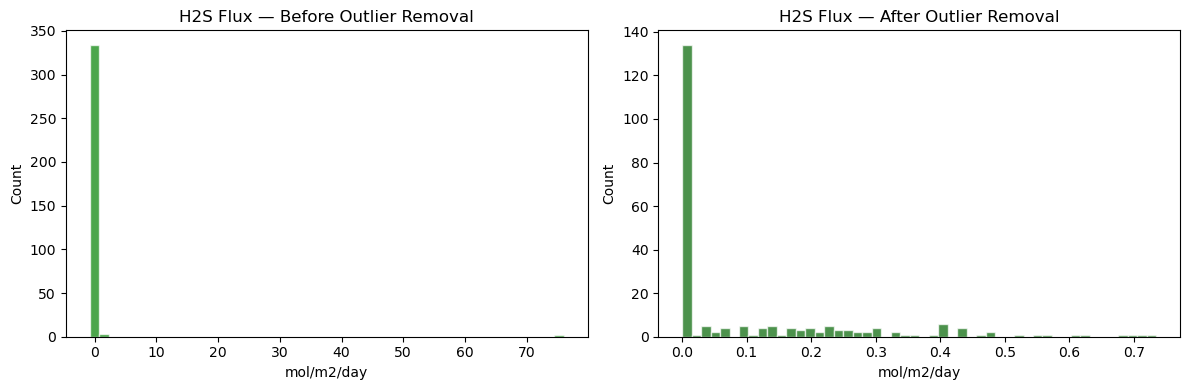

Plot saved


In [8]:
#this is to clean the so2 outliers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_h2s = pd.read_csv(
    "./data/ground_measurements/h2s_ground_data_cleaned.csv"
)

# ── Investigate the outliers ──────────────────────────────────────────────────
print("H2S flux distribution analysis:")
print(f"  Total measurements : {len(df_h2s)}")
print(f"  Negative values    : {(df_h2s['H2S_FLUX'] < 0).sum()}")
print(f"  Zero values        : {(df_h2s['H2S_FLUX'] == 0).sum()}")
print(f"\nPercentile distribution (mol/m2/day):")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99, 100]:
    val = np.percentile(df_h2s['H2S_FLUX'].dropna(), p)
    print(f"  {p:>4}th percentile : {val:.6f}")

# ── Show extreme values ───────────────────────────────────────────────────────
print(f"\nTop 10 highest H2S flux values:")
top10 = df_h2s.nlargest(10, 'H2S_FLUX')[
    ['DATE','POINT','H2S_FLUX','H2S_R2']
]
print(top10.to_string(index=False))

print(f"\nBottom 10 (most negative) H2S flux values:")
bot10 = df_h2s.nsmallest(10, 'H2S_FLUX')[
    ['DATE','POINT','H2S_FLUX','H2S_R2']
]
print(bot10.to_string(index=False))

# ── Apply IQR-based outlier removal ──────────────────────────────────────────
# Use only positive fluxes (negative = instrument noise)
df_pos = df_h2s[df_h2s['H2S_FLUX'] > 0].copy()

Q1  = df_pos['H2S_FLUX'].quantile(0.25)
Q3  = df_pos['H2S_FLUX'].quantile(0.75)
IQR = Q3 - Q1

lower = 0            # flux cannot be negative physically
upper = Q3 + 3 * IQR # 3×IQR upper fence (less aggressive than 1.5×)

print(f"\nIQR outlier analysis:")
print(f"  Q1  : {Q1:.6f} mol/m2/day")
print(f"  Q3  : {Q3:.6f} mol/m2/day")
print(f"  IQR : {IQR:.6f}")
print(f"  Upper fence (Q3 + 3xIQR): {upper:.6f} mol/m2/day")

df_clean = df_pos[df_pos['H2S_FLUX'] <= upper].copy()

print(f"\nAfter outlier removal:")
print(f"  Kept    : {len(df_clean)} / {len(df_h2s)}")
print(f"  Removed : {len(df_h2s) - len(df_clean)}")
print(f"\n  New mean  : {df_clean['H2S_FLUX'].mean():.6f} mol/m2/day")
print(f"  New median: {df_clean['H2S_FLUX'].median():.6f} mol/m2/day")
print(f"  New max   : {df_clean['H2S_FLUX'].max():.6f} mol/m2/day")

# ── Recalculate emissions ─────────────────────────────────────────────────────
MW_H2S  = 34.08
AREA_M2 = 25.0 * 1e6

df_clean["H2S_FLUX_g"]     = df_clean["H2S_FLUX"] * MW_H2S
df_clean["H2S_FLUX_kgm2s"] = df_clean["H2S_FLUX"] * MW_H2S / 1000 / 86400

mean_flux   = df_clean["H2S_FLUX_kgm2s"].mean()
annual_t    = mean_flux * AREA_M2 * 86400 * 365 / 1000

print(f"\n{'='*50}")
print(f"  H2S EMISSION ESTIMATE (cleaned)")
print(f"{'='*50}")
print(f"  Mean flux    : {mean_flux:.4e} kg/m2/s")
print(f"  Annual total : {annual_t:.4f} t/yr")
print(f"  Daily mean   : {annual_t/365:.6f} t/day")
print(f"{'='*50}")

# ── Plot before and after ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df_h2s['H2S_FLUX'].dropna(), bins=50,
    color='green', alpha=0.7, edgecolor='white'
)
axes[0].set_title('H2S Flux — Before Outlier Removal')
axes[0].set_xlabel('mol/m2/day')
axes[0].set_ylabel('Count')

axes[1].hist(
    df_clean['H2S_FLUX'], bins=50,
    color='darkgreen', alpha=0.7, edgecolor='white'
)
axes[1].set_title('H2S Flux — After Outlier Removal')
axes[1].set_xlabel('mol/m2/day')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(
    "./data/figures/h2s_outlier_analysis.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved")

Issues identified in H2S data:
  1. Impossible r2 > 1.0   : 2 measurements
  2. Negative flux values  : 113 measurements
  3. Extreme outliers (>1) : 3 measurements

Step 1 — Remove impossible r2 > 1.0:
  Removed : 2
  Kept    : 337

Step 2 — Remove negative flux values:
  Kept    : 224

Step 3 — Remove values above 99th percentile (0.7623 mol/m2/day):
  Kept    : 221

Final H2S statistics (n=221):
  Metric       mol/m2/day     g/m2/day        kg/m2/s
  --------------------------------------------------
  Min            0.000053     0.001800       2.08e-11
  Max            0.734540    25.033133       2.90e-07
  Mean           0.105773     3.604757       4.17e-08
  Median         0.006481     0.220872       2.56e-09
  Std            0.168139     5.730170       6.63e-08

  H2S EMISSION ESTIMATE (final)
  Mean flux    : 4.1722e-08 kg/m2/s
  Annual total : 32893.4070 t/yr
  Daily mean   : 90.118923 t/day

Final H2S data saved: 221 measurements


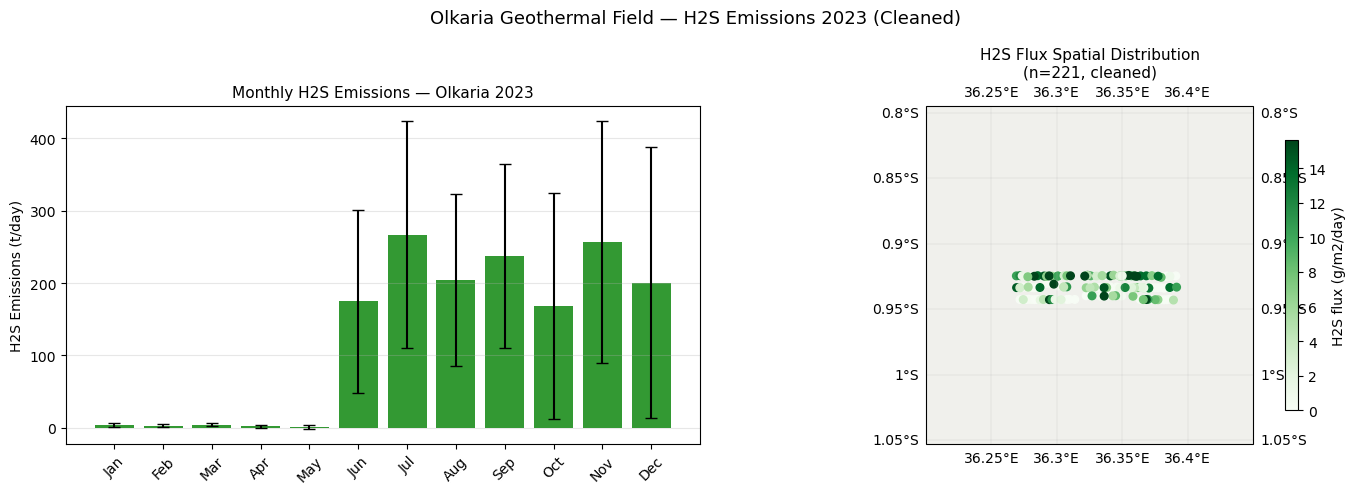

Plot saved to ./data/figures/h2s_flux_final.png

  COMPLETE EMISSION INVENTORY — OLKARIA 2023
  Gas     Flux (kg/m2/s)   Annual (t/yr)  Daily (t/day)
  ----------------------------------------------------
  CO2         3.7146e-07       293209.20       803.3129
  CH4         5.4246e-10          417.74         1.1445
  H2S         4.1722e-08        32893.41        90.1189


In [9]:
#further data cleaning to eliminate outliers


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

df_h2s = pd.read_csv(
    "./data/ground_measurements/h2s_ground_data_cleaned.csv"
)

print("Issues identified in H2S data:")
print(f"  1. Impossible r2 > 1.0   : {(df_h2s['H2S_R2'] > 1.0).sum()} measurements")
print(f"  2. Negative flux values  : {(df_h2s['H2S_FLUX'] < 0).sum()} measurements")
print(f"  3. Extreme outliers (>1) : {(df_h2s['H2S_FLUX'] > 1.0).sum()} measurements")

# ── Clean step by step ────────────────────────────────────────────────────────

# Step 1: Remove impossible r2 values (r2 must be 0-1)
df_clean = df_h2s[df_h2s["H2S_R2"] <= 1.0].copy()
print(f"\nStep 1 — Remove impossible r2 > 1.0:")
print(f"  Removed : {len(df_h2s) - len(df_clean)}")
print(f"  Kept    : {len(df_clean)}")

# Step 2: Remove negative fluxes (physically impossible)
df_clean = df_clean[df_clean["H2S_FLUX"] >= 0].copy()
print(f"\nStep 2 — Remove negative flux values:")
print(f"  Kept    : {len(df_clean)}")

# Step 3: Remove statistical outliers using 99th percentile cap
p99 = df_clean["H2S_FLUX"].quantile(0.99)
df_clean = df_clean[df_clean["H2S_FLUX"] <= p99].copy()
print(f"\nStep 3 — Remove values above 99th percentile ({p99:.4f} mol/m2/day):")
print(f"  Kept    : {len(df_clean)}")

# ── Recalculate units ─────────────────────────────────────────────────────────
MW_H2S  = 34.08
AREA_M2 = 25.0 * 1e6

df_clean["H2S_FLUX_g"]     = df_clean["H2S_FLUX"] * MW_H2S
df_clean["H2S_FLUX_kgm2s"] = (
    df_clean["H2S_FLUX"] * MW_H2S / 1000 / 86400
)

# ── Statistics ────────────────────────────────────────────────────────────────
mean_flux = df_clean["H2S_FLUX_kgm2s"].mean()
annual_t  = mean_flux * AREA_M2 * 86400 * 365 / 1000

print(f"\nFinal H2S statistics (n={len(df_clean)}):")
print(f"  {'Metric':<10} {'mol/m2/day':>12} {'g/m2/day':>12} {'kg/m2/s':>14}")
print(f"  {'-'*50}")
for stat, func in [('Min','min'),('Max','max'),
                   ('Mean','mean'),('Median','median'),('Std','std')]:
    v1 = getattr(df_clean['H2S_FLUX'],       func)()
    v2 = getattr(df_clean['H2S_FLUX_g'],     func)()
    v3 = getattr(df_clean['H2S_FLUX_kgm2s'], func)()
    print(f"  {stat:<10} {v1:>12.6f} {v2:>12.6f} {v3:>14.2e}")

print(f"\n{'='*50}")
print(f"  H2S EMISSION ESTIMATE (final)")
print(f"{'='*50}")
print(f"  Mean flux    : {mean_flux:.4e} kg/m2/s")
print(f"  Annual total : {annual_t:.4f} t/yr")
print(f"  Daily mean   : {annual_t/365:.6f} t/day")
print(f"{'='*50}")

# ── Save final cleaned H2S data ───────────────────────────────────────────────
df_clean.to_csv(
    "./data/ground_measurements/h2s_ground_data_cleaned.csv",
    index=False
)
print(f"\nFinal H2S data saved: {len(df_clean)} measurements")

# ── Monthly summary ───────────────────────────────────────────────────────────
df_clean["MONTH"] = pd.to_datetime(df_clean["DATE"]).dt.month
monthly_h2s = df_clean.groupby("MONTH")["H2S_FLUX_kgm2s"].agg(
    ["mean","std","count"]
).reset_index()
monthly_h2s.columns = ["MONTH","mean_kgm2s","std_kgm2s","n"]
monthly_h2s["tday"] = (
    monthly_h2s["mean_kgm2s"] * AREA_M2 * 86400 / 1000
)
monthly_h2s.to_csv(
    "./data/ground_measurements/monthly_h2s_summary.csv",
    index=False
)

# ── Plot spatial distribution ─────────────────────────────────────────────────
months_names = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig = plt.figure(figsize=(14, 5))

# Monthly bar chart
ax1 = fig.add_subplot(1, 2, 1)
ax1.bar(
    monthly_h2s["MONTH"],
    monthly_h2s["tday"],
    color="green", alpha=0.8,
    yerr=monthly_h2s["std_kgm2s"] * AREA_M2 * 86400 / 1000,
    capsize=4
)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months_names, rotation=45)
ax1.set_ylabel("H2S Emissions (t/day)")
ax1.set_title("Monthly H2S Emissions — Olkaria 2023", fontsize=11)
ax1.grid(axis="y", alpha=0.3)

# Spatial map
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([36.20, 36.45, -1.06, -0.80])
ax2.add_feature(cfeature.LAND, facecolor="#f0f0ec")
ax2.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
sc = ax2.scatter(
    df_clean["LON"], df_clean["LAT"],
    c=df_clean["H2S_FLUX_g"],
    cmap="Greens", s=30,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=df_clean["H2S_FLUX_g"].quantile(0.95)
)
plt.colorbar(sc, ax=ax2, label="H2S flux (g/m2/day)", shrink=0.8)
ax2.set_title(
    f"H2S Flux Spatial Distribution\n(n={len(df_clean)}, cleaned)",
    fontsize=11
)

plt.suptitle(
    "Olkaria Geothermal Field — H2S Emissions 2023 (Cleaned)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(
    "./data/figures/h2s_flux_final.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved to ./data/figures/h2s_flux_final.png")

# ── Update emission inventory ─────────────────────────────────────────────────
inv = pd.read_csv("./data/ground_measurements/emission_inventory.csv")

# Remove old H2S row if exists
inv = inv[inv["gas"] != "H2S"].copy()

h2s_row = {
    "gas":              "H2S",
    "flux_kgm2s":       mean_flux,
    "area_km2":         25.0,
    "annual_t_yr":      annual_t,
    "annual_t_yr_low":  annual_t * (8.82/25.0),
    "annual_t_yr_high": annual_t * (29.0/25.0),
    "daily_t_day":      annual_t / 365,
    "lat_center":       -0.933210,
    "lon_center":        36.331589,
}

inv = pd.concat(
    [inv, pd.DataFrame([h2s_row])],
    ignore_index=True
)
inv.to_csv(
    "./data/ground_measurements/emission_inventory.csv",
    index=False
)

# ── Final complete inventory ──────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  COMPLETE EMISSION INVENTORY — OLKARIA 2023")
print(f"{'='*65}")
print(f"  {'Gas':<6} {'Flux (kg/m2/s)':>15} {'Annual (t/yr)':>15} {'Daily (t/day)':>14}")
print(f"  {'-'*52}")
for _, row in inv.iterrows():
    print(
        f"  {row['gas']:<6} "
        f"{row['flux_kgm2s']:>15.4e} "
        f"{row['annual_t_yr']:>15.2f} "
        f"{row['daily_t_day']:>14.4f}"
    )
print(f"{'='*65}")

In [10]:
import netCDF4 as nc4
import pandas as pd
import numpy as np
import datetime
import glob
import os

CENTER_LAT = -0.933210
CENTER_LON =  36.331589
os.makedirs("./data/HEMCO", exist_ok=True)

# ── Load monthly summaries ────────────────────────────────────────────────────
monthly_co2 = pd.read_csv("./data/ground_measurements/monthly_co2_summary.csv")
monthly_ch4 = pd.read_csv("./data/ground_measurements/monthly_ch4_summary.csv")
monthly_h2s = pd.read_csv("./data/ground_measurements/monthly_h2s_summary.csv")
inv         = pd.read_csv("./data/ground_measurements/emission_inventory.csv")

co2_row = inv[inv["gas"] == "CO2"].iloc[0]
ch4_row = inv[inv["gas"] == "CH4"].iloc[0]
h2s_row = inv[inv["gas"] == "H2S"].iloc[0]

# ── Helper: create one NetCDF file ────────────────────────────────────────────
def create_hemco_nc(fname, varname, monthly_df, flux_col, title, comment):
    ds = nc4.Dataset(fname, "w", format="NETCDF4")
    ds.createDimension("lon",   1)
    ds.createDimension("lat",   1)
    ds.createDimension("time", 12)

    lon_v        = ds.createVariable("lon",  "f4", ("lon",))
    lat_v        = ds.createVariable("lat",  "f4", ("lat",))
    time_v       = ds.createVariable("time", "i4", ("time",))
    lon_v[:]     = [CENTER_LON]
    lat_v[:]     = [CENTER_LAT]
    time_v[:]    = list(range(1, 13))
    lon_v.units  = "degrees_east"
    lat_v.units  = "degrees_north"
    time_v.units = "months since 2023-01-01"

    flux_v            = ds.createVariable(
        varname, "f4", ("time","lat","lon"), fill_value=-1e30
    )
    flux_v.units      = "kg/m2/s"
    flux_v.long_name  = title

    # Fill 12 months
    for i in range(12):
        if i < len(monthly_df):
            flux_v[i, 0, 0] = float(monthly_df.iloc[i][flux_col])
        else:
            flux_v[i, 0, 0] = float(monthly_df[flux_col].mean())

    ds.title       = title
    ds.institution = "Dissertation Study — Olkaria, Kenya"
    ds.source      = "Ground flux measurements (this study, 2023)"
    ds.history     = f"Created {datetime.datetime.now().isoformat()}"
    ds.comment     = comment
    ds.close()
    print(f"  Created: {os.path.basename(fname)}")

# ── Create all three NetCDF files ─────────────────────────────────────────────
print("Creating HEMCO NetCDF emission files...")

# Determine flux column name
co2_flux_col = "mean_flux_kgm2s" if "mean_flux_kgm2s" in monthly_co2.columns \
               else "mean_kgm2s"
ch4_flux_col = "mean_flux_kgm2s" if "mean_flux_kgm2s" in monthly_ch4.columns \
               else "mean_kgm2s"
h2s_flux_col = "mean_kgm2s"

create_hemco_nc(
    "./data/HEMCO/olkaria_co2_flux.nc",
    "CO2_flux",
    monthly_co2,
    co2_flux_col,
    "Olkaria geothermal CO2 flux",
    f"CO2 point source at lat={CENTER_LAT}, lon={CENTER_LON}. Area: 25 km2."
)

create_hemco_nc(
    "./data/HEMCO/olkaria_ch4_flux.nc",
    "CH4_flux",
    monthly_ch4,
    ch4_flux_col,
    "Olkaria geothermal CH4 flux",
    f"CH4 point source at lat={CENTER_LAT}, lon={CENTER_LON}. Area: 25 km2."
)

create_hemco_nc(
    "./data/HEMCO/olkaria_h2s_flux.nc",
    "H2S_flux",
    monthly_h2s,
    h2s_flux_col,
    "Olkaria geothermal H2S flux",
    f"H2S point source at lat={CENTER_LAT}, lon={CENTER_LON}. "
    f"Area: 25 km2. H2S oxidises to SO2 (half-life ~1-2 days)."
)

# ── Write HEMCO_Config.rc ─────────────────────────────────────────────────────
hemco_config = f"""#==============================================================================
# HEMCO Configuration for Olkaria Geothermal Field Emissions
# Study period : 2023-01-01 to 2023-12-31
# Location     : Olkaria, Kenya Rift Valley
#                lat={CENTER_LAT}, lon={CENTER_LON}
# Gases        : CO2, CH4, H2S
# Source       : Ground flux measurements (this study)
#==============================================================================

###############################################################################
### BEGIN SECTION SETTINGS
###############################################################################
ROOT                    : ./data/HEMCO
Logfile                 : HEMCO.log
DiagnPrefix             : HEMCO_diagnostics
DiagnFreq               : Monthly
Wildcard                : *
Separator               : /
Unit tolerance          : 1
Negative values         : 0
Only unitless scale fac : false
Verbose                 : 0
Warnings                : 1

###############################################################################
### BEGIN SECTION BASE EMISSIONS
###############################################################################

# --- CO2 ---
# Flux : {co2_row['flux_kgm2s']:.4e} kg/m2/s
# Rate : {co2_row['daily_t_day']:.1f} t/day
0 OLKARIA_CO2  ./data/HEMCO/olkaria_co2_flux.nc  CO2_flux  2023/1-12/1/0 C xy kg/m2/s CO2

# --- CH4 ---
# Flux : {ch4_row['flux_kgm2s']:.4e} kg/m2/s
# Rate : {ch4_row['daily_t_day']:.4f} t/day
0 OLKARIA_CH4  ./data/HEMCO/olkaria_ch4_flux.nc  CH4_flux  2023/1-12/1/0 C xy kg/m2/s CH4

# --- H2S ---
# Flux : {h2s_row['flux_kgm2s']:.4e} kg/m2/s
# Rate : {h2s_row['daily_t_day']:.4f} t/day
# Note : H2S oxidises to SO2 in atmosphere
0 OLKARIA_H2S  ./data/HEMCO/olkaria_h2s_flux.nc  H2S_flux  2023/1-12/1/0 C xy kg/m2/s H2S

###############################################################################
### END SECTION BASE EMISSIONS
###############################################################################
"""

with open("./data/HEMCO/HEMCO_Config.rc", "w") as f:
    f.write(hemco_config)
print("  HEMCO_Config.rc written ✓")

# ── Verify all files ──────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  HEMCO FILES — FINAL CHECK")
print(f"{'='*55}")
for fname in [
    "./data/HEMCO/HEMCO_Config.rc",
    "./data/HEMCO/olkaria_co2_flux.nc",
    "./data/HEMCO/olkaria_ch4_flux.nc",
    "./data/HEMCO/olkaria_h2s_flux.nc",
]:
    exists  = os.path.exists(fname)
    size_kb = os.path.getsize(fname) / 1e3 if exists else 0
    status  = "OK" if exists else "MISSING"
    print(f"  [{status}] {os.path.basename(fname):<30} {size_kb:.1f} KB")

# ── Complete data inventory ───────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  COMPLETE PROJECT DATA INVENTORY")
print(f"{'='*65}")
datasets = [
    ("OCO-2 XCO2",       "./data/OCO2/L2_Lite/*.nc4",         False),
    ("TROPOMI XCH4",     "./data/TROPOMI/extracted/*.npz",     False),
    ("TROPOMI SO2",      "./data/TROPOMI_SO2/extracted/*.npz", False),
    ("GEOS-FP met",      "./data/GEOS_FP/**/*.nc",             True),
]
total_gb = 0
for label, pattern, recursive in datasets:
    files   = glob.glob(pattern, recursive=recursive)
    size_gb = sum(os.path.getsize(f) for f in files) / 1e9
    total_gb += size_gb
    print(f"  {label:<20} {len(files):>5} files   {size_gb:>7.2f} GB")
print(f"  {'-'*45}")
print(f"  {'TOTAL':<20} {'':>5}        {total_gb:>7.2f} GB")
print(f"{'='*65}")

print(f"\n{'='*65}")
print(f"  EMISSION INVENTORY SUMMARY")
print(f"{'='*65}")
print(f"  {'Gas':<6} {'Flux (kg/m2/s)':>15} {'t/yr':>12} {'t/day':>10}")
print(f"  {'-'*45}")
for _, row in inv.iterrows():
    print(
        f"  {row['gas']:<6} "
        f"{row['flux_kgm2s']:>15.4e} "
        f"{row['annual_t_yr']:>12.1f} "
        f"{row['daily_t_day']:>10.4f}"
    )
print(f"{'='*65}")
print(f"\nAll data ready for GEOS-Chem simulation!")
print(f"Next step: Cloud computing setup (Jetstream2 or Oracle)")

Creating HEMCO NetCDF emission files...
  Created: olkaria_co2_flux.nc
  Created: olkaria_ch4_flux.nc
  Created: olkaria_h2s_flux.nc
  HEMCO_Config.rc written ✓

  HEMCO FILES — FINAL CHECK
  [OK] HEMCO_Config.rc                1.9 KB
  [OK] olkaria_co2_flux.nc            9.6 KB
  [OK] olkaria_ch4_flux.nc            9.6 KB
  [OK] olkaria_h2s_flux.nc            9.6 KB

  COMPLETE PROJECT DATA INVENTORY
  OCO-2 XCO2             346 files     21.11 GB
  TROPOMI XCH4           310 files      0.00 GB
  TROPOMI SO2            365 files      0.15 GB
  GEOS-FP met           1095 files    218.63 GB
  ---------------------------------------------
  TOTAL                              239.89 GB

  EMISSION INVENTORY SUMMARY
  Gas     Flux (kg/m2/s)         t/yr      t/day
  ---------------------------------------------
  CO2         3.7146e-07     293209.2   803.3129
  CH4         5.4246e-10        417.7     1.1445
  H2S         4.1722e-08      32893.4    90.1189

All data ready for GEOS-Chem simu

In [2]:
#Here, (after doing configurations in UBUNTU), we upload the HEMCO files to google cloud
import subprocess
import sys
import os

# Install google cloud storage
subprocess.run([sys.executable, "-m", "pip", "install", 
                "google-cloud-storage"], capture_output=True)

# Files to upload
hemco_files = [
    "./data/HEMCO/HEMCO_Config.rc",
    "./data/HEMCO/olkaria_co2_flux.nc",
    "./data/HEMCO/olkaria_ch4_flux.nc",
    "./data/HEMCO/olkaria_h2s_flux.nc",
]

# Check files exist
print("Checking HEMCO files on laptop:")
for f in hemco_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1e3 if exists else 0
    print(f"  {'OK' if exists else 'MISSING'} {f} ({size:.1f} KB)")

Checking HEMCO files on laptop:
  OK ./data/HEMCO/HEMCO_Config.rc (1.9 KB)
  OK ./data/HEMCO/olkaria_co2_flux.nc (9.6 KB)
  OK ./data/HEMCO/olkaria_ch4_flux.nc (9.6 KB)
  OK ./data/HEMCO/olkaria_h2s_flux.nc (9.6 KB)
